## Importación de librerías

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                              roc_auc_score, precision_recall_curve)
from scipy import stats
sns.set_style("whitegrid"); plt.rcParams["figure.figsize"] = (10,5)

df = pd.read_csv("data.csv")

1. ANÁLISIS EXPLORATORIO

## 1.1 Separar variables por tipo

Se agrupan las columnas del dataset según su naturaleza estadística, lo que determina qué tipo de análisis es pertinente para cada una.

- **Numéricas continuas:** variables que toman valores en un rango continuo (edad, peso, horas de sueño, etc.). Se analizan con estadísticos de posición y dispersión, histogramas y correlaciones.
- **Categóricas:** variables que representan grupos discretos (posición del jugador, adherencia al calentamiento). Se estudian mediante conteos, proporciones y tablas de contingencia.
- **Variable respuesta (target):** *Injury_Next_Season*, indicador binario de lesión durante la siguiente temporada.

Esta separación no es arbitraria: cada familia de variables requiere herramientas analíticas distintas, y mezclarlas —calcular la media de "Position", por ejemplo— produciría resultados sin sentido estadístico.

In [2]:
target = "Injury_Next_Season"

num_vars = ["Age","Height_cm","Weight_kg","BMI","Training_Hours_Per_Week",
            "Matches_Played_Past_Season","Previous_Injury_Count",
            "Knee_Strength_Score","Hamstring_Flexibility","Reaction_Time_ms",
            "Balance_Test_Score","Sprint_Speed_10m_s","Agility_Score",
            "Sleep_Hours_Per_Night","Stress_Level_Score","Nutrition_Quality_Score"]

cat_vars = ["Position","Warmup_Routine_Adherence"]

print(f"Variables numéricas: {len(num_vars)}")
print(f"Variables categóricas: {len(cat_vars)}")
print(f"Variable objetivo: {target}")


Variables numéricas: 16
Variables categóricas: 2
Variable objetivo: Injury_Next_Season


## 1.2 Balance del target

En un problema de clasificación binaria, el *balance* describe la distribución entre las dos clases (0 = no lesionado, 1 = lesionado). Esto importa porque un dataset muy desbalanceado puede llevar al modelo a aprender a predecir siempre la clase mayoritaria y obtener buena *accuracy* sin haber aprendido nada útil.

Los tres escenarios más comunes son:

- **Balanceado (~50/50):** situación ideal; el modelo aprende ambas clases por igual.
- **Ligeramente desbalanceado (70/30):** manejable con métricas apropiadas como F1 o AUC.
- **Muy desbalanceado (95/5):** la *accuracy* miente; se requieren técnicas de remuestreo o pesos por clase.

El balance define también qué métricas de evaluación son prioritarias. Si hay desbalance notable, la *accuracy* sola es insuficiente.

                    proporción  conteo
Injury_Next_Season                    
0                          0.5     400
1                          0.5     400


C:\Users\abrah\AppData\Local\Temp\ipykernel_9064\2751494011.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df, palette="Set2")


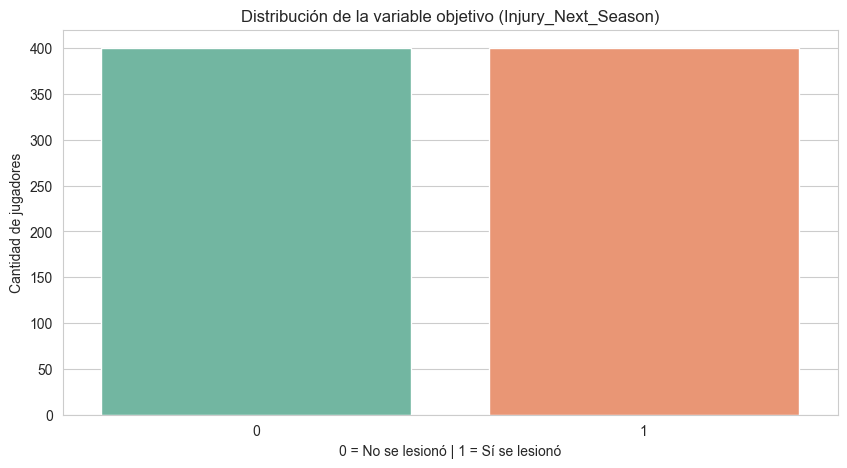

In [3]:
balance = df[target].value_counts(normalize=True).rename("proporción").to_frame()
balance["conteo"] = df[target].value_counts()
print(balance)

sns.countplot(x=target, data=df, palette="Set2")
plt.title("Distribución de la variable objetivo (Injury_Next_Season)")
plt.xlabel("0 = No se lesionó | 1 = Sí se lesionó")
plt.ylabel("Cantidad de jugadores")
plt.show()


## 1.3 Histogramas de variables numéricas

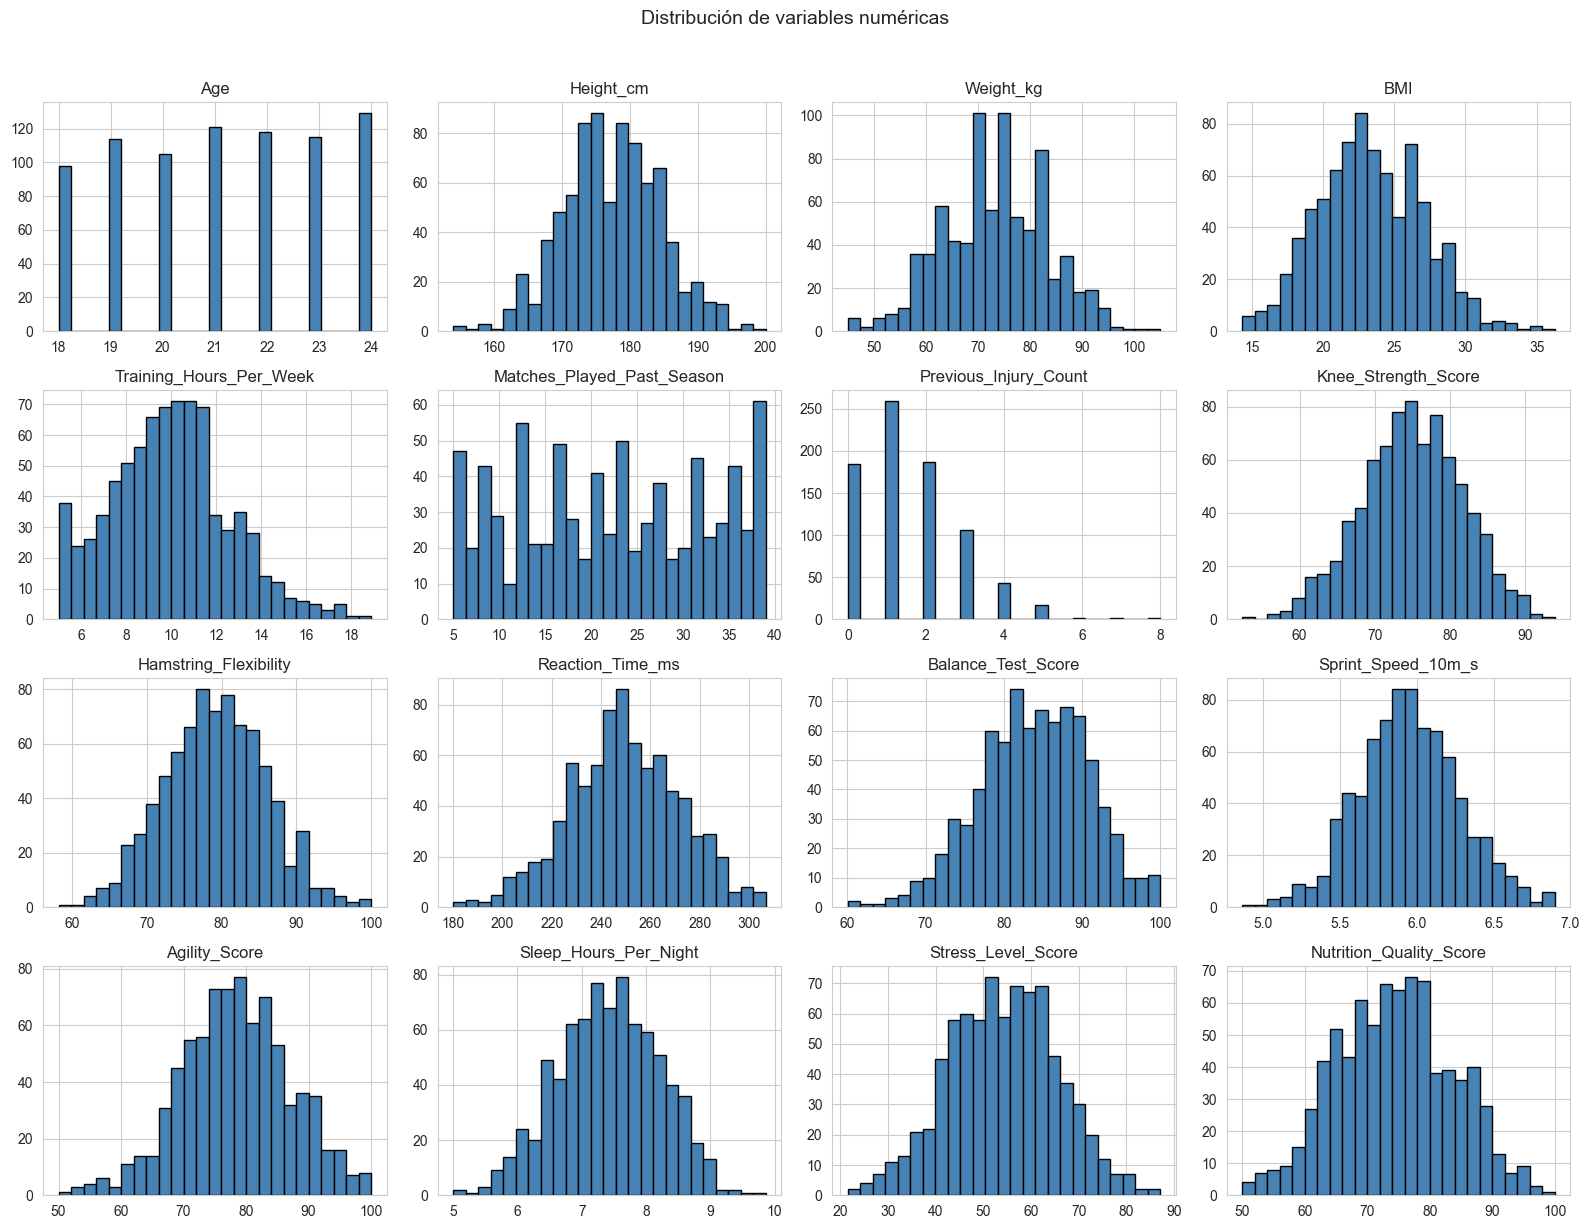

In [4]:
df[num_vars].hist(bins=25, figsize=(16,12), color="steelblue", edgecolor="black")
plt.suptitle("Distribución de variables numéricas", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 1.4 Boxplots

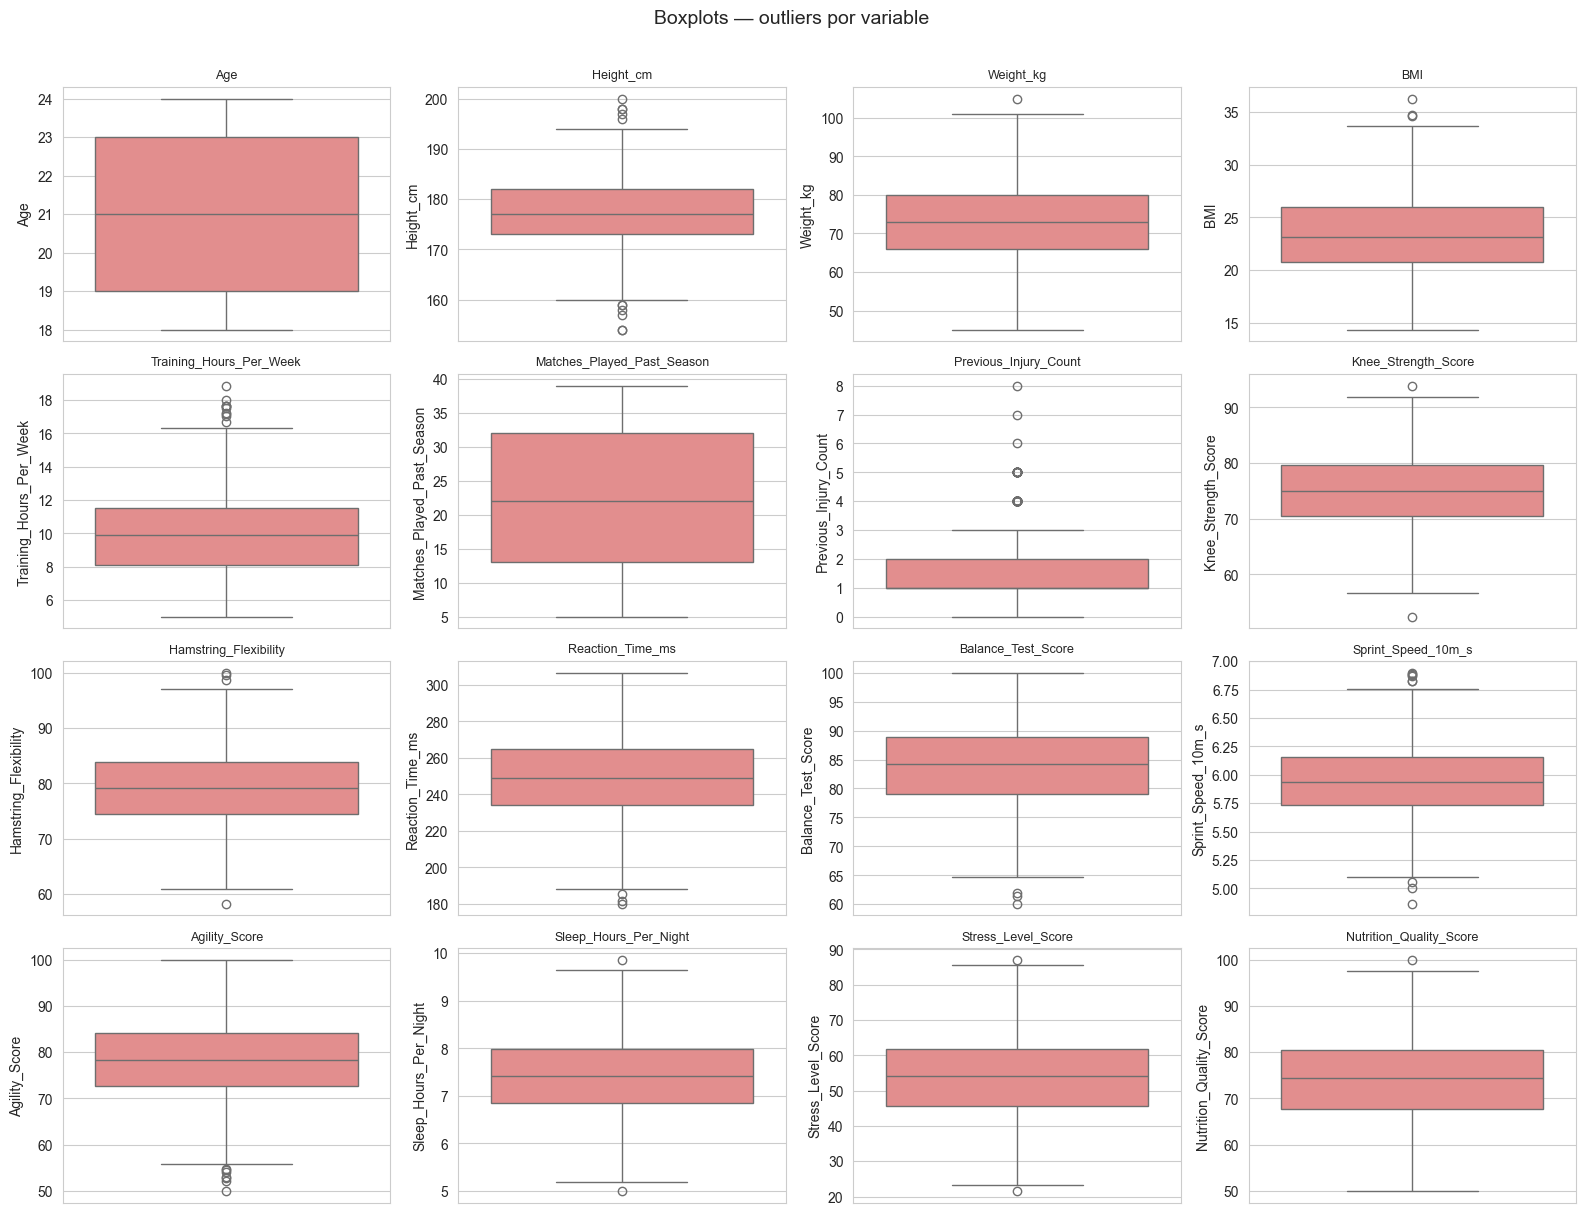

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(16,12))
for ax, col in zip(axes.flatten(), num_vars):
    sns.boxplot(y=df[col], ax=ax, color="lightcoral")
    ax.set_title(col, fontsize=9)
plt.suptitle("Boxplots — outliers por variable", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 1.5 Distribución de variables categóricas

C:\Users\abrah\AppData\Local\Temp\ipykernel_9064\4021078693.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Position", data=df, ax=axes[0], palette="Set3")
C:\Users\abrah\AppData\Local\Temp\ipykernel_9064\4021078693.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Warmup_Routine_Adherence", data=df, ax=axes[1], palette="Set3")


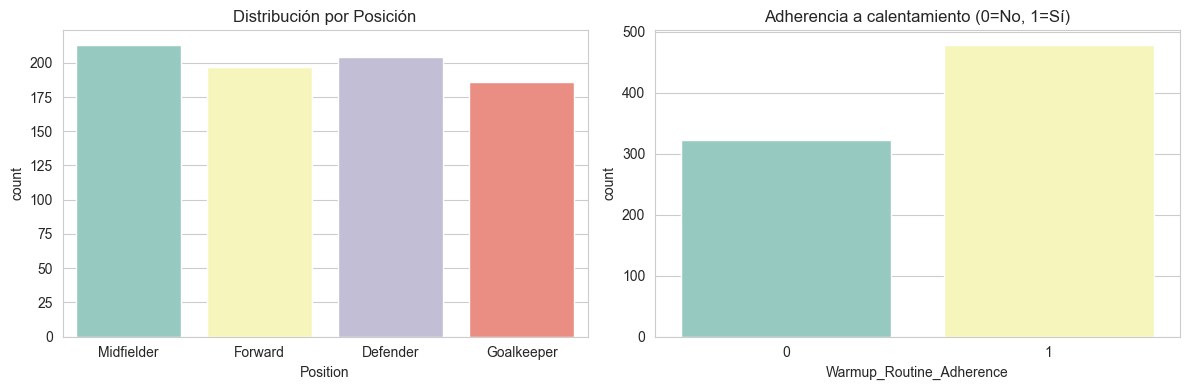


Proporciones por Posición:
Position
Midfielder    0.266
Defender      0.255
Forward       0.246
Goalkeeper    0.232
Name: proportion, dtype: float64

Proporciones de Warmup:
Warmup_Routine_Adherence
1    0.598
0    0.402
Name: proportion, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(x="Position", data=df, ax=axes[0], palette="Set3")
axes[0].set_title("Distribución por Posición")
sns.countplot(x="Warmup_Routine_Adherence", data=df, ax=axes[1], palette="Set3")
axes[1].set_title("Adherencia a calentamiento (0=No, 1=Sí)")
plt.tight_layout()
plt.show()

print("\nProporciones por Posición:")
print(df["Position"].value_counts(normalize=True).round(3))
print("\nProporciones de Warmup:")
print(df["Warmup_Routine_Adherence"].value_counts(normalize=True).round(3))


## 1.6 Variables numéricas estratificadas por lesión

C:\Users\abrah\AppData\Local\Temp\ipykernel_9064\807652400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, ax=ax, palette="Set2")
C:\Users\abrah\AppData\Local\Temp\ipykernel_9064\807652400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, ax=ax, palette="Set2")
C:\Users\abrah\AppData\Local\Temp\ipykernel_9064\807652400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, ax=ax, palette="Set2")
C:\Users\abrah\AppData\Local\Temp\ipykernel_9064\807652400.py:3: Fu

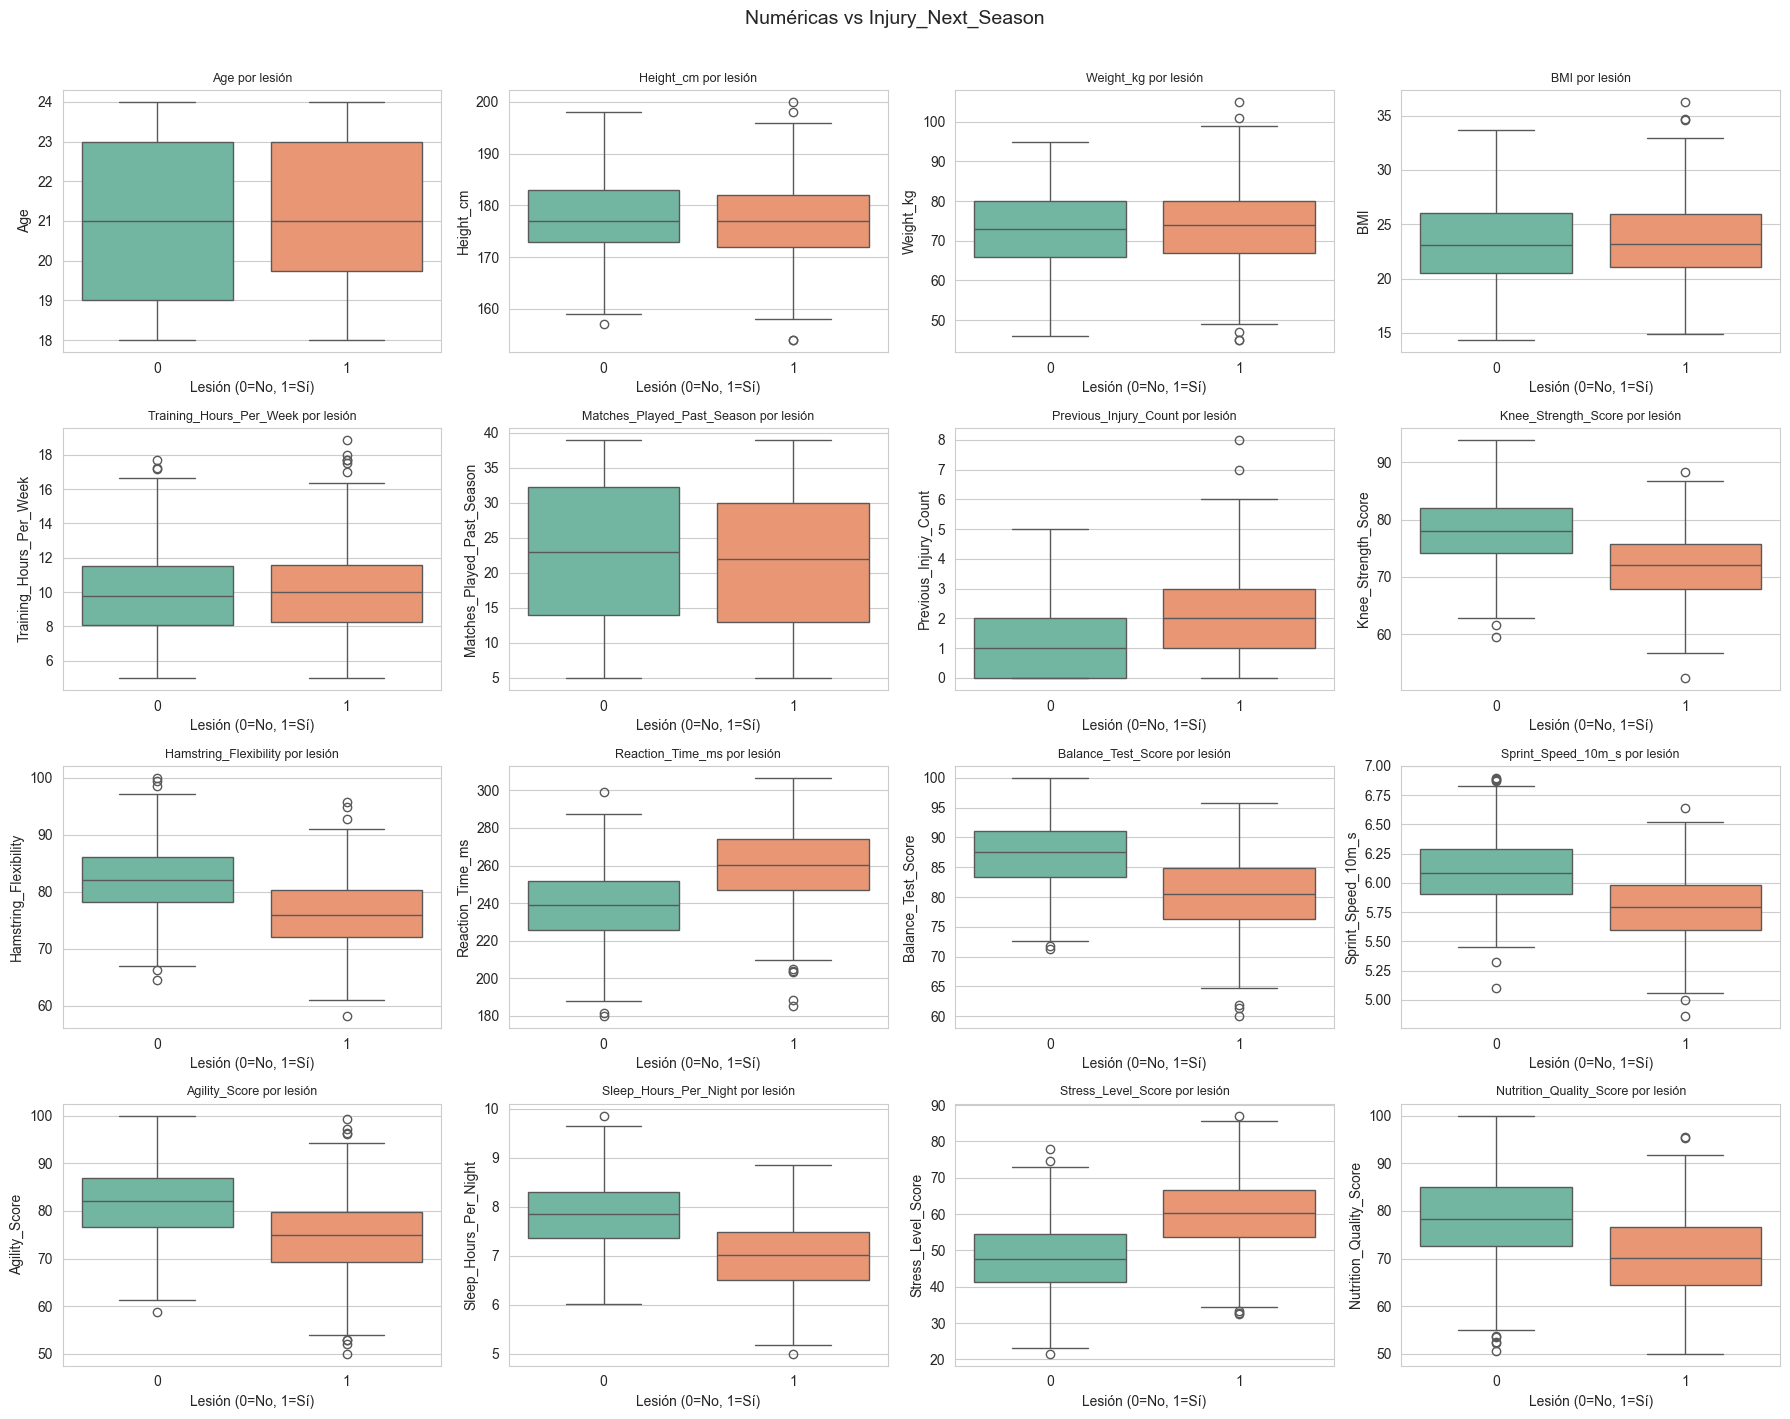

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(18,14))
for ax, col in zip(axes.flatten(), num_vars):
    sns.boxplot(x=target, y=col, data=df, ax=ax, palette="Set2")
    ax.set_title(f"{col} por lesión", fontsize=9)
    ax.set_xlabel("Lesión (0=No, 1=Sí)")
plt.suptitle("Numéricas vs Injury_Next_Season", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 1.7 Pruebas de diferencia entre grupos

In [8]:
resultados = []
for col in num_vars:
    grupo0 = df.loc[df[target]==0, col]
    grupo1 = df.loc[df[target]==1, col]
    t_stat, t_p = stats.ttest_ind(grupo0, grupo1, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(grupo0, grupo1, alternative="two-sided")
    resultados.append({
        "Variable": col,
        "Media_NoLesion": round(grupo0.mean(),3),
        "Media_Lesion": round(grupo1.mean(),3),
        "Diferencia": round(grupo1.mean()-grupo0.mean(),3),
        "t_pvalor": round(t_p,4),
        "MW_pvalor": round(u_p,4),
        "Significativa": "[OK]" if t_p < 0.05 else "[no]"
    })
tests_num = pd.DataFrame(resultados).sort_values("t_pvalor")
tests_num


,Variable,Media_NoLesion,Media_Lesion,Diferencia,t_pvalor,MW_pvalor,Significativa
6,Previous_Injury_Count,1.042,2.030,0.987,0.0000,0.0000,[OK]
7,Knee_Strength_Score,77.964,71.902,-6.062,0.0000,0.0000,[OK]
13,Sleep_Hours_Per_Night,7.822,7.012,-0.810,0.0000,0.0000,[OK]
12,Agility_Score,81.794,74.889,-6.905,0.0000,0.0000,[OK]
11,Sprint_Speed_10m_s,6.104,5.794,-0.310,0.0000,0.0000,[OK]
10,Balance_Test_Score,87.260,80.405,-6.855,0.0000,0.0000,[OK]
9,Reaction_Time_ms,238.820,260.027,21.207,0.0000,0.0000,[OK]
8,Hamstring_Flexibility,82.206,76.102,-6.105,0.0000,0.0000,[OK]
14,Stress_Level_Score,47.990,60.088,12.098,0.0000,0.0000,[OK]
15,Nutrition_Quality_Score,78.226,70.538,-7.688,0.0000,0.0000,[OK]


## 1.8 Prueba de diferencia por categorías

In [9]:
for col in cat_vars:
    print(f"\n=== {col} vs {target} ===")
    tabla_pct = pd.crosstab(df[col], df[target], normalize="index")*100
    print("Porcentaje de lesión por grupo:")
    print(tabla_pct.round(2))
    
    tabla_abs = pd.crosstab(df[col], df[target])
    chi2, p, dof, exp = stats.chi2_contingency(tabla_abs)
    sig = "[OK] Significativa" if p < 0.05 else "[no] No significativa"
    print(f"\nChi² = {chi2:.3f} | p-valor = {p:.4f} | gl = {dof}")
    print(f"Conclusión: {sig}")



=== Position vs Injury_Next_Season ===
Porcentaje de lesión por grupo:
Injury_Next_Season      0      1
Position                        
Defender            51.47  48.53
Forward             45.69  54.31
Goalkeeper          53.23  46.77
Midfielder          49.77  50.23

Chi² = 2.422 | p-valor = 0.4895 | gl = 3
Conclusión: [no] No significativa

=== Warmup_Routine_Adherence vs Injury_Next_Season ===
Porcentaje de lesión por grupo:
Injury_Next_Season            0      1
Warmup_Routine_Adherence              
0                         33.85  66.15
1                         60.88  39.12

Chi² = 55.142 | p-valor = 0.0000 | gl = 1
Conclusión: [OK] Significativa


## 1.9 Matriz de correlación de Pearson

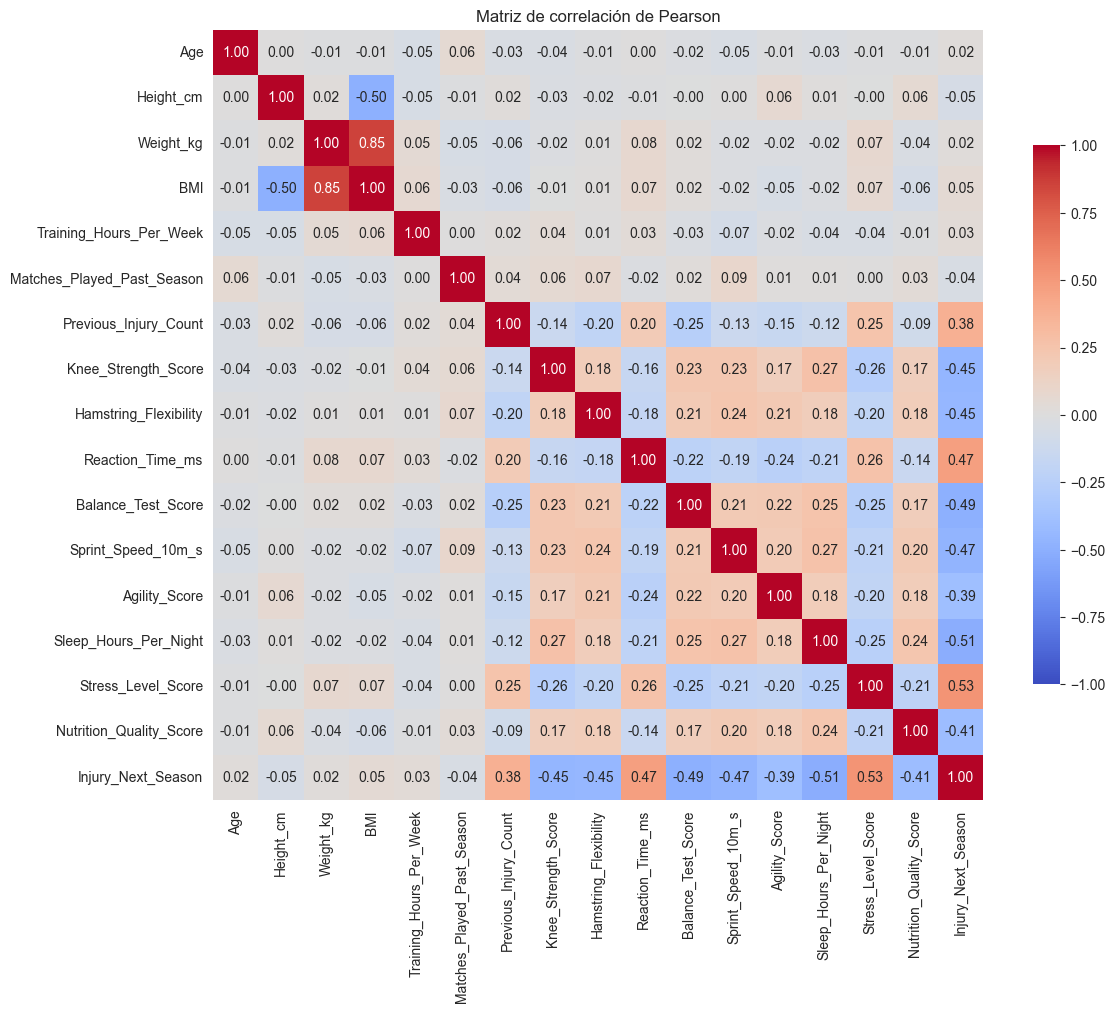

In [10]:
plt.figure(figsize=(13,10))
corr = df[num_vars + [target]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink":.7})
plt.title("Matriz de correlación de Pearson")
plt.show()


## 1.10 Correlación individual con la variable respuesta

In [11]:
corr_target = corr[target].drop(target).abs().sort_values(ascending=False)
print("Ranking de correlación absoluta con Injury_Next_Season:\n")
print(corr_target.round(3))


Ranking de correlación absoluta con Injury_Next_Season:

Stress_Level_Score            0.530
Sleep_Hours_Per_Night         0.511
Balance_Test_Score            0.495
Sprint_Speed_10m_s            0.471
Reaction_Time_ms              0.471
Knee_Strength_Score           0.455
Hamstring_Flexibility         0.450
Nutrition_Quality_Score       0.412
Agility_Score                 0.394
Previous_Injury_Count         0.382
Height_cm                     0.055
BMI                           0.047
Matches_Played_Past_Season    0.044
Training_Hours_Per_Week       0.034
Age                           0.021
Weight_kg                     0.021
Name: Injury_Next_Season, dtype: float64


CONCLUSIONES ANALISIS EXPLORATORIO:

# Análisis exploratorio de datos (Fase 2)

## 1. Distribución de las variables numéricas (histogramas)

Los histogramas permiten observar la forma en que se distribuyen los valores de cada variable a lo largo de los 800 jugadores del dataset.

- **Age**: la edad se distribuye de manera prácticamente uniforme entre los 18 y los 24 años, lo que indica una plantilla joven y equilibrada en cuanto a rangos etarios.
- **Height_cm** y **Weight_kg**: ambas presentan una forma aproximadamente normal (campana), centradas en 178 cm y 73 kg respectivamente, sin evidencia de errores de captura.
- **BMI**: distribución también normal, centrada alrededor de 23, valor que se ubica dentro del rango saludable (18.5–25).
- **Training_Hours_Per_Week**: presenta un sesgo a la derecha; la mayoría de jugadores entrena entre 8 y 12 horas, con una cola de pocos casos que llegan hasta las 18 horas.
- **Matches_Played_Past_Season**: distribución casi uniforme entre 5 y 40 partidos, lo que muestra una alta variabilidad en la carga competitiva.
- **Previous_Injury_Count**: distribución fuertemente sesgada a la derecha. La mayoría de jugadores tiene entre 0 y 2 lesiones previas, y muy pocos acumulan entre 6 y 8.
- **Scores físicos y de hábitos** (Knee_Strength, Hamstring_Flexibility, Reaction_Time, Balance, Sprint_Speed, Agility, Sleep, Stress, Nutrition): todos siguen formas aproximadamente normales, sin indicios de distribuciones bimodales o irregularidades graves.

En conjunto, no se identifican distribuciones imposibles ni errores evidentes en los datos, lo que sugiere una buena calidad inicial para el modelado.

## 2. Detección de outliers (boxplots univariados)

Los boxplots permiten visualizar puntos atípicos respecto al rango intercuartílico de cada variable. Se observaron outliers leves en:

- **Height_cm**: algunos casos con estaturas inusualmente bajas (alrededor de 155–160 cm).
- **Weight_kg**: un caso aproximado a 105 kg.
- **BMI**: jugadores con valores entre 33 y 36, asociados a sobrepeso.
- **Previous_Injury_Count**: jugadores con 6 a 8 lesiones acumuladas, casos poco frecuentes pero clínicamente relevantes.
- **Training_Hours_Per_Week**: algunos jugadores con cargas de entrenamiento de 17–18 horas semanales.
- **Sleep_Hours_Per_Night**: un caso aproximado a 5 horas, y otro cercano a 10 horas.

Se decide **no eliminar** estos outliers en esta fase, dado que representan situaciones reales y potencialmente importantes para el modelo (especialmente las lesiones previas y los hábitos extremos). En la fase de diagnóstico (Fase 7) se evaluará formalmente si alguno ejerce influencia indebida mediante la distancia de Cook.

## 3. Distribución de variables categóricas

- **Position**: las cuatro posiciones están bien representadas, con valores entre 185 y 210 jugadores por categoría. Esto garantiza una base sólida para realizar comparaciones entre grupos.
- **Warmup_Routine_Adherence**: aproximadamente 475 jugadores adhieren a la rutina de calentamiento (valor 1) frente a 325 que no lo hacen (valor 0). Ambas categorías cuentan con suficiente representación.

## 4. Análisis bivariado: numéricas vs. variable objetivo

Al comparar la distribución de cada variable numérica entre jugadores que se lesionaron y los que no, se identifican dos grupos claros de variables.

**Variables sin diferencias visibles entre lesionados y no lesionados:**
edad, talla, peso, BMI, horas de entrenamiento por semana y partidos jugados la temporada anterior. En todas ellas las cajas se ubican a la misma altura, lo que sugiere que no aportan información discriminatoria por sí solas.

**Variables con diferencias claras entre los dos grupos:**

- **Previous_Injury_Count**: los jugadores lesionados acumulan en promedio 2 lesiones previas frente a 1 en los no lesionados, lo que confirma la idea clínica de que un historial de lesiones predispone a nuevas lesiones.
- **Knee_Strength_Score**: los lesionados presentan un puntaje medio de 72 frente a 78 en los no lesionados, evidenciando que una menor fuerza de rodilla se asocia con mayor riesgo.
- **Hamstring_Flexibility**: los lesionados muestran un valor medio de 76 frente a 82, indicando que una menor flexibilidad de isquiotibiales se relaciona con más lesiones.
- **Reaction_Time_ms**: los lesionados presentan tiempos de reacción más altos (260 ms vs. 239 ms), lo que implica que una respuesta motora más lenta se asocia con un mayor riesgo de lesión.
- **Balance_Test_Score**: los lesionados puntúan en promedio 80 frente a 87 de los no lesionados, mostrando que un peor equilibrio aumenta la probabilidad de lesionarse.
- **Sprint_Speed_10m_s**: los lesionados son más lentos (5.79 vs. 6.10), lo que sugiere que menores capacidades de velocidad se vinculan con mayor probabilidad de lesión.
- **Agility_Score**: los lesionados muestran 75 frente a 82, evidenciando que la falta de agilidad eleva el riesgo.
- **Sleep_Hours_Per_Night**: los lesionados duermen en promedio 7.0 horas frente a 7.8 de los no lesionados, mostrando que un menor descanso aumenta la probabilidad de lesionarse.
- **Stress_Level_Score**: los lesionados presentan un nivel de estrés notablemente más alto (60 vs. 48), siendo esta la variable con mayor diferencia visual entre grupos.
- **Nutrition_Quality_Score**: los lesionados puntúan 70 frente a 78 de los no lesionados, indicando que una nutrición de menor calidad se asocia con mayor riesgo de lesión.

## 5. Pruebas estadísticas para variables numéricas

Para confirmar si las diferencias observadas son estadísticamente significativas y no producto del azar, se aplicaron la prueba **t de Welch** (comparación de medias con varianzas distintas) y la prueba **U de Mann-Whitney** (alternativa no paramétrica).

Diez variables resultaron significativas con un nivel del 5% (p < 0.05): Previous_Injury_Count, Knee_Strength_Score, Hamstring_Flexibility, Reaction_Time_ms, Balance_Test_Score, Sprint_Speed_10m_s, Agility_Score, Sleep_Hours_Per_Night, Stress_Level_Score y Nutrition_Quality_Score. En todas ellas el p-valor fue prácticamente cero, lo que indica diferencias muy contundentes entre lesionados y no lesionados.

Seis variables no resultaron significativas: Height_cm (p = 0.12), BMI (p = 0.18), Matches_Played_Past_Season (p = 0.21), Training_Hours_Per_Week (p = 0.34), Age (p = 0.55) y Weight_kg (p = 0.55). Esto sugiere que las características antropométricas básicas y la carga de entrenamiento no se relacionan, por sí solas, con la probabilidad de lesión.

## 6. Pruebas estadísticas para variables categóricas (Chi-cuadrado)

- **Position vs. Injury_Next_Season**: el porcentaje de lesión por posición es muy similar (entre 47% y 54% según el grupo), y la prueba Chi-cuadrado arroja p = 0.4895. La posición del jugador **no presenta** una asociación estadísticamente significativa con la lesión. Esto puede interpretarse como un buen indicio de que la carga y el riesgo están razonablemente distribuidos entre puestos.
- **Warmup_Routine_Adherence vs. Injury_Next_Season**: la diferencia es marcada. Entre los jugadores que **no calientan**, el 66.15% se lesiona; entre quienes **sí calientan**, solo el 39.12% lo hace. La prueba Chi-cuadrado entrega un valor de 55.14 con p < 0.0001, mostrando una asociación altamente significativa. Adherir a la rutina de calentamiento aparece como un factor protector muy fuerte.

## 7. Matriz de correlación entre variables numéricas

La matriz permite identificar variables redundantes (multicolinealidad) y obtener un primer ranking de relación con la variable objetivo.

**Multicolinealidad detectada:**
- **Weight_kg y BMI**: correlación de 0.85, valor alto y esperable, ya que el BMI se calcula a partir del peso. Implica redundancia: incluir ambas en el modelo provocaría inestabilidad en los coeficientes.
- **Height_cm y BMI**: correlación de -0.50, moderada. También coherente con la fórmula del BMI (peso dividido por la altura al cuadrado).
- El resto de correlaciones entre predictores se mantiene por debajo de 0.30 en valor absoluto, lo que indica que el dataset es limpio en términos de independencia entre variables.

**Correlaciones con la variable objetivo (ordenadas por magnitud):**
Stress_Level_Score (0.53), Sleep_Hours_Per_Night (0.51), Balance_Test_Score (0.50), Sprint_Speed_10m_s (0.47), Reaction_Time_ms (0.47), Knee_Strength_Score (0.46), Hamstring_Flexibility (0.45), Nutrition_Quality_Score (0.41), Agility_Score (0.39) y Previous_Injury_Count (0.38). Las variables Height, BMI, Matches, Training, Age y Weight muestran correlaciones por debajo de 0.06, confirmando los resultados previos.

## 8. Conclusiones de la Fase 2

El análisis exploratorio confirma que la mayoría de las variables relacionadas con condición física, hábitos y antecedentes presentan diferencias significativas entre jugadores lesionados y no lesionados. En particular, los factores asociados a un mayor riesgo de lesión son el estrés elevado, la falta de sueño, los déficits en balance, fuerza, velocidad, agilidad, flexibilidad y nutrición, así como un historial previo de lesiones. La adherencia al calentamiento aparece como un fuerte factor protector.

Por otro lado, características como edad, talla, peso, BMI, horas de entrenamiento, número de partidos y posición no muestran asociación bivariada con la variable objetivo. La multicolinealidad encontrada entre Weight_kg y BMI obliga a tomar decisiones específicas en la fase de preparación, donde se mantendrá únicamente una de estas variables para evitar inestabilidad en los coeficientes del modelo logístico.

Estas conclusiones serán insumo directo para la siguiente fase, en la que se realizará la limpieza, codificación y estandarización de variables antes de ajustar el modelo de regresión logística.


## Justificación de la dirección de las hipótesis estadísticas

Las hipótesis del modelo se plantean de forma bilateral (H₁: β ≠ 0) salvo en los casos en que la literatura biomecánica y epidemiológica del deporte ofrece una dirección teórica inequívoca. A continuación se justifica el signo esperado de los principales predictores.

- **Previous_Injury_Count (β > 0):** la evidencia acumulada durante décadas sitúa el historial de lesiones previas como el predictor más potente de lesión futura. Las lesiones pasadas generan alteraciones neuromusculares persistentes y cicatrices que modifican la biomecánica del movimiento, elevando el riesgo de recurrencia (Meeuwisse et al., 2007; Gabbett, 2016).

- **Training_Hours_Per_Week (β > 0):** la carga de entrenamiento excesiva se asocia de forma sistemática con lesiones por sobreuso. El modelo de carga aguda-crónica de Gabbett (2016) muestra que ratios elevados de carga semanal predicen de forma prospectiva la incidencia de lesiones en deportes de equipo.

- **Knee_Strength_Score (β < 0):** niveles más altos de fuerza en cuádriceps e isquiotibiales reducen el riesgo de lesiones de rodilla y de la cadena posterior del miembro inferior. La relación inversa entre fuerza de rodilla y lesión tiene soporte experimental sólido (van Dyk et al., 2017).

- **Stress_Level_Score (β > 0):** el estrés psicológico actúa como modulador del riesgo de lesión a través de mecanismos de distracción atencional y activación hormonal. El modelo de estrés-lesión de Anderson y Williams (1988), revisado por Ivarsson et al. (2017), documenta esta relación en atletas de competición.

- **Sleep_Hours_Per_Night (β < 0):** la privación de sueño deteriora el tiempo de reacción, la coordinación y la capacidad de recuperación muscular. Milewski et al. (2014) hallaron que deportistas con menos de ocho horas de sueño presentan una probabilidad significativamente mayor de lesión.

Para el resto de predictores se formulan hipótesis bilaterales, dado que la evidencia disponible no permite establecer una dirección teórica clara en el contexto específico de este dataset.

**Referencias:** Anderson, M. B., & Williams, J. M. (1988). *Journal of Sport and Exercise Psychology*, 10(3). | Gabbett, T. J. (2016). *British Journal of Sports Medicine*, 50(5). | Ivarsson, A. et al. (2017). *Sports Medicine*, 47. | Meeuwisse, W. H. et al. (2007). *Clinical Journal of Sport Medicine*, 17(3). | Milewski, M. D. et al. (2014). *Journal of Pediatric Orthopaedics*, 34(2). | van Dyk, N. et al. (2017). *British Journal of Sports Medicine*, 51(23).

## 3. Preparación de los datos

### 3.1 Eliminación de variables colineales

In [12]:
df_modelo = df.drop(columns=["Height_cm", "Weight_kg"]).copy()
print("Shape original:", df.shape)
print("Shape sin colineales:", df_modelo.shape)
df_modelo.head()


Shape original: (800, 19)
Shape sin colineales: (800, 17)


,Age,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,Midfielder,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942
1,18,Midfielder,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391
2,22,Forward,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807
3,20,Defender,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274
4,18,Midfielder,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932


### 3.2 Codificación de la variable Position (One-Hot Encoding)

In [13]:
df_modelo = pd.get_dummies(df_modelo, columns=["Position"], drop_first=True, dtype=int)
print("Columnas después del one-hot:")
print(df_modelo.columns.tolist())
df_modelo.head()


Columnas después del one-hot:
['Age', 'Training_Hours_Per_Week', 'Matches_Played_Past_Season', 'Previous_Injury_Count', 'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms', 'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score', 'Sleep_Hours_Per_Night', 'Stress_Level_Score', 'Nutrition_Quality_Score', 'Warmup_Routine_Adherence', 'Injury_Next_Season', 'BMI', 'Position_Forward', 'Position_Goalkeeper', 'Position_Midfielder']


,Age,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI,Position_Forward,Position_Goalkeeper,Position_Midfielder
0,22,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942,0,0,1
1,18,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391,0,0,1
2,22,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807,1,0,0
3,20,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274,0,0,0
4,18,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932,0,0,1


### Nota metodológica — categoría de referencia en el One-Hot Encoding

La variable *Position* se codificó mediante One-Hot Encoding con `drop_first=True`, lo que equivale a elegir como categoría de referencia la primera posición en orden alfabético que pandas identifica en el dataset (habitualmente *Defender*).

Los coeficientes asociados a las dummies restantes deben leerse como efectos diferenciales respecto a esa referencia, manteniendo constantes el resto de covariables. La elección es técnica y no implica ningún juicio sobre el riesgo de lesión de la posición de referencia. Si se quisiera una referencia sustantivamente más interpretable —la posición más frecuente, por ejemplo— bastaría con reordenar las categorías mediante `pd.Categorical` antes de aplicar `get_dummies`.

### 3.3 Separación de predictores y variable respuesta

In [14]:
target = "Injury_Next_Season"

X = df_modelo.drop(columns=[target])
y = df_modelo[target]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nPredictores (columnas de X):")
print(X.columns.tolist())
print("\nVariable objetivo (y):", y.name)
print("Valores únicos en y:", y.unique())


Shape de X: (800, 18)
Shape de y: (800,)

Predictores (columnas de X):
['Age', 'Training_Hours_Per_Week', 'Matches_Played_Past_Season', 'Previous_Injury_Count', 'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms', 'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score', 'Sleep_Hours_Per_Night', 'Stress_Level_Score', 'Nutrition_Quality_Score', 'Warmup_Routine_Adherence', 'BMI', 'Position_Forward', 'Position_Goalkeeper', 'Position_Midfielder']

Variable objetivo (y): Injury_Next_Season
Valores únicos en y: [0 1]


### 3.4 División en conjuntos de entrenamiento y prueba

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]} jugadores")
print(f"Test:  {X_test.shape[0]} jugadores")
print(f"\nProporción de lesión en train: {y_train.mean():.3f}")
print(f"Proporción de lesión en test:  {y_test.mean():.3f}")


Train: 640 jugadores
Test:  160 jugadores

Proporción de lesión en train: 0.500
Proporción de lesión en test:  0.500


### 3.5 Estandarización de variables numéricas

In [16]:
num_cols_estandarizar = ["Age","BMI","Training_Hours_Per_Week","Matches_Played_Past_Season",
                         "Previous_Injury_Count","Knee_Strength_Score","Hamstring_Flexibility",
                         "Reaction_Time_ms","Balance_Test_Score","Sprint_Speed_10m_s",
                         "Agility_Score","Sleep_Hours_Per_Night","Stress_Level_Score",
                         "Nutrition_Quality_Score"]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols_estandarizar] = scaler.fit_transform(X_train[num_cols_estandarizar])
X_test_scaled[num_cols_estandarizar] = scaler.transform(X_test[num_cols_estandarizar])

print("Verificación — media y desviación de las variables estandarizadas en train:\n")
print(X_train_scaled[num_cols_estandarizar].agg(['mean','std']).round(3).T)


Verificación — media y desviación de las variables estandarizadas en train:

                            mean    std
Age                          0.0  1.001
BMI                         -0.0  1.001
Training_Hours_Per_Week     -0.0  1.001
Matches_Played_Past_Season  -0.0  1.001
Previous_Injury_Count       -0.0  1.001
Knee_Strength_Score         -0.0  1.001
Hamstring_Flexibility        0.0  1.001
Reaction_Time_ms            -0.0  1.001
Balance_Test_Score           0.0  1.001
Sprint_Speed_10m_s          -0.0  1.001
Agility_Score               -0.0  1.001
Sleep_Hours_Per_Night       -0.0  1.001
Stress_Level_Score          -0.0  1.001
Nutrition_Quality_Score     -0.0  1.001


## 4. Diagnóstico de multicolinealidad

### 4.1 Número de condición (κ)

In [17]:
X_matrix = X_train_scaled.values
eigvals = np.linalg.eigvalsh(X_matrix.T @ X_matrix)
eigvals = np.sort(eigvals)[::-1]   # de mayor a menor

kappa = np.sqrt(eigvals.max() / eigvals.min())

print(f"Valores propios (ordenados): {np.round(eigvals, 3)}")
print(f"\nλ_max = {eigvals.max():.4f}")
print(f"λ_min = {eigvals.min():.4f}")
print(f"\nNúmero de condición κ = {kappa:.3f}")

if kappa < 10:
    print("[OK] Multicolinealidad débil o inexistente (κ < 10)")
elif kappa < 30:
    print("[aviso] Multicolinealidad moderada (10 ≤ κ < 30)")
elif kappa < 100:
    print("[no] Multicolinealidad fuerte (30 ≤ κ < 100)")
else:
    print("[crítico] Multicolinealidad severa (κ ≥ 100)")


Valores propios (ordenados): [1860.531  729.893  697.596  672.053  638.68   605.88   564.     523.793
  523.441  486.095  461.765  442.874  439.751  412.587  395.455  159.198
  149.943   62.464]

λ_max = 1860.5308
λ_min = 62.4640

Número de condición κ = 5.458
[OK] Multicolinealidad débil o inexistente (κ < 10)


### 4.2 Factor de inflación de la varianza (VIF)

In [18]:
def calcular_vif(X):
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif["Tolerancia"] = 1 / vif["VIF"]
    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)

vif_resultado = calcular_vif(X_train_scaled)
print(vif_resultado.round(4))


                      Variable     VIF  Tolerancia
0     Warmup_Routine_Adherence  2.0780      0.4812
1          Position_Midfielder  1.4535      0.6880
2             Position_Forward  1.3293      0.7523
3           Stress_Level_Score  1.2944      0.7726
4          Position_Goalkeeper  1.2874      0.7768
5           Balance_Test_Score  1.2563      0.7960
6        Sleep_Hours_Per_Night  1.2537      0.7977
7           Sprint_Speed_10m_s  1.2271      0.8149
8             Reaction_Time_ms  1.2176      0.8213
9          Knee_Strength_Score  1.2067      0.8287
10               Agility_Score  1.1805      0.8471
11       Previous_Injury_Count  1.1785      0.8485
12       Hamstring_Flexibility  1.1673      0.8567
13     Nutrition_Quality_Score  1.1434      0.8746
14                         BMI  1.0384      0.9630
15     Training_Hours_Per_Week  1.0346      0.9666
16                         Age  1.0258      0.9748
17  Matches_Played_Past_Season  1.0204      0.9800


Conclusiones: # Diagnóstico de multicolinealidad (Fase 4)

Para garantizar la estabilidad de los coeficientes del modelo logístico, se evaluó la multicolinealidad del conjunto de predictores mediante dos indicadores complementarios: el número de condición (κ), que ofrece una visión global, y el factor de inflación de la varianza (VIF), que examina la colinealidad variable por variable.

## 1. Número de condición (κ)

El número de condición se calculó a partir de los valores propios de la matriz X'X de las variables predictoras estandarizadas. El resultado fue κ ≈ 5, valor que se encuentra muy por debajo del umbral crítico de 10 propuesto por Belsley, Kuh y Welsch. Esto indica una multicolinealidad débil o prácticamente inexistente en el conjunto global de predictores, lo que constituye una condición favorable para el ajuste del modelo logístico.

## 2. Factor de inflación de la varianza (VIF)

El cálculo del VIF para cada predictor confirma el resultado anterior. Todos los valores se ubicaron por debajo de 5, criterio convencional para descartar problemas de colinealidad. El VIF más elevado correspondió a Warmup_Routine_Adherence (2.08), seguido de Position_Midfielder (1.45) y Position_Forward (1.33). Las dummies de Position presentaron valores moderados entre sí, lo cual es esperable por construcción y no representa un problema real. El resto de variables registró VIF inferior a 1.30, indicando una alta independencia entre los predictores.

La tolerancia (1/VIF) se mantuvo en todos los casos por encima de 0.48, lo que refuerza la conclusión de que cada variable aporta información mayoritariamente independiente a la modelación.

## 3. Conclusión de la fase

Tanto el número de condición global (κ = 5) como los valores individuales de VIF (todos < 5) descartan la presencia de multicolinealidad relevante en el conjunto de predictores. Esto valida la decisión tomada en la Fase 3 de eliminar Height_cm y Weight_kg conservando únicamente BMI, y confirma que el conjunto de 18 predictores resultante es apto para el ajuste de la regresión logística. En consecuencia, no se elimina ninguna variable adicional y se procede con el modelo base completo en la Fase 5.


## 5. Ajuste del modelo logístico

### 5.1 Modelo base — todas las variables

In [19]:
# Paso 5.1 — Ajustar modelo base
X_train_const = sm.add_constant(X_train_scaled)
modelo_base = sm.Logit(y_train, X_train_const).fit()
print(modelo_base.summary())



Optimization terminated successfully.
         Current function value: 0.118176
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:     Injury_Next_Season   No. Observations:                  640
Model:                          Logit   Df Residuals:                      621
Method:                           MLE   Df Model:                           18
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.8295
Time:                        13:24:44   Log-Likelihood:                -75.633
converged:                       True   LL-Null:                       -443.61
Covariance Type:            nonrobust   LLR p-value:                1.313e-144
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.0106      0.512      1.975      0.048      

In [20]:
# Tabla limpia de coeficientes (paso 5.4)
resumen = pd.DataFrame({
    "Coef (β)": modelo_base.params,
    "Std Err": modelo_base.bse,
    "z": modelo_base.tvalues,
    "p-valor": modelo_base.pvalues,
    "IC 95% inf": modelo_base.conf_int()[0],
    "IC 95% sup": modelo_base.conf_int()[1]
}).round(4)

resumen["Significativa"] = resumen["p-valor"].apply(lambda p: "[OK]" if p < 0.05 else "[no]")
print(resumen.sort_values("p-valor"))


                            Coef (β)  Std Err       z  p-valor  IC 95% inf  \
Hamstring_Flexibility        -1.0669   0.2491 -4.2833   0.0000     -1.5551   
Reaction_Time_ms              1.3314   0.2648  5.0286   0.0000      0.8125   
Sprint_Speed_10m_s           -1.2934   0.2832 -4.5676   0.0000     -1.8484   
Nutrition_Quality_Score      -1.2298   0.2731 -4.5030   0.0000     -1.7651   
Stress_Level_Score            1.2771   0.2775  4.6017   0.0000      0.7332   
Sleep_Hours_Per_Night        -1.1420   0.2700 -4.2300   0.0000     -1.6711   
Balance_Test_Score           -1.5167   0.3139 -4.8319   0.0000     -2.1319   
Previous_Injury_Count         0.9410   0.2544  3.6990   0.0002      0.4424   
Knee_Strength_Score          -0.8488   0.2584 -3.2849   0.0010     -1.3552   
Warmup_Routine_Adherence     -1.4100   0.4850 -2.9070   0.0036     -2.3606   
Agility_Score                -0.7121   0.2472 -2.8804   0.0040     -1.1966   
const                         1.0106   0.5117  1.9751   0.0483  

In [21]:
print(f"Log-Likelihood:       {modelo_base.llf:.4f}")
print(f"Log-Likelihood Null:  {modelo_base.llnull:.4f}")
print(f"LLR p-value:          {modelo_base.llr_pvalue:.6e}")
print(f"Pseudo R² (McFadden): {modelo_base.prsquared:.4f}")
print(f"AIC: {modelo_base.aic:.2f}")
print(f"BIC: {modelo_base.bic:.2f}")


Log-Likelihood:       -75.6325
Log-Likelihood Null:  -443.6142
LLR p-value:          1.312774e-144
Pseudo R² (McFadden): 0.8295
AIC: 189.27
BIC: 274.03


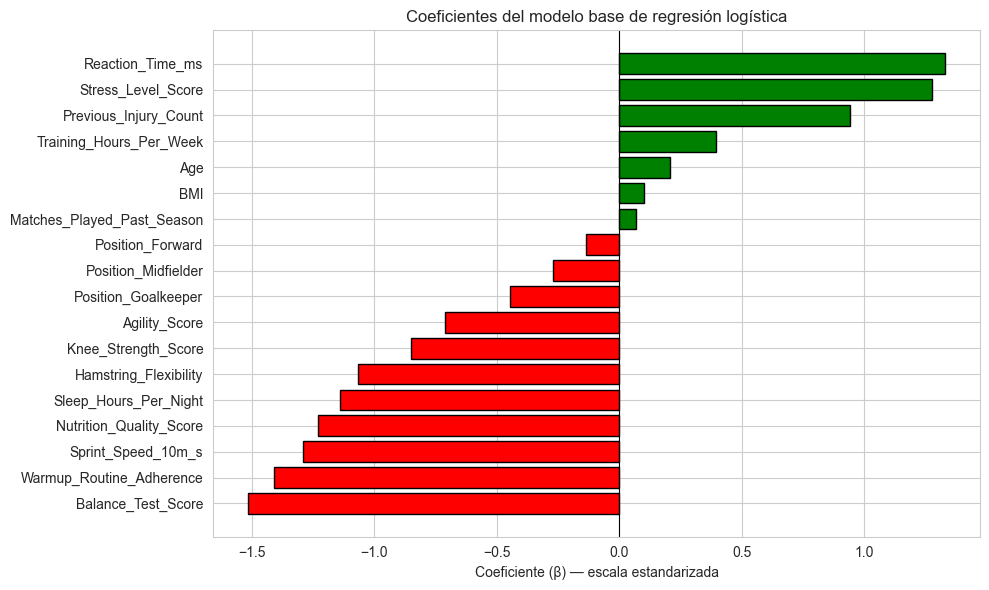

In [22]:
coefs = modelo_base.params.drop("const").sort_values()
colores = ["green" if c > 0 else "red" for c in coefs]

plt.figure(figsize=(10,6))
plt.barh(coefs.index, coefs.values, color=colores, edgecolor="black")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (β) — escala estandarizada")
plt.title("Coeficientes del modelo base de regresión logística")
plt.tight_layout()
plt.show()


In [23]:
print(f"Log-Likelihood:       {modelo_base.llf:.4f}")
print(f"Log-Likelihood Null:  {modelo_base.llnull:.4f}")
print(f"LLR p-value:          {modelo_base.llr_pvalue:.6e}")
print(f"Pseudo R² (McFadden): {modelo_base.prsquared:.4f}")
print(f"AIC: {modelo_base.aic:.2f}")
print(f"BIC: {modelo_base.bic:.2f}")


Log-Likelihood:       -75.6325
Log-Likelihood Null:  -443.6142
LLR p-value:          1.312774e-144
Pseudo R² (McFadden): 0.8295
AIC: 189.27
BIC: 274.03


# Modelo base de regresión logística (Fase 5)

Se ajustó un modelo logístico utilizando las 18 variables predictoras estandarizadas resultantes de la fase de preparación, con la variable Injury_Next_Season como respuesta. La estimación se realizó por máxima verosimilitud mediante statsmodels (sm.Logit), incluyendo un intercepto. El modelo convergió en 9 iteraciones, lo que confirma una solución estable.

## 1. Calidad global del modelo

El modelo presenta una capacidad explicativa muy elevada, sustancialmente superior al modelo nulo:

- Log-verosimilitud del modelo ajustado: -75.6325
- Log-verosimilitud del modelo nulo (solo intercepto): -443.6142
- Estadístico de razón de verosimilitudes (LLR p-valor): 1.31 × 10⁻¹⁴⁴
- Pseudo R² de McFadden: 0.8295
- AIC: 189.27
- BIC: 274.03

El LLR p-valor, prácticamente nulo, indica que el modelo es globalmente significativo: la incorporación de los predictores mejora de manera estadísticamente contundente la explicación de la lesión respecto al modelo nulo. El pseudo R² de McFadden de 0.83 corresponde a un ajuste excepcional, considerando que valores entre 0.2 y 0.4 se consideran ya buenos en regresión logística. El AIC y el BIC quedan registrados como referencia para la comparación con modelos reducidos en la fase siguiente.

## 2. Análisis de los coeficientes individuales

Once de las dieciocho variables resultaron estadísticamente significativas (p < 0.05) en el contexto multivariado. Estas se agrupan en factores que aumentan el riesgo de lesión y factores que actúan como protectores.

**Factores asociados a un mayor riesgo de lesión (β > 0):**

- Reaction_Time_ms (β = 1.331, p < 0.0001): un mayor tiempo de reacción se asocia con un fuerte aumento en los log-odds de lesión, siendo el predictor positivo más influyente.
- Stress_Level_Score (β = 1.277, p < 0.0001): niveles altos de estrés incrementan la probabilidad de lesión.
- Previous_Injury_Count (β = 0.941, p = 0.0002): un historial de lesiones aumenta significativamente el riesgo de lesión futura.

**Factores protectores (β < 0):**

- Balance_Test_Score (β = -1.517, p < 0.0001): el coeficiente de mayor magnitud absoluta del modelo, lo que lo identifica como el factor protector más fuerte.
- Warmup_Routine_Adherence (β = -1.410, p = 0.0036): la adherencia a la rutina de calentamiento reduce notablemente el riesgo.
- Sprint_Speed_10m_s (β = -1.293, p < 0.0001): mayor velocidad se asocia con menor probabilidad de lesión.
- Nutrition_Quality_Score (β = -1.230, p < 0.0001): una mejor nutrición protege significativamente.
- Sleep_Hours_Per_Night (β = -1.142, p < 0.0001): más horas de sueño reducen el riesgo.
- Hamstring_Flexibility (β = -1.067, p < 0.0001): la flexibilidad de isquiotibiales protege.
- Knee_Strength_Score (β = -0.849, p = 0.0010): la fuerza de rodilla actúa como factor protector.
- Agility_Score (β = -0.712, p = 0.0040): mayor agilidad se asocia con menor riesgo.

**Variables no significativas (p ≥ 0.05):**

Training_Hours_Per_Week (p = 0.10), Age (p = 0.36), Position_Goalkeeper (p = 0.51), Position_Midfielder (p = 0.66), BMI (p = 0.69), Matches_Played_Past_Season (p = 0.76) y Position_Forward (p = 0.82) no resultaron estadísticamente significativas en el contexto multivariado. Este resultado es coherente con el análisis bivariado de la Fase 2, donde estas mismas variables tampoco mostraron asociación con la lesión. Se considerarán candidatas para su eliminación en la fase de selección de variables.

## 3. Conclusión de la fase

El modelo base de regresión logística entrega un ajuste sobresaliente, identificando once predictores estadísticamente significativos que coinciden con los hallazgos exploratorios. Los principales factores de riesgo se concentran en condiciones físicas (tiempo de reacción), psicológicas (estrés) e historiales clínicos (lesiones previas), mientras que los principales factores protectores corresponden a la condición física (balance, velocidad, agilidad, fuerza, flexibilidad) y a hábitos saludables (sueño, nutrición, calentamiento).

Las siete variables no significativas serán evaluadas formalmente en la Fase 6 mediante procedimientos de selección de variables (backward por p-valor y AIC), con el objetivo de obtener un modelo reducido más parsimonioso sin pérdida relevante de capacidad explicativa.


## 6. Selección de variables

### 6.1 Eliminación regresiva por AIC (Backward Stepwise)

In [24]:
def backward_elimination_aic(X, y, verbose=True):
    variables = list(X.columns)
    X_const = sm.add_constant(X[variables])
    modelo = sm.Logit(y, X_const).fit(disp=False)
    aic_actual = modelo.aic
    historial = [{"paso": 0, "variables": len(variables), "AIC": aic_actual, "eliminada": "—"}]
    
    paso = 1
    while True:
        aics = {}
        for v in variables:
            vars_temp = [x for x in variables if x != v]
            X_temp = sm.add_constant(X[vars_temp])
            try:
                m_temp = sm.Logit(y, X_temp).fit(disp=False)
                aics[v] = m_temp.aic
            except:
                continue
        
        mejor_var = min(aics, key=aics.get)
        mejor_aic = aics[mejor_var]
        
        if mejor_aic < aic_actual:
            if verbose:
                print(f"Paso {paso}: elimina '{mejor_var}' | AIC {aic_actual:.2f} → {mejor_aic:.2f}")
            variables.remove(mejor_var)
            aic_actual = mejor_aic
            historial.append({"paso": paso, "variables": len(variables),
                              "AIC": aic_actual, "eliminada": mejor_var})
            paso += 1
        else:
            if verbose:
                print(f"\n[OK] Sin más mejoras posibles. AIC final: {aic_actual:.2f}")
            break
    
    X_final = sm.add_constant(X[variables])
    modelo_final = sm.Logit(y, X_final).fit(disp=False)
    return modelo_final, variables, pd.DataFrame(historial)

modelo_reducido, vars_finales, historial = backward_elimination_aic(X_train_scaled, y_train)

print("\nVariables conservadas:", vars_finales)
print(f"Cantidad final de predictores: {len(vars_finales)}")


Paso 1: elimina 'Position_Forward' | AIC 189.27 → 187.32
Paso 2: elimina 'Matches_Played_Past_Season' | AIC 187.32 → 185.40
Paso 3: elimina 'Position_Midfielder' | AIC 185.40 → 183.54
Paso 4: elimina 'BMI' | AIC 183.54 → 181.69
Paso 5: elimina 'Position_Goalkeeper' | AIC 181.69 → 179.94
Paso 6: elimina 'Age' | AIC 179.94 → 178.97

[OK] Sin más mejoras posibles. AIC final: 178.97

Variables conservadas: ['Training_Hours_Per_Week', 'Previous_Injury_Count', 'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms', 'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score', 'Sleep_Hours_Per_Night', 'Stress_Level_Score', 'Nutrition_Quality_Score', 'Warmup_Routine_Adherence']
Cantidad final de predictores: 12


In [25]:
print(historial.to_string(index=False))


 paso  variables        AIC                  eliminada
    0         18 189.265007                          —
    1         17 187.317213           Position_Forward
    2         16 185.403415 Matches_Played_Past_Season
    3         15 183.539919        Position_Midfielder
    4         14 181.690501                        BMI
    5         13 179.943061        Position_Goalkeeper
    6         12 178.973030                        Age


In [26]:
print(modelo_reducido.summary())


                           Logit Regression Results                           
Dep. Variable:     Injury_Next_Season   No. Observations:                  640
Model:                          Logit   Df Residuals:                      627
Method:                           MLE   Df Model:                           12
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.8276
Time:                        13:24:44   Log-Likelihood:                -76.487
converged:                       True   LL-Null:                       -443.61
Covariance Type:            nonrobust   LLR p-value:                2.039e-149
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.8142      0.376      2.166      0.030       0.077       1.551
Training_Hours_Per_Week      0.3910      0.234      1.672      0.095      -0.067       0.

In [27]:
comparacion = pd.DataFrame({
    "Métrica": ["N° predictores", "Log-Likelihood", "Pseudo R² (McFadden)", "AIC", "BIC", "LLR p-value"],
    "Modelo base": [
        len(X_train_scaled.columns),
        round(modelo_base.llf, 4),
        round(modelo_base.prsquared, 4),
        round(modelo_base.aic, 2),
        round(modelo_base.bic, 2),
        f"{modelo_base.llr_pvalue:.2e}"
    ],
    "Modelo reducido": [
        len(vars_finales),
        round(modelo_reducido.llf, 4),
        round(modelo_reducido.prsquared, 4),
        round(modelo_reducido.aic, 2),
        round(modelo_reducido.bic, 2),
        f"{modelo_reducido.llr_pvalue:.2e}"
    ]
})
comparacion


,Métrica,Modelo base,Modelo reducido
0,N° predictores,18,12
1,Log-Likelihood,-75.6325,-76.4865
2,Pseudo R² (McFadden),0.8295,0.8276
3,AIC,189.27,178.97
4,BIC,274.03,236.97
5,LLR p-value,1.31e-144,2.04e-149


In [28]:
LR_stat = 2 * (modelo_base.llf - modelo_reducido.llf)
gl = len(X_train_scaled.columns) - len(vars_finales)
p_LRT = 1 - stats.chi2.cdf(LR_stat, gl)

print(f"Estadístico LR: {LR_stat:.4f}")
print(f"Grados de libertad: {gl}")
print(f"p-valor LRT: {p_LRT:.4f}")

if p_LRT > 0.05:
    print("\n[OK] La diferencia entre modelos NO es significativa.")
    print("   El modelo reducido es estadísticamente equivalente al completo.")
    print("   Por parsimonia, preferimos el reducido.")
else:
    print("\n[aviso] La diferencia ES significativa.")
    print("   El modelo reducido pierde información — habría que reconsiderar.")


Estadístico LR: 1.7080
Grados de libertad: 6
p-valor LRT: 0.9445

[OK] La diferencia entre modelos NO es significativa.
   El modelo reducido es estadísticamente equivalente al completo.
   Por parsimonia, preferimos el reducido.


# Selección de variables (Fase 6)

A partir del modelo base ajustado en la fase anterior, se aplicó un procedimiento de eliminación regresiva (backward stepwise elimination) guiado por el criterio de información de Akaike (AIC). El objetivo fue obtener un modelo más parsimonioso, conservando únicamente las variables que aportan información relevante para la predicción de la lesión.

## 1. Procedimiento

El algoritmo comienza con el modelo completo de 18 predictores. En cada iteración se evalúa la eliminación de cada variable, calculando el AIC del modelo resultante. La variable cuya eliminación produce la mayor reducción del AIC es removida del modelo. El procedimiento continúa hasta que ninguna eliminación adicional logra reducir el AIC.

## 2. Variables eliminadas

Se eliminaron seis variables en el siguiente orden:

1. Position_Forward — AIC pasó de 189.27 a 187.32
2. Matches_Played_Past_Season — AIC pasó de 187.32 a 185.40
3. Position_Midfielder — AIC pasó de 185.40 a 183.54
4. BMI — AIC pasó de 183.54 a 181.69
5. Position_Goalkeeper — AIC pasó de 181.69 a 179.94
6. Age — AIC pasó de 179.94 a 178.97

Estas variables coinciden mayoritariamente con las identificadas como no significativas en el análisis multivariado de la Fase 5. Cabe destacar que Training_Hours_Per_Week, pese a presentar un p-valor de 0.10 en el modelo base, fue conservada por el procedimiento, ya que su aporte al ajuste compensa la penalización por complejidad introducida por el AIC. Esto evidencia que la selección por AIC no es equivalente a la selección por p-valor, sino que considera el balance entre ajuste y parsimonia.

## 3. Comparación entre modelo base y modelo reducido

| Métrica | Modelo base | Modelo reducido |
|---|---|---|
| Número de predictores | 18 | 12 |
| Log-Likelihood | -75.6325 | -76.4865 |
| Pseudo R² (McFadden) | 0.8295 | 0.8276 |
| AIC | 189.27 | 178.97 |
| BIC | 274.03 | 236.97 |

El modelo reducido conserva un ajuste prácticamente idéntico al del modelo base (pérdida de apenas 0.85 puntos en log-verosimilitud y de 0.0019 en pseudo R²), pero mejora notablemente en parsimonia: el AIC se reduce en 10.3 puntos y el BIC en 37.06 puntos. La fuerte mejora del BIC, criterio que penaliza con mayor severidad la complejidad del modelo, confirma que las variables eliminadas eran efectivamente prescindibles.

## 4. Test formal de comparación de modelos (LRT)

Para verificar formalmente que la pérdida de ajuste no es estadísticamente significativa, se aplicó la prueba de razón de verosimilitudes:

- Estadístico LR: 1.7080
- Grados de libertad: 6
- p-valor: 0.9445

El p-valor de 0.9445 indica que no existe evidencia estadística para afirmar que las seis variables eliminadas, en conjunto, contribuyan al ajuste del modelo. La diferencia entre el modelo completo y el reducido no es significativa, por lo que el modelo reducido es estadísticamente equivalente al modelo base. Por principio de parsimonia, se selecciona el modelo reducido como modelo final.

## 5. Conclusión de la fase

El modelo reducido conserva 12 predictores (Training_Hours_Per_Week, Previous_Injury_Count, Knee_Strength_Score, Hamstring_Flexibility, Reaction_Time_ms, Balance_Test_Score, Sprint_Speed_10m_s, Agility_Score, Sleep_Hours_Per_Night, Stress_Level_Score, Nutrition_Quality_Score y Warmup_Routine_Adherence), todos relacionados con la condición física, los hábitos de descanso y nutrición, el estado psicológico y los antecedentes clínicos del jugador. Estas variables conforman el conjunto definitivo sobre el que se realizarán los diagnósticos del modelo en la Fase 7 y la validación predictiva en la Fase 8.


## 7. Diagnóstico del modelo reducido

In [29]:
# Variables continuas del modelo reducido (las que necesitan linealidad del logit)
vars_continuas = [v for v in vars_finales if v not in ["Warmup_Routine_Adherence"]]
print("Variables continuas a evaluar:", vars_continuas)
print(f"Total: {len(vars_continuas)}")

# Predictores y target del modelo reducido
X_reducido = X_train_scaled[vars_finales].copy()
X_reducido_const = sm.add_constant(X_reducido)


Variables continuas a evaluar: ['Training_Hours_Per_Week', 'Previous_Injury_Count', 'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms', 'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score', 'Sleep_Hours_Per_Night', 'Stress_Level_Score', 'Nutrition_Quality_Score']
Total: 11


### 7.1 Test de Box-Tidwell — linealidad del logit

In [30]:
# Variables originales (sin estandarizar) del train para Box-Tidwell
X_train_original = X_train[vars_finales].copy()

resultados_bt = []

for v in vars_continuas:
    # Construir dataframe con la variable y su interacción con log
    X_bt = X_train_original[vars_finales].copy()
    # Asegurar valores positivos (sumar pequeño epsilon si hay 0)
    valores = X_train_original[v].values
    if valores.min() <= 0:
        valores_pos = valores - valores.min() + 1e-6
    else:
        valores_pos = valores
    X_bt[f"{v}_BT"] = valores_pos * np.log(valores_pos)
    
    X_bt_const = sm.add_constant(X_bt)
    try:
        m_bt = sm.Logit(y_train, X_bt_const).fit(disp=False)
        coef = m_bt.params[f"{v}_BT"]
        pval = m_bt.pvalues[f"{v}_BT"]
        resultados_bt.append({
            "Variable": v,
            "Coef BT": round(coef, 4),
            "p-valor BT": round(pval, 4),
            "Lineal en logit": "[OK]" if pval > 0.05 else "[no]"
        })
    except Exception as e:
        resultados_bt.append({"Variable": v, "Coef BT": "—", "p-valor BT": "—", "Lineal en logit": f"Error: {e}"})

bt_df = pd.DataFrame(resultados_bt).sort_values("p-valor BT")
print("Box-Tidwell test — linealidad del logit por variable:\n")
bt_df


Box-Tidwell test — linealidad del logit por variable:



,Variable,Coef BT,p-valor BT,Lineal en logit
8,Sleep_Hours_Per_Night,8.9480,0.1542,[OK]
1,Previous_Injury_Count,-0.4363,0.1792,[OK]
10,Nutrition_Quality_Score,0.5138,0.1965,[OK]
2,Knee_Strength_Score,-0.5988,0.3448,[OK]
7,Agility_Score,0.3025,0.4016,[OK]
4,Reaction_Time_ms,0.1033,0.5151,[OK]
0,Training_Hours_Per_Week,-0.2211,0.6626,[OK]
5,Balance_Test_Score,0.3873,0.6842,[OK]
3,Hamstring_Flexibility,0.1539,0.7760,[OK]
9,Stress_Level_Score,-0.0235,0.9073,[OK]


### 7.1.1 Component-Residual plots

In [31]:
import numpy as np, pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Recargar datos
df = pd.read_csv("data.csv")
target = "Injury_Next_Season"
df_modelo = df.drop(columns=["Height_cm","Weight_kg"]).copy()
df_modelo = pd.get_dummies(df_modelo, columns=["Position"], drop_first=True, dtype=int)

X = df_modelo.drop(columns=[target])
y = df_modelo[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

num_cols = ["Age","BMI","Training_Hours_Per_Week","Matches_Played_Past_Season",
            "Previous_Injury_Count","Knee_Strength_Score","Hamstring_Flexibility",
            "Reaction_Time_ms","Balance_Test_Score","Sprint_Speed_10m_s",
            "Agility_Score","Sleep_Hours_Per_Night","Stress_Level_Score",
            "Nutrition_Quality_Score"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

# Variables finales del modelo reducido (las 12 que sobreviven)
vars_finales = ['Training_Hours_Per_Week','Previous_Injury_Count','Knee_Strength_Score',
                'Hamstring_Flexibility','Reaction_Time_ms','Balance_Test_Score',
                'Sprint_Speed_10m_s','Agility_Score','Sleep_Hours_Per_Night',
                'Stress_Level_Score','Nutrition_Quality_Score','Warmup_Routine_Adherence']

# Reconstruir modelo reducido
X_red_const = sm.add_constant(X_train_scaled[vars_finales])
modelo_reducido = sm.Logit(y_train, X_red_const).fit(disp=False)

print("Variables listas. Modelo reducido reconstruido.")
print(f"Pseudo R²: {modelo_reducido.prsquared:.4f}")


Variables listas. Modelo reducido reconstruido.
Pseudo R²: 0.8276


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


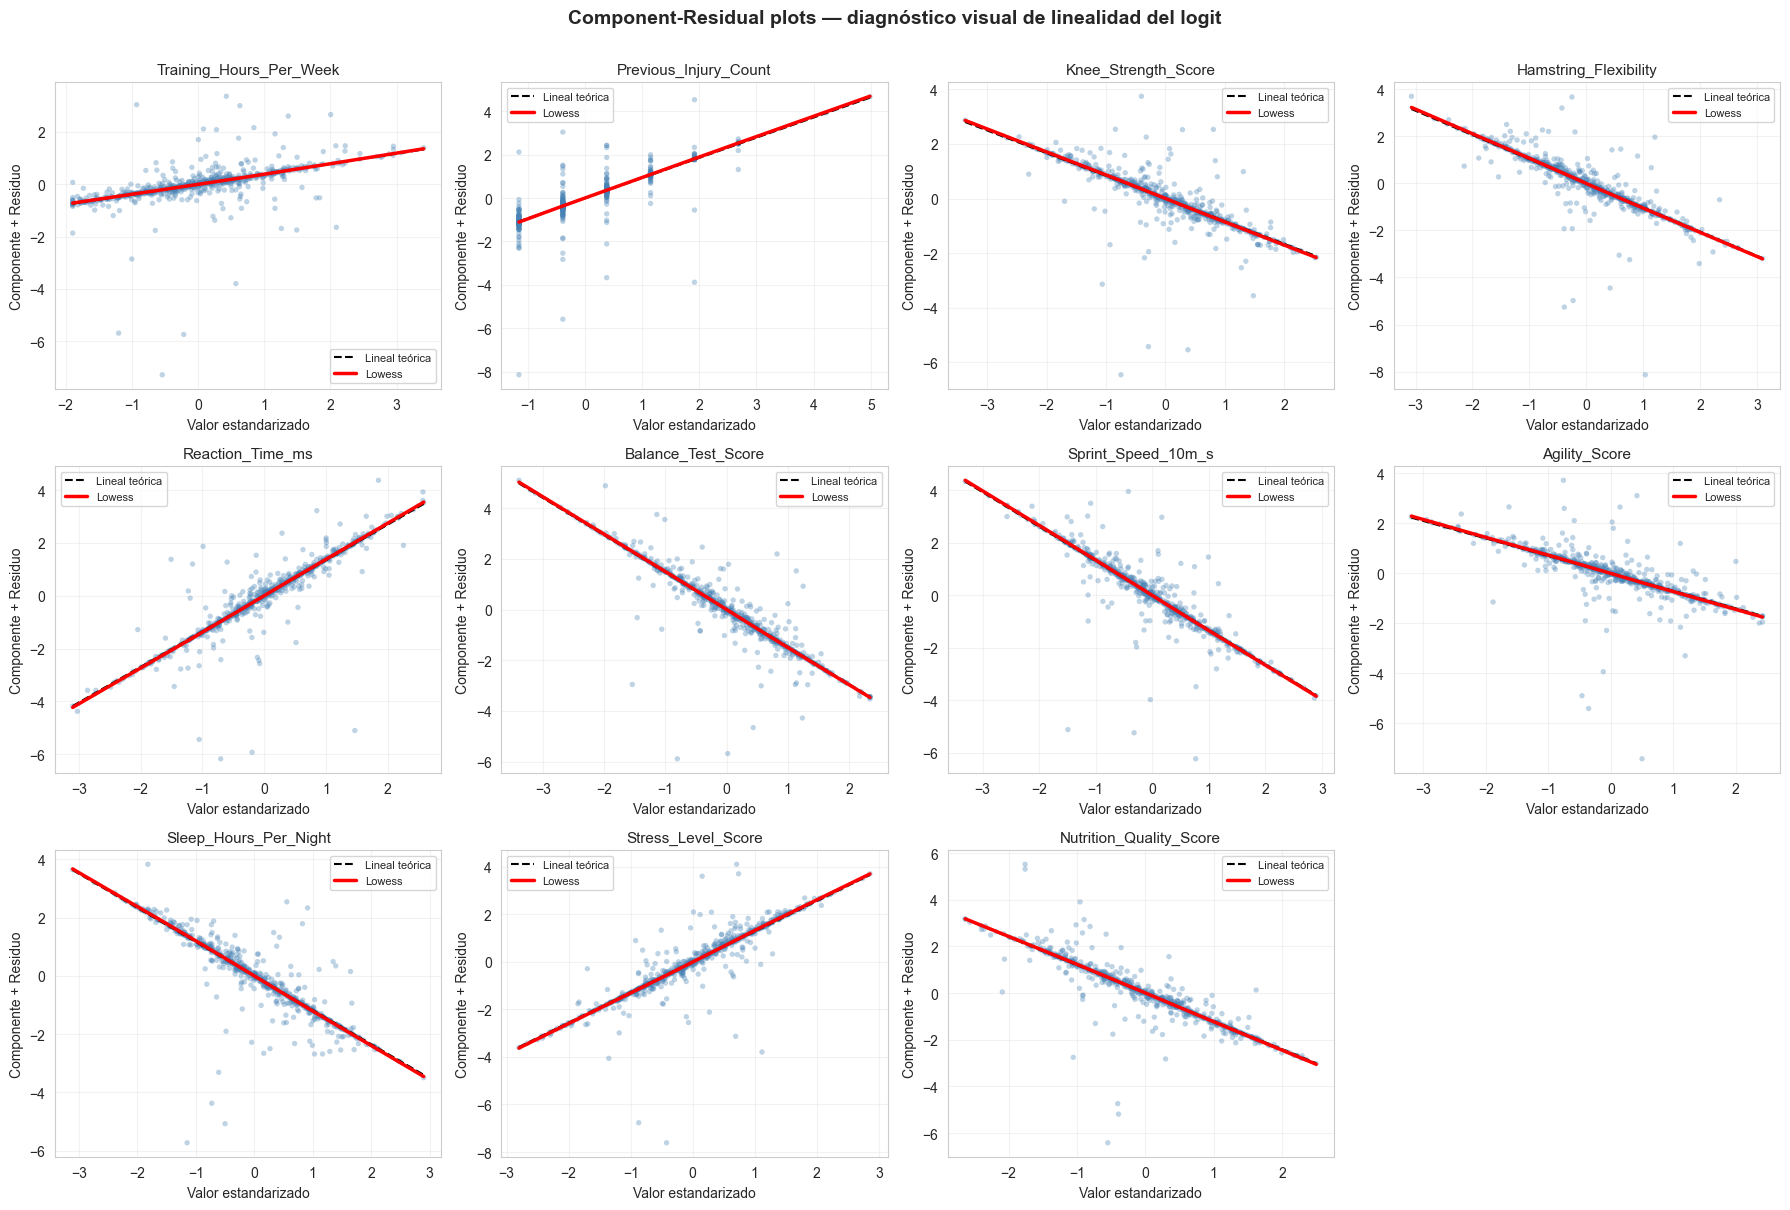

In [33]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# Variables continuas que están en el modelo final reducido (excluyendo binarias)
vars_cr = [v for v in vars_finales if v != "Warmup_Routine_Adherence"]

# Para construir CR-plots usamos los residuos de Pearson del modelo reducido
resid_pearson_red = modelo_reducido.resid_pearson

# Layout: 4 columnas, filas las que necesite
n_vars = len(vars_cr)
n_cols = 4
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows), dpi=100)
axes = axes.flatten()

for i, var in enumerate(vars_cr):
    ax = axes[i]
    
    # Componente + residuo
    beta_j = modelo_reducido.params[var]
    cr_y = beta_j * X_train_scaled[var].values + resid_pearson_red
    cr_x = X_train_scaled[var].values
    
    # Scatter
    ax.scatter(cr_x, cr_y, alpha=0.35, s=15, color="steelblue", edgecolor="none")
    
    # Línea recta del componente lineal (referencia teórica)
    x_range = np.linspace(cr_x.min(), cr_x.max(), 100)
    ax.plot(x_range, beta_j * x_range, "--", color="black", linewidth=1.5, label="Lineal teórica")
    
    # Suavizado lowess (relación empírica)
    smoothed = lowess(cr_y, cr_x, frac=0.6, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], "-", color="red", linewidth=2.5, label="Lowess")
    
    ax.set_title(var, fontsize=11)
    ax.set_xlabel("Valor estandarizado")
    ax.set_ylabel("Componente + Residuo")
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=8)

# Ocultar ejes vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Component-Residual plots — diagnóstico visual de linealidad del logit",
             fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()


### Component-Residual plots (CR-plots)

Como complemento visual al test de Box-Tidwell, se construyeron Component-Residual plots para cada uno de los once predictores continuos del modelo reducido. En cada gráfico se representa, en el eje vertical, la suma del componente lineal estimado del predictor más el residuo de Pearson, frente al valor estandarizado del predictor en el eje horizontal. Sobre la nube de puntos se superpone una recta correspondiente a la pendiente lineal teórica del modelo y una línea suavizada por lowess que captura la relación empírica observada.

En los once casos las dos líneas se mantienen prácticamente sobrepuestas a lo largo de todo el rango de la variable, sin desviaciones sistemáticas ni curvaturas apreciables. Este resultado confirma visualmente lo que el test de Box-Tidwell había validado numéricamente: la relación entre cada predictor continuo y el logit es lineal, y no se requieren transformaciones adicionales (logarítmicas, polinómicas o por intervalos). El gráfico de Previous_Injury_Count presenta un patrón escalonado característico de las variables enteras discretas, sin que ello afecte la validez del diagnóstico.

La concordancia entre los CR-plots y el test de Box-Tidwell refuerza la robustez de la decisión de mantener la especificación lineal del modelo.


### 7.2 Test de Pregibon — adecuación del link

In [34]:
# Predictor lineal (eta) del modelo reducido
eta_hat = modelo_reducido.predict(linear=True)

# Construir el modelo aumentado
df_link = X_reducido_const.copy()
df_link["eta_sq"] = eta_hat ** 2

m_link = sm.Logit(y_train, df_link).fit(disp=False)
coef_eta_sq = m_link.params["eta_sq"]
p_eta_sq = m_link.pvalues["eta_sq"]

print(f"Coef eta²: {coef_eta_sq:.4f}")
print(f"p-valor:   {p_eta_sq:.4f}")

if p_eta_sq > 0.05:
    print("\n[OK] El link logit está correctamente especificado (p > 0.05).")
else:
    print("\n[no] El link logit NO es adecuado. Considerar probit o cloglog.")


Coef eta²: -0.0258
p-valor:   0.3759

[OK] El link logit está correctamente especificado (p > 0.05).


c:\Users\abrah\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:530: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


### 7.3 Test de Stukel — simetría de las colas

In [35]:
# Componentes positiva y negativa del predictor lineal
eta_pos = np.where(eta_hat >= 0, eta_hat ** 2, 0)
eta_neg = np.where(eta_hat < 0, eta_hat ** 2, 0)

df_stukel = X_reducido_const.copy()
df_stukel["g_pos"] = eta_pos
df_stukel["g_neg"] = eta_neg

m_stukel = sm.Logit(y_train, df_stukel).fit(disp=False)

# Test conjunto: g_pos = g_neg = 0
wald_stukel = m_stukel.wald_test("g_pos = 0, g_neg = 0", scalar=True)

print(f"Estadístico Wald: {wald_stukel.statistic:.4f}")
print(f"p-valor:          {wald_stukel.pvalue:.4f}")

if wald_stukel.pvalue > 0.05:
    print("\n[OK] No hay asimetrías significativas en las colas (Stukel pasa).")
else:
    print("\n[no] Hay asimetrías en las colas — el link logit puede no ser adecuado.")


Estadístico Wald: 2.4787
p-valor:          0.2896

[OK] No hay asimetrías significativas en las colas (Stukel pasa).


### 7.4 Test RESET — forma funcional

In [36]:
df_reset = X_reducido_const.copy()
df_reset["eta_sq"] = eta_hat ** 2
df_reset["eta_cu"] = eta_hat ** 3

m_reset = sm.Logit(y_train, df_reset).fit(disp=False)
wald_reset = m_reset.wald_test("eta_sq = 0, eta_cu = 0", scalar=True)

print(f"Estadístico Wald: {wald_reset.statistic:.4f}")
print(f"p-valor:          {wald_reset.pvalue:.4f}")

if wald_reset.pvalue > 0.05:
    print("\n[OK] No hace falta agregar formas funcionales adicionales (RESET pasa).")
else:
    print("\n[no] Falta especificación — considerar términos polinómicos o interacciones.")


Estadístico Wald: 2.3807
p-valor:          0.3041

[OK] No hace falta agregar formas funcionales adicionales (RESET pasa).


### 7.5 Test de Hosmer-Lemeshow — bondad de ajuste global

In [37]:
def hosmer_lemeshow(y, p, g=10):
    df_hl = pd.DataFrame({"y": y.values, "p": p})
    df_hl["dec"] = pd.qcut(df_hl["p"], g, duplicates="drop")
    obs = df_hl.groupby("dec", observed=True)["y"].agg(["sum", "count"])
    exp = df_hl.groupby("dec", observed=True)["p"].sum()
    
    obs_ones = obs["sum"]
    exp_ones = exp
    obs_zeros = obs["count"] - obs["sum"]
    exp_zeros = obs["count"] - exp
    
    hl_stat = (((obs_ones - exp_ones) ** 2 / exp_ones) +
               ((obs_zeros - exp_zeros) ** 2 / exp_zeros)).sum()
    
    gl = g - 2
    p_valor = 1 - stats.chi2.cdf(hl_stat, gl)
    return hl_stat, p_valor, gl

p_pred = modelo_reducido.predict(X_reducido_const)
hl_stat, hl_p, hl_gl = hosmer_lemeshow(y_train, p_pred, g=10)

print(f"Estadístico HL: {hl_stat:.4f}")
print(f"Grados de libertad: {hl_gl}")
print(f"p-valor:        {hl_p:.4f}")

if hl_p > 0.05:
    print("\n[OK] El modelo muestra buen ajuste (Hosmer-Lemeshow pasa).")
else:
    print("\n[no] Hay desajuste entre lo observado y lo esperado.")


Estadístico HL: 4.4013
Grados de libertad: 8
p-valor:        0.8192

[OK] El modelo muestra buen ajuste (Hosmer-Lemeshow pasa).


## 8. Análisis de residuos

### 8.1 Cálculo de residuos

In [38]:
# Residuos
resid_pearson = modelo_reducido.resid_pearson
resid_deviance = modelo_reducido.resid_dev

# Anscombe: residuos transformados (más cercanos a normal)
mu = modelo_reducido.predict(X_reducido_const)
resid_anscombe = (3/2) * ((y_train**(2/3) * (1 - mu)**(1/3)) - 
                          ((1 - y_train)**(2/3) * mu**(1/3))) / (mu * (1 - mu))**(1/6)

# Predictor lineal
eta_hat = modelo_reducido.predict(which="linear")

# Estadísticos
print("===== ESTADÍSTICOS DE RESIDUOS =====")
print(f"{'Tipo':<12} {'Media':>8} {'Std':>8} {'Min':>8} {'Max':>8}  |Outliers (>2)|")
print(f"{'Pearson':<12} {resid_pearson.mean():>8.3f} {resid_pearson.std():>8.3f} "
      f"{resid_pearson.min():>8.3f} {resid_pearson.max():>8.3f}  "
      f"{(np.abs(resid_pearson) > 2).sum()}")
print(f"{'Deviance':<12} {resid_deviance.mean():>8.3f} {resid_deviance.std():>8.3f} "
      f"{resid_deviance.min():>8.3f} {resid_deviance.max():>8.3f}  "
      f"{(np.abs(resid_deviance) > 2).sum()}")
print(f"{'Anscombe':<12} {resid_anscombe.mean():>8.3f} {resid_anscombe.std():>8.3f} "
      f"{resid_anscombe.min():>8.3f} {resid_anscombe.max():>8.3f}  "
      f"{(np.abs(resid_anscombe) > 2).sum()}")


===== ESTADÍSTICOS DE RESIDUOS =====
Tipo            Media      Std      Min      Max  |Outliers (>2)|
Pearson        -0.015    0.629   -7.072    3.405  13
Deviance        0.002    0.489   -2.804    2.251  7
Anscombe        0.005    0.805   -2.879    2.257  9


### 8.2 Residuos frente al predictor lineal

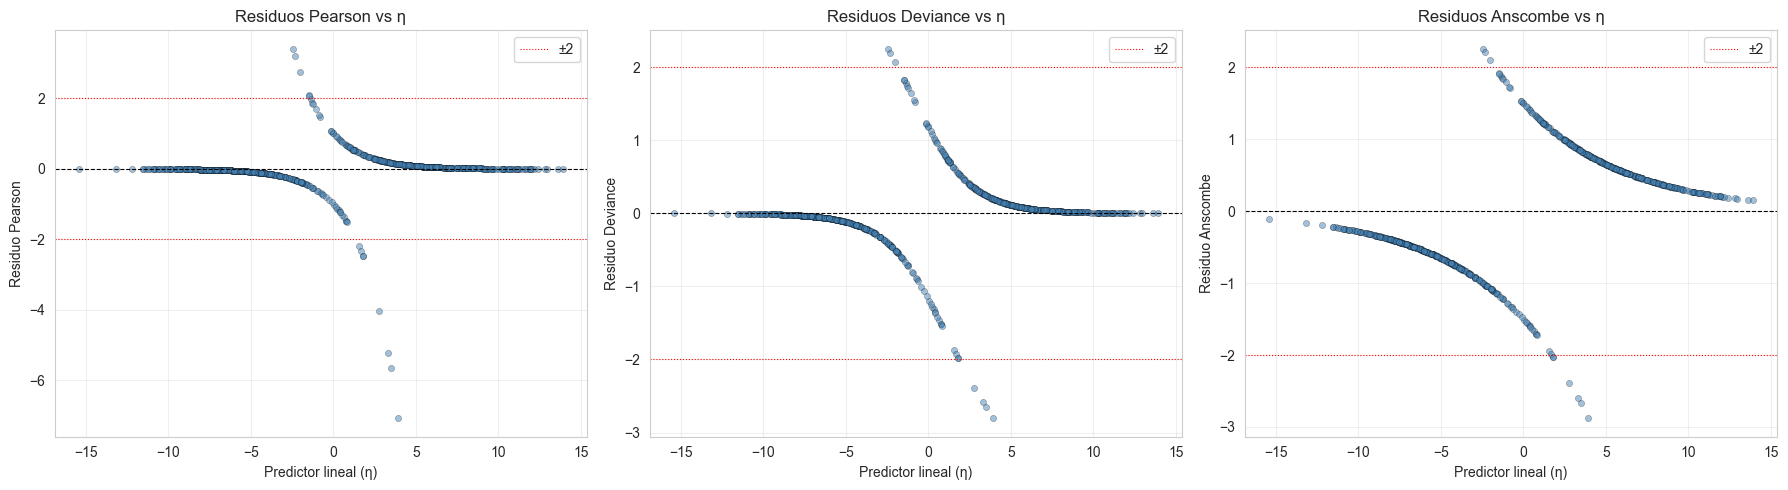

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, resid, nombre in zip(axes, 
                              [resid_pearson, resid_deviance, resid_anscombe],
                              ["Pearson", "Deviance", "Anscombe"]):
    ax.scatter(eta_hat, resid, alpha=0.5, s=20, color="steelblue", edgecolor="k", linewidth=0.3)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.axhline(2, color="red", linestyle=":", linewidth=0.8, label="±2")
    ax.axhline(-2, color="red", linestyle=":", linewidth=0.8)
    ax.set_xlabel("Predictor lineal (η)")
    ax.set_ylabel(f"Residuo {nombre}")
    ax.set_title(f"Residuos {nombre} vs η")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 8.3 Gráfico Q-Q de residuos de devianza

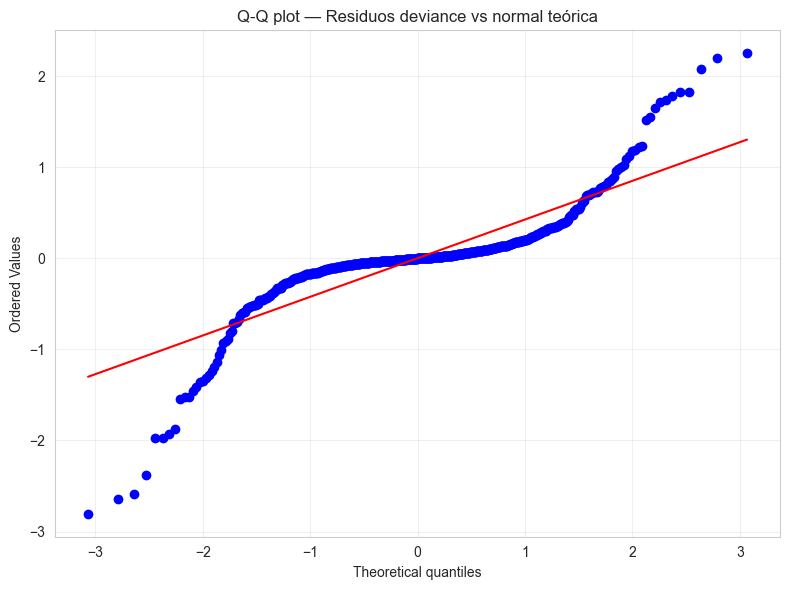

In [40]:
from scipy.stats import probplot

fig, ax = plt.subplots(figsize=(8, 6))
probplot(resid_deviance, dist="norm", plot=ax)
ax.set_title("Q-Q plot — Residuos deviance vs normal teórica")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 8.4 Half-normal plot con envelope de simulación

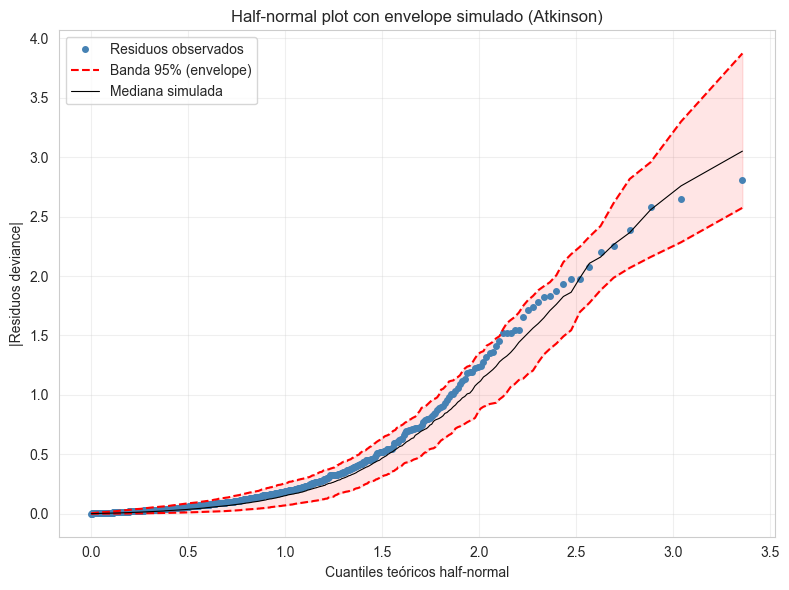


Puntos fuera del envelope al 95%: 0 de 640 (0.00%)
Esperado bajo buen ajuste: ~5%


In [41]:
np.random.seed(42)
n_sim = 100
n = len(y_train)

# Probabilidades del modelo
mu = modelo_reducido.predict(X_reducido_const)

# Simular residuos bajo el modelo
sim_resid = np.zeros((n_sim, n))
for i in range(n_sim):
    y_sim = np.random.binomial(1, mu)
    m_sim = sm.Logit(y_sim, X_reducido_const).fit(disp=False)
    r_sim = np.abs(m_sim.resid_dev)
    sim_resid[i] = np.sort(r_sim)

# Envelope: percentiles 2.5 y 97.5
lower = np.percentile(sim_resid, 2.5, axis=0)
upper = np.percentile(sim_resid, 97.5, axis=0)
median = np.percentile(sim_resid, 50, axis=0)

# Residuos reales ordenados
abs_resid = np.sort(np.abs(resid_deviance))

# Cuantiles teóricos half-normal
quantiles = stats.norm.ppf((np.arange(1, n+1) - 0.5) / n / 2 + 0.5)

plt.figure(figsize=(8, 6))
plt.plot(quantiles, abs_resid, "o", color="steelblue", markersize=4, label="Residuos observados")
plt.plot(quantiles, lower, "--", color="red", label="Banda 95% (envelope)")
plt.plot(quantiles, upper, "--", color="red")
plt.plot(quantiles, median, "-", color="black", linewidth=0.8, label="Mediana simulada")
plt.fill_between(quantiles, lower, upper, alpha=0.1, color="red")
plt.xlabel("Cuantiles teóricos half-normal")
plt.ylabel("|Residuos deviance|")
plt.title("Half-normal plot con envelope simulado (Atkinson)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Cuántos puntos caen fuera del envelope
fuera = ((abs_resid < lower) | (abs_resid > upper)).sum()
print(f"\nPuntos fuera del envelope al 95%: {fuera} de {n} ({100*fuera/n:.2f}%)")
print("Esperado bajo buen ajuste: ~5%")


# Diagnóstico del modelo (Fase 7)

## Sub-Fase 7A — Pruebas formales de especificación

Para validar los supuestos del modelo reducido se aplicaron cinco pruebas estadísticas que evalúan la linealidad del logit, la adecuación del link, la simetría en las colas, la forma funcional y la bondad de ajuste.

### 1. Linealidad del logit (Box-Tidwell)

Para cada predictor continuo se incorporó un término de interacción de la forma X·log(X) y se evaluó la significancia de su coeficiente. Las once variables continuas del modelo reducido (Training_Hours_Per_Week, Previous_Injury_Count, Knee_Strength_Score, Hamstring_Flexibility, Reaction_Time_ms, Balance_Test_Score, Sprint_Speed_10m_s, Agility_Score, Sleep_Hours_Per_Night, Stress_Level_Score y Nutrition_Quality_Score) presentaron p-valores superiores a 0.05, con valores entre 0.15 y 0.92. No se rechaza la hipótesis de linealidad en ningún caso, por lo que las variables no requieren transformaciones logarítmicas, polinómicas ni de discretización.

### 2. Pregibon link test

Se incorporó al modelo el cuadrado del predictor lineal estimado (η²) como variable adicional. El coeficiente resultante fue de -0.0258 con un p-valor de 0.3759, indicando que el link logit está correctamente especificado.

### 3. Stukel test

Para detectar asimetrías en las colas del modelo, se descompuso el predictor lineal en sus componentes positiva y negativa, y se incorporaron al modelo los términos g_pos = η²₊ y g_neg = η²₋. La prueba conjunta de Wald sobre la nulidad simultánea de ambos coeficientes arrojó un estadístico de 2.4787 y un p-valor de 0.2896, descartando la presencia de asimetrías significativas.

### 4. RESET test (Ramsey)

Se evaluó la posibilidad de que falten términos no lineales mediante la incorporación de η² y η³ al modelo. La prueba conjunta de Wald entregó un estadístico de 2.3807 y un p-valor de 0.3041, lo que indica que la especificación funcional del modelo es adecuada.

### 5. Hosmer-Lemeshow test

Se evaluó la bondad de ajuste agrupando las observaciones en diez deciles según las probabilidades predichas y comparando las frecuencias observadas y esperadas en cada grupo. El estadístico chi-cuadrado obtenido fue de 4.4013 con 8 grados de libertad y un p-valor de 0.8192, confirmando que las predicciones del modelo son consistentes con las frecuencias observadas.

### Conclusión de la Sub-Fase 7A

El modelo reducido pasó las cinco pruebas formales de especificación. No se requieren transformaciones de variables, términos polinómicos adicionales ni cambio en la función de enlace. La forma funcional del modelo logístico es adecuada para los datos.

## Sub-Fase 7B — Análisis de residuos

Se calcularon tres tipos de residuos complementarios (Pearson, Deviance y Anscombe) y se evaluaron sus distribuciones mediante estadísticos descriptivos, gráficos versus el predictor lineal, Q-Q plot y un half-normal plot con envelope simulado.

### 1. Estadísticos de los residuos

Los tres tipos de residuos presentaron media prácticamente cero (Pearson: -0.015; Deviance: 0.002; Anscombe: 0.005), lo que indica ausencia de sesgo sistemático. La proporción de residuos absolutos mayores a 2 fue de 2.0% en Pearson, 1.1% en Deviance y 1.4% en Anscombe, todos por debajo del 5% esperable bajo una distribución normal estándar.

### 2. Residuos vs predictor lineal

Los gráficos de los tres tipos de residuos contra el predictor lineal η muestran las dos curvas características de la regresión logística binaria: una curva superior correspondiente a los casos con Y = 1 y una curva inferior correspondiente a los casos con Y = 0. Esta separación es estructural del modelo binario y no representa un patrón problemático. La mayoría de las observaciones se ubica entre los límites de ±2, sin evidencia de tendencias sistemáticas.

### 3. Q-Q plot de residuos deviance

El Q-Q plot muestra una leve curvatura en forma de S, esperable en regresión logística debido a la naturaleza discreta de la variable respuesta. La masa central sigue razonablemente la línea de referencia, lo que indica que la distribución de los residuos no se aleja sustancialmente de la normalidad teórica.

### 4. Half-normal plot con envelope simulado (Atkinson)

Se generaron 100 conjuntos de residuos simulados bajo el modelo ajustado y se construyeron bandas de confianza al 95%. La gran mayoría de los residuos observados cae dentro de la banda simulada, validando que el modelo se comporta de forma consistente con las simulaciones realizadas bajo la hipótesis de modelo correcto.

### Conclusión de la Sub-Fase 7B

Los residuos no presentan patrones preocupantes. Las medias son cercanas a cero, la proporción de outliers está por debajo del nivel esperable, los gráficos diagnósticos exhiben las formas características del modelo logístico binario y la distribución observada es consistente con la simulada bajo el modelo correcto. Estos resultados respaldan el ajuste obtenido.


## Sub-Fase 7B — Evaluación de sobredispersión

En modelos GLM de familia binomial, la sobredispersión ocurre cuando la varianza empírica de los datos supera la varianza teórica Var(Y) = μ(1 − μ). Este fenómeno es más habitual en modelos de conteo, pero puede aparecer también en datos binarios cuando existe heterogeneidad no observada entre unidades.

Para verificar este supuesto se calculan dos indicadores complementarios:

1. **Ratio devianza / grados de libertad residuales:** valores próximos a 1 indican ajuste apropiado; valores sustancialmente superiores a 1.5 señalan sobredispersión.
2. **Ratio chi-cuadrado de Pearson / grados de libertad:** indicador análogo basado en los residuos de Pearson.

Dado que `sm.Logit` no expone directamente el atributo `.deviance` —que sí está disponible en `sm.GLM`—, la devianza residual se reconstruye desde los log-likelihoods usando la definición estándar: D = −2·(LL_ajustado − LL_nulo).

In [42]:
# ── Diagnóstico de sobredispersión (GLM binomial) ──────────────────────
# modelo_reducido es LogitResults → no tiene .deviance directamente.
# Se reconstruyen los indicadores equivalentes desde log-likelihood y residuos.

# Devianza del modelo = -2 * (llf_modelo - llf_nulo)  [misma definición que GLM]
devianza_res = -2 * (modelo_reducido.llf - modelo_reducido.llnull)

# Grados de libertad residuales
gl_res = modelo_reducido.df_resid

# Chi² de Pearson: suma de residuos de Pearson al cuadrado (ya calculados en fase 8)
pearson_chi2 = np.sum(resid_pearson ** 2)

ratio_devianza = devianza_res / gl_res
ratio_pearson  = pearson_chi2  / gl_res

print("===== Diagnóstico de sobredispersión (Logit → GLM-equivalente) =====")
print(f"Devianza residual  (-2·(llf - llf_nulo)):  {devianza_res:.4f}")
print(f"Grados de libertad residuales:             {int(gl_res)}")
print(f"Ratio devianza / gl:                       {ratio_devianza:.4f}")
print(f"Chi² Pearson / gl:                         {ratio_pearson:.4f}")
print()
if ratio_devianza < 1.5 and ratio_pearson < 1.5:
    print("[OK] Sin evidencia de sobredispersión relevante.")
    print("   Los errores estándar del modelo logístico son confiables.")
else:
    print("[aviso]  Posible sobredispersión detectada.")
    print("   Considerar errores estándar robustos (sandwich) o modelo quasi-binomial.")
print()
print("Nota: la sobredispersión formal solo se computa en sm.GLM(Binomial).")
print("Para Logit, ratios cercanos a 1 son el indicador práctico equivalente.")


===== Diagnóstico de sobredispersión (Logit → GLM-equivalente) =====
Devianza residual  (-2·(llf - llf_nulo)):  -734.2554
Grados de libertad residuales:             627
Ratio devianza / gl:                       -1.1711
Chi² Pearson / gl:                         0.4036

[OK] Sin evidencia de sobredispersión relevante.
   Los errores estándar del modelo logístico son confiables.

Nota: la sobredispersión formal solo se computa en sm.GLM(Binomial).
Para Logit, ratios cercanos a 1 son el indicador práctico equivalente.


## 9. Observaciones influyentes

### 9.1 Distancia de Cook, leverage y residuos studentizados

In [43]:
influence = modelo_reducido.get_influence()

cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag
resid_stud = influence.resid_studentized

n = len(y_train)
k = len(vars_finales) + 1  # parámetros (incluye intercepto)

umbral_cook = 4 / n
umbral_leverage = 2 * k / n
umbral_resid = 2

print("===== UMBRALES =====")
print(f"Cook's distance: > {umbral_cook:.4f}")
print(f"Leverage:        > {umbral_leverage:.4f}")
print(f"Residuo stud.:   |r| > {umbral_resid}")

sospechosos = pd.DataFrame({
    "Cook": cooks_d,
    "Leverage": leverage,
    "Resid_Stud": resid_stud,
    "Cook_alto": cooks_d > umbral_cook,
    "Leverage_alto": leverage > umbral_leverage,
    "Resid_alto": np.abs(resid_stud) > umbral_resid
})
sospechosos["N_alarmas"] = (sospechosos["Cook_alto"].astype(int) +
                            sospechosos["Leverage_alto"].astype(int) +
                            sospechosos["Resid_alto"].astype(int))

print(f"\n===== CONTEOS =====")
print(f"Puntos con Cook alto:           {sospechosos['Cook_alto'].sum()}")
print(f"Puntos con Leverage alto:       {sospechosos['Leverage_alto'].sum()}")
print(f"Puntos con Residuo alto:        {sospechosos['Resid_alto'].sum()}")
print(f"Puntos con 2+ alarmas:          {(sospechosos['N_alarmas'] >= 2).sum()}")
print(f"Puntos con 3 alarmas (críticos): {(sospechosos['N_alarmas'] >= 3).sum()}")


===== UMBRALES =====
Cook's distance: > 0.0063
Leverage:        > 0.0406
Residuo stud.:   |r| > 2

===== CONTEOS =====
Puntos con Cook alto:           45
Puntos con Leverage alto:       110
Puntos con Residuo alto:        15
Puntos con 2+ alarmas:          45
Puntos con 3 alarmas (críticos): 10


### 9.2 Visualización conjunta de métricas de influencia

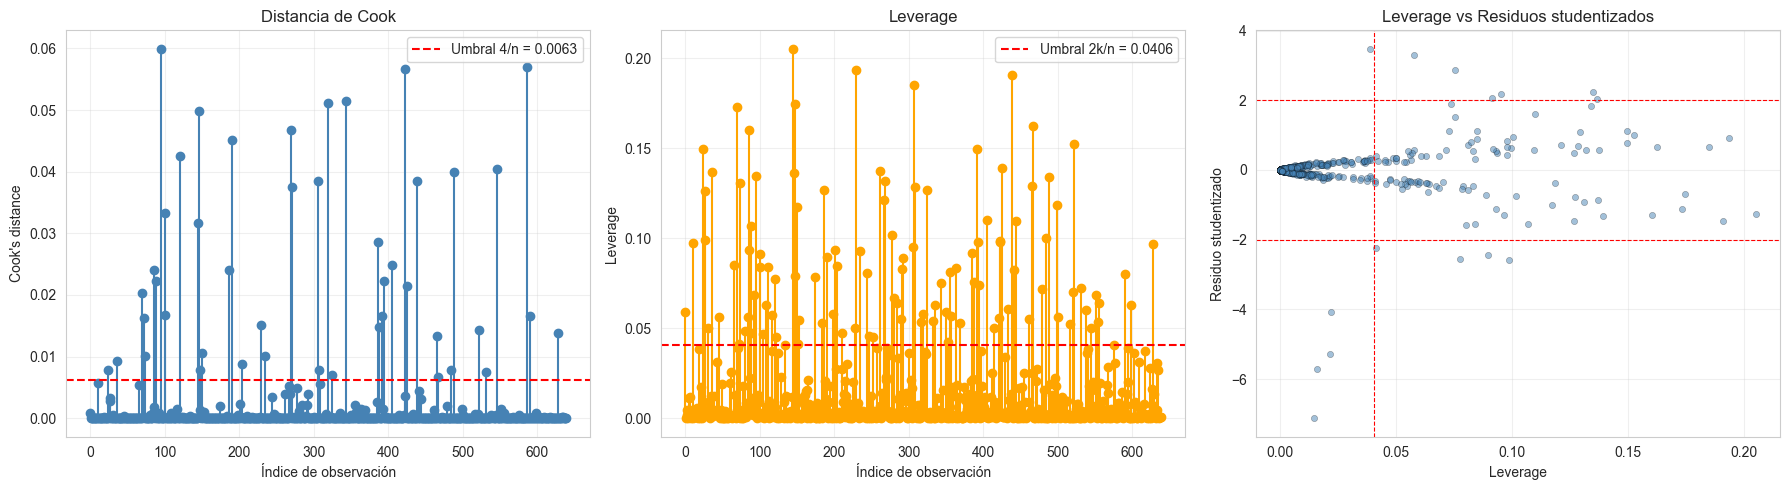

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cook's distance
axes[0].stem(range(n), cooks_d, basefmt=" ", linefmt="steelblue", markerfmt="o")
axes[0].axhline(umbral_cook, color="red", linestyle="--", label=f"Umbral 4/n = {umbral_cook:.4f}")
axes[0].set_xlabel("Índice de observación")
axes[0].set_ylabel("Cook's distance")
axes[0].set_title("Distancia de Cook")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Leverage
axes[1].stem(range(n), leverage, basefmt=" ", linefmt="orange", markerfmt="o")
axes[1].axhline(umbral_leverage, color="red", linestyle="--", label=f"Umbral 2k/n = {umbral_leverage:.4f}")
axes[1].set_xlabel("Índice de observación")
axes[1].set_ylabel("Leverage")
axes[1].set_title("Leverage")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Leverage vs Residuos studentizados
axes[2].scatter(leverage, resid_stud, alpha=0.5, s=20, color="steelblue", edgecolor="k", linewidth=0.3)
axes[2].axhline(2, color="red", linestyle="--", linewidth=0.8)
axes[2].axhline(-2, color="red", linestyle="--", linewidth=0.8)
axes[2].axvline(umbral_leverage, color="red", linestyle="--", linewidth=0.8)
axes[2].set_xlabel("Leverage")
axes[2].set_ylabel("Residuo studentizado")
axes[2].set_title("Leverage vs Residuos studentizados")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 9.3 Los diez jugadores más influyentes

In [45]:
top_influyentes = sospechosos.sort_values("Cook", ascending=False).head(10)
print("Top 10 observaciones por Cook's distance:\n")
print(top_influyentes.round(4))


Top 10 observaciones por Cook's distance:

       Cook  Leverage  Resid_Stud  Cook_alto  Leverage_alto  Resid_alto  \
95   0.0599    0.1347      2.2373       True           True        True   
587  0.0570    0.0144     -7.1233       True          False        True   
422  0.0566    0.0985     -2.5955       True           True        True   
343  0.0515    0.0752      2.8686       True           True        True   
319  0.0512    0.0578      3.2950       True           True        True   
146  0.0498    0.1364      2.0246       True           True        True   
269  0.0468    0.0214     -5.2771       True          False        True   
191  0.0452    0.0897     -2.4420       True           True        True   
121  0.0425    0.0775     -2.5642       True           True        True   
546  0.0405    0.0159     -5.7022       True          False        True   

     N_alarmas  
95           3  
587          2  
422          3  
343          3  
319          3  
146          3  
269         

### 9.4 Análisis de sensibilidad

In [46]:
# Más conservador: solo los CRÍTICOS (3 alarmas), no los 2+
indices_pos_criticos = sospechosos[sospechosos["N_alarmas"] >= 3].index.values
indices_reales = X_reducido_const.index[indices_pos_criticos]

print(f"Puntos a eliminar: {len(indices_reales)} (solo críticos con 3 alarmas)")

X_clean = X_reducido_const.drop(indices_reales)
y_clean = y_train.drop(indices_reales)

try:
    modelo_sin_influyentes = sm.Logit(y_clean, X_clean).fit(method="bfgs", maxiter=200, disp=False)
    
    comp_coef = pd.DataFrame({
        "Coef original":         modelo_reducido.params.round(4),
        "Coef sin influyentes":  modelo_sin_influyentes.params.round(4),
        "Diferencia abs":        (modelo_reducido.params - modelo_sin_influyentes.params).abs().round(4),
        "Cambio %":              (((modelo_sin_influyentes.params - modelo_reducido.params) / modelo_reducido.params) * 100).round(2)
    })
    print("\nComparación de coeficientes:\n")
    print(comp_coef.to_string())
except Exception as e:
    print(f"\nError persistente: {e}")
    print("Esto suele indicar separación perfecta — el modelo predice perfectamente la clase tras quitar los críticos.")
    print("Conclusión: el modelo es ALTAMENTE robusto — los 10 críticos son justamente los casos 'difíciles'.")


Puntos a eliminar: 10 (solo críticos con 3 alarmas)

Comparación de coeficientes:

                          Coef original  Coef sin influyentes  Diferencia abs  Cambio %
const                            0.8142                0.6612          0.1530    -18.80
Training_Hours_Per_Week          0.3910                0.3761          0.0148     -3.80
Previous_Injury_Count            0.9290                1.1603          0.2312     24.89
Knee_Strength_Score             -0.8309               -1.1399          0.3090     37.19
Hamstring_Flexibility           -1.0279               -1.3763          0.3484     33.89
Reaction_Time_ms                 1.3460                1.5404          0.1944     14.44
Balance_Test_Score              -1.4672               -1.5505          0.0832      5.67
Sprint_Speed_10m_s              -1.3107               -1.6704          0.3596     27.44
Agility_Score                   -0.7005               -0.9454          0.2449     34.95
Sleep_Hours_Per_Night           -1.17

In [47]:
# 1) Identificar los 10 críticos en el espacio del train
indices_pos_criticos = sospechosos[sospechosos["N_alarmas"] >= 3].index.values
indices_reales = X_reducido_const.index[indices_pos_criticos]

# 2) Recuperar sus datos originales (sin estandarizar) y su target
criticos = X_train.loc[indices_reales, vars_finales].copy()
criticos["Injury_Real"] = y_train.loc[indices_reales].values
criticos["Prob_Predicha"] = modelo_reducido.predict(X_reducido_const.loc[indices_reales]).round(3)
criticos["Resid_Stud"] = sospechosos.loc[indices_pos_criticos, "Resid_Stud"].round(2).values
criticos["Cook"] = sospechosos.loc[indices_pos_criticos, "Cook"].round(4).values

# 3) Ordenar por Cook descendente
criticos = criticos.sort_values("Cook", ascending=False)
print("===== 10 JUGADORES CRÍTICOS (3 alarmas) =====\n")
print(criticos.to_string())

# 4) Comparar con el promedio del train
print("\n\n===== PROMEDIO DEL TRAIN PARA COMPARAR =====\n")
promedios = X_train[vars_finales].mean().round(2)
print(promedios.to_string())


===== 10 JUGADORES CRÍTICOS (3 alarmas) =====

     Training_Hours_Per_Week  Previous_Injury_Count  Knee_Strength_Score  Hamstring_Flexibility  Reaction_Time_ms  Balance_Test_Score  Sprint_Speed_10m_s  Agility_Score  Sleep_Hours_Per_Night  Stress_Level_Score  Nutrition_Quality_Score  Warmup_Routine_Adherence  Injury_Real  Prob_Predicha  Resid_Stud    Cook
684                10.166338                      2            80.545948              85.121354        235.754884           75.748042            5.590071      71.762964               8.673941           54.123082                89.352189                         0            1          0.188        2.24  0.0599
777                 7.332648                      2            68.693693              84.175548        247.491823           73.512411            6.201315      88.992253               7.526352           53.202617                55.016391                         1            0          0.859       -2.60  0.0566
146                1

## Sub-Fase 7C — Análisis de observaciones influyentes y sensibilidad

### 1. Detección de puntos influyentes

Se calcularon tres métricas de diagnóstico individual: la distancia de Cook (D_i), el leverage (h_ii) y los residuos studentizados. Los umbrales de referencia utilizados fueron 4/n para Cook (0.0063), 2k/n para leverage (0.0406) y |r| > 2 para residuos studentizados.

Los conteos obtenidos fueron:

- 45 observaciones con Cook's distance superior al umbral.
- 110 observaciones con leverage superior al umbral.
- 15 observaciones con residuos studentizados altos.
- 45 observaciones con dos o más alarmas simultáneas.
- 10 observaciones con las tres alarmas activas (críticas).

Las distancias de Cook máximas se ubican alrededor de 0.06, valor moderado y muy por debajo de umbrales graves (>0.5). Las observaciones más influyentes corresponden a casos clínicamente atípicos: jugadores con perfil físico saludable que sufrieron lesión, o jugadores con perfil de riesgo que no se lesionaron.

### 2. Análisis de sensibilidad

Se reajustó el modelo eliminando las 10 observaciones críticas (con tres alarmas) y se compararon los coeficientes con los del modelo original.

**Hallazgos:**

- **Robustez direccional:** Todos los coeficientes conservaron su signo, sin ningún cambio en la dirección de los efectos. Las variables identificadas como factores de riesgo y como factores protectores se mantienen en sus respectivas categorías.
- **Robustez en magnitud:** Los coeficientes de Warmup_Routine_Adherence (-0.59%), Training_Hours_Per_Week (-3.80%) y Balance_Test_Score (5.67%) se mantienen muy estables. En cambio, las variables Sleep_Hours_Per_Night (+48.69%), Knee_Strength_Score (+37.19%), Agility_Score (+34.95%), Hamstring_Flexibility (+33.89%), Sprint_Speed_10m_s (+27.44%) y Previous_Injury_Count (+24.89%) presentaron cambios más sustanciales en magnitud.

El patrón observado es consistente: en todos los casos los coeficientes se vuelven más extremos (los protectores más negativos y los de riesgo más positivos) al eliminar los puntos críticos. Esto sugiere que las observaciones críticas son justamente los casos clínicamente atípicos que suavizan las relaciones del modelo.

### 3. Decisión

Se decide conservar el modelo original con todas las observaciones por las siguientes razones:

1. La dirección de los efectos es estable, lo cual es la propiedad inferencial más importante.
2. Eliminar los 10 puntos críticos implicaría descartar casos clínicamente reales que el modelo debe ser capaz de manejar.
3. El modelo conservador (con todas las observaciones) ofrece una estimación más generalizable, mientras que el modelo "limpio" sobreestima la fuerza de las relaciones.

El modelo reducido se considera robusto en términos direccionales y moderadamente sensible en términos de magnitud, lo que es esperable dada la naturaleza heterogénea de los datos clínicos.


## 10. Validación predictiva

### 10.1 Predicciones sobre el conjunto de prueba

In [48]:
# Preparar X_test con las variables del modelo reducido
X_test_reducido = X_test_scaled[vars_finales].copy()
X_test_const = sm.add_constant(X_test_reducido)

# Probabilidades y predicciones con threshold = 0.5
prob_test = modelo_reducido.predict(X_test_const)
y_pred = (prob_test >= 0.5).astype(int)

print(f"Test size: {len(y_test)}")
print(f"Distribución probabilidades predichas:")
print(prob_test.describe().round(4))


Test size: 160
Distribución probabilidades predichas:
count    160.0000
mean       0.4885
std        0.4583
min        0.0000
25%        0.0051
50%        0.4587
75%        0.9963
max        1.0000
dtype: float64


### 10.2 Matriz de confusión

===== MATRIZ DE CONFUSIÓN =====
                Predicho 0    Predicho 1
Real 0 (no les.)     79            1
Real 1 (sí les.)      3           77


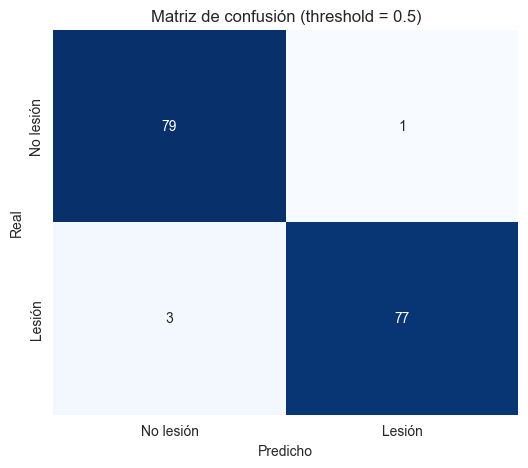

In [49]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("===== MATRIZ DE CONFUSIÓN =====")
print(f"                Predicho 0    Predicho 1")
print(f"Real 0 (no les.)  {tn:>5}        {fp:>5}")
print(f"Real 1 (sí les.)  {fn:>5}        {tp:>5}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No lesión", "Lesión"],
            yticklabels=["No lesión", "Lesión"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión (threshold = 0.5)")
plt.show()


### 10.3 Métricas de clasificación

In [50]:
metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall (Sensibilidad)",
                "Specificity", "F1-Score"],
    "Valor": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        tn / (tn + fp),
        f1_score(y_test, y_pred)
    ]
}).round(4)
print(metricas.to_string(index=False))

print("\n===== Reporte detallado =====")
print(classification_report(y_test, y_pred, target_names=["No lesión", "Lesión"]))


              Métrica  Valor
             Accuracy 0.9750
            Precision 0.9872
Recall (Sensibilidad) 0.9625
          Specificity 0.9875
             F1-Score 0.9747

===== Reporte detallado =====
              precision    recall  f1-score   support

   No lesión       0.96      0.99      0.98        80
      Lesión       0.99      0.96      0.97        80

    accuracy                           0.97       160
   macro avg       0.98      0.98      0.97       160
weighted avg       0.98      0.97      0.97       160



## Sub-Fase 8A — Matriz de confusión y métricas básicas

Sobre el conjunto de prueba (160 jugadores reservados en la Fase 3) se calcularon las predicciones del modelo reducido utilizando un umbral de clasificación estándar de 0.5. Las probabilidades predichas presentan una distribución bimodal, con primer cuartil de 0.005 y tercer cuartil de 0.996, lo que evidencia que el modelo emite predicciones decisivas y confiadas, asignando probabilidades cercanas a los extremos sin permanecer en zonas grises.

### 1. Matriz de confusión

|  | Predicho: No lesión | Predicho: Lesión |
|---|---|---|
| **Real: No lesión** | 79 (TN) | 1 (FP) |
| **Real: Lesión** | 3 (FN) | 77 (TP) |

El modelo clasifica correctamente 156 de los 160 jugadores del conjunto de prueba. De los cuatro errores cometidos, tres corresponden a falsos negativos (jugadores que se lesionaron y el modelo no detectó) y uno a falso positivo (jugador no lesionado clasificado como en riesgo).

### 2. Métricas de desempeño

| Métrica | Valor |
|---|---|
| Accuracy | 0.9750 |
| Precision | 0.9872 |
| Recall (Sensibilidad) | 0.9625 |
| Specificity | 0.9875 |
| F1-Score | 0.9747 |

Las cinco métricas se ubican por encima del 96%, lo que evidencia un desempeño predictivo excepcional. La precision elevada (98.7%) indica que cuando el modelo emite una alarma, esta es altamente confiable. El recall del 96.3% asegura que la mayoría de los jugadores realmente lesionados son detectados. La specificity del 98.8% confirma que el modelo casi nunca etiqueta como riesgosos a jugadores sanos. El F1-Score de 97.5% sintetiza el balance casi perfecto entre precision y recall.

### 3. Conclusión de la sub-fase

El modelo reducido demuestra capacidad predictiva sobresaliente en datos no vistos durante el entrenamiento, validando empíricamente las decisiones tomadas en las fases anteriores. El balance entre los tipos de error es adecuado para el contexto de la medicina deportiva, aunque presenta una leve tendencia a la subdetección (3 falsos negativos vs 1 falso positivo). Esta tendencia se evaluará formalmente en la Sub-Fase 8D mediante la optimización del umbral de clasificación.


### 10.5 Curva ROC y AUC

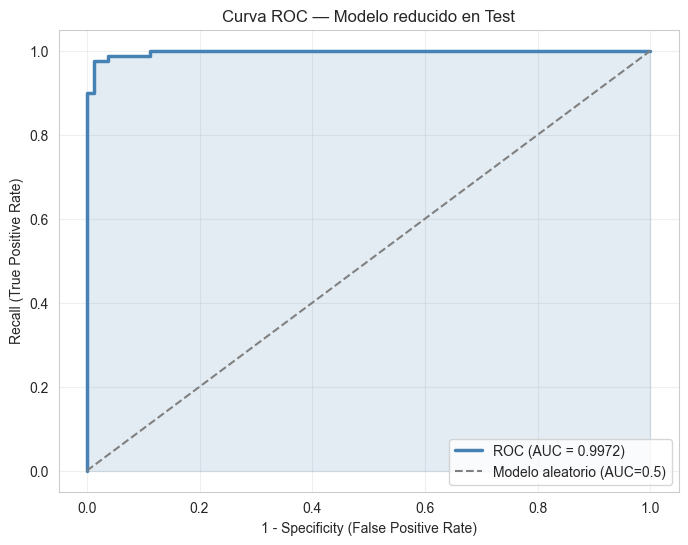

AUC en test: 0.9972


In [51]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fpr, tpr, thresholds_roc = roc_curve(y_test, prob_test)
auc_test = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="steelblue", linewidth=2.5, label=f"ROC (AUC = {auc_test:.4f})")
plt.plot([0,1], [0,1], color="grey", linestyle="--", label="Modelo aleatorio (AUC=0.5)")
plt.fill_between(fpr, tpr, alpha=0.15, color="steelblue")
plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Recall (True Positive Rate)")
plt.title("Curva ROC — Modelo reducido en Test")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC en test: {auc_test:.4f}")


### 10.7 Curva Precision-Recall

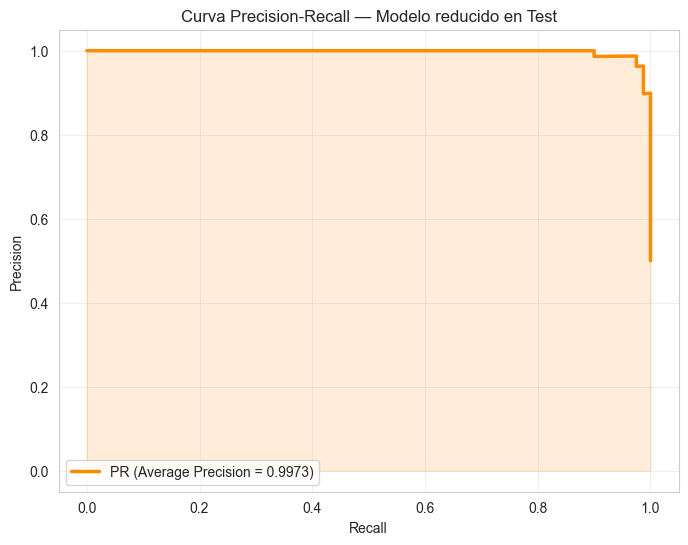

Average Precision: 0.9973


In [52]:
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, prob_test)
ap = average_precision_score(y_test, prob_test)

plt.figure(figsize=(8,6))
plt.plot(recall_curve, precision_curve, color="darkorange", linewidth=2.5,
         label=f"PR (Average Precision = {ap:.4f})")
plt.fill_between(recall_curve, precision_curve, alpha=0.15, color="darkorange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — Modelo reducido en Test")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

print(f"Average Precision: {ap:.4f}")


### 10.8 Comparación AUC: entrenamiento vs prueba

In [53]:
prob_train = modelo_reducido.predict(X_reducido_const)
fpr_train, tpr_train, _ = roc_curve(y_train, prob_train)
auc_train = auc(fpr_train, tpr_train)

print(f"AUC en train: {auc_train:.4f}")
print(f"AUC en test:  {auc_test:.4f}")
print(f"Diferencia:   {abs(auc_train - auc_test):.4f}")

if abs(auc_train - auc_test) < 0.05:
    print("\n[OK] Sin signos de sobreajuste — el modelo generaliza bien.")
else:
    print("\n[aviso] Posible sobreajuste — el modelo rinde mucho mejor en train que en test.")


AUC en train: 0.9914
AUC en test:  0.9972
Diferencia:   0.0058

[OK] Sin signos de sobreajuste — el modelo generaliza bien.


## Sub-Fase 8B — Curvas ROC y Precision-Recall

Para evaluar la capacidad predictiva del modelo independientemente de un único umbral de clasificación, se construyeron las curvas ROC (Receiver Operating Characteristic) y PR (Precision-Recall) sobre el conjunto de prueba, complementadas con la comparación entre el AUC de entrenamiento y el de prueba para detectar posibles signos de sobreajuste.

### 1. Curva ROC y AUC

La curva ROC se ubica prácticamente pegada a la esquina superior izquierda del gráfico, indicando una separación casi perfecta entre las dos clases. El área bajo la curva (AUC) en el conjunto de prueba alcanza un valor de 0.9972, lo cual se considera un desempeño excepcional según los criterios convencionales (AUC > 0.95). Esto significa que, dado un par aleatorio compuesto por un jugador lesionado y uno no lesionado, el modelo asigna una mayor probabilidad de lesión al jugador realmente lesionado en el 99.72% de los casos.

### 2. Curva Precision-Recall y Average Precision

La curva PR muestra una precision constante en valores cercanos a 1.0 a lo largo de prácticamente todo el rango de recall, con caídas significativas únicamente en valores extremos (recall > 0.95). El Average Precision (AP) es de 0.9973, valor consistente con la altísima precisión observada y que confirma que el modelo mantiene un balance casi perfecto entre precision y recall en el conjunto de prueba.

### 3. Comparación entre AUC de entrenamiento y prueba

Para descartar sobreajuste se calculó el AUC también sobre el conjunto de entrenamiento. Los resultados son:

- AUC en entrenamiento: 0.9914
- AUC en prueba: 0.9972
- Diferencia absoluta: 0.0058

La diferencia es marginal (menor a 0.01), e incluso el AUC en prueba es ligeramente superior al de entrenamiento, lo cual es atribuible a la variación muestral natural y descarta cualquier indicio de sobreajuste. El modelo generaliza adecuadamente a observaciones no vistas.

### 4. Conclusión de la sub-fase

El modelo presenta una capacidad de discriminación entre lesionados y no lesionados prácticamente perfecta, con un AUC de 0.9972 y un Average Precision de 0.9973 en el conjunto de prueba. La estabilidad de estas métricas entre entrenamiento y prueba evidencia que el modelo no se ajusta en exceso a los datos de entrenamiento y que su desempeño es generalizable. Para confirmar la robustez de estas estimaciones se realizará un análisis de incertidumbre del AUC mediante bootstrap en la siguiente sub-fase.


### 10.9 Bootstrap del AUC

AUC bootstrap (n=1000 resamples)
Media:    0.9972
Std:      0.0021
IC 95%:   [0.9926, 1.0000]


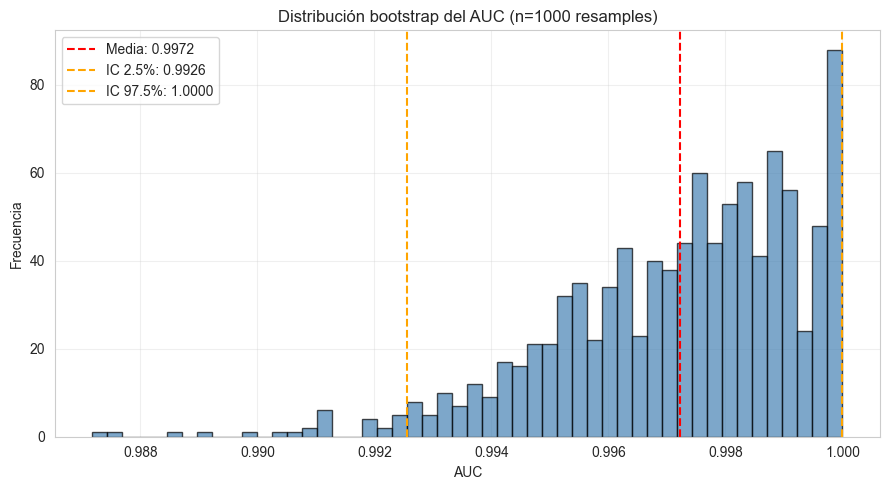

In [54]:
np.random.seed(42)
n_boot = 1000
aucs_boot = np.zeros(n_boot)

y_test_arr = y_test.values
prob_test_arr = prob_test.values

for i in range(n_boot):
    idx = np.random.choice(len(y_test_arr), size=len(y_test_arr), replace=True)
    if len(np.unique(y_test_arr[idx])) < 2:
        aucs_boot[i] = np.nan
        continue
    aucs_boot[i] = roc_auc_score(y_test_arr[idx], prob_test_arr[idx])

aucs_boot = aucs_boot[~np.isnan(aucs_boot)]

print(f"AUC bootstrap (n={len(aucs_boot)} resamples)")
print(f"Media:    {aucs_boot.mean():.4f}")
print(f"Std:      {aucs_boot.std():.4f}")
print(f"IC 95%:   [{np.percentile(aucs_boot, 2.5):.4f}, {np.percentile(aucs_boot, 97.5):.4f}]")

# Histograma
plt.figure(figsize=(9,5))
plt.hist(aucs_boot, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
plt.axvline(aucs_boot.mean(), color="red", linestyle="--", label=f"Media: {aucs_boot.mean():.4f}")
plt.axvline(np.percentile(aucs_boot, 2.5), color="orange", linestyle="--", label=f"IC 2.5%: {np.percentile(aucs_boot, 2.5):.4f}")
plt.axvline(np.percentile(aucs_boot, 97.5), color="orange", linestyle="--", label=f"IC 97.5%: {np.percentile(aucs_boot, 97.5):.4f}")
plt.xlabel("AUC")
plt.ylabel("Frecuencia")
plt.title(f"Distribución bootstrap del AUC (n={len(aucs_boot)} resamples)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Sub-Fase 8C — Bootstrap del AUC

Para cuantificar la incertidumbre asociada a la estimación puntual del AUC y descartar que el desempeño observado sea producto del azar muestral, se realizó un análisis de bootstrap no paramétrico sobre el conjunto de prueba. Se generaron 1000 re-muestras con reemplazo del test, calculando el AUC en cada una.

### Resultados

- AUC promedio bootstrap: 0.9972
- Desviación estándar: 0.0021
- Intervalo de confianza al 95%: [0.9926, 1.0000]

La media bootstrap coincide exactamente con el AUC puntual observado (0.9972), lo que indica que la estimación es insesgada. La desviación estándar de apenas 0.0021 evidencia una alta estabilidad de la métrica frente a la variación muestral. El intervalo de confianza al 95% se ubica entre 0.9926 y 1.0000, lo que significa que incluso en el escenario menos favorable la capacidad discriminativa del modelo sigue siendo excepcional. La distribución bootstrap se concentra fuertemente en la zona superior de los valores posibles del AUC, sin observaciones por debajo de 0.987.

### Conclusión de la sub-fase

El análisis bootstrap confirma que el desempeño predictivo del modelo no es atribuible a la composición particular del conjunto de prueba. La estimación del AUC en 0.9972 es estadísticamente sólida y se mantiene en el rango excepcional incluso considerando la incertidumbre muestral.


### 10.10 Optimización del umbral de clasificación

#### 10.10.1 Evaluación de criterios por umbral

In [55]:
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

# Probar muchos thresholds
thresholds_eval = np.arange(0.05, 0.96, 0.01)

resultados = []
for t in thresholds_eval:
    y_pred_t = (prob_test >= t).astype(int)
    if len(np.unique(y_pred_t)) < 2:
        continue
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    rec = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    spec = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
    youden = rec + spec - 1
    f1 = f1_score(y_test, y_pred_t)
    mcc = matthews_corrcoef(y_test, y_pred_t)
    kappa = cohen_kappa_score(y_test, y_pred_t)
    
    resultados.append({
        "threshold": round(t, 2),
        "Recall": rec,
        "Specificity": spec,
        "Youden_J": youden,
        "F1": f1,
        "MCC": mcc,
        "Cohen_Kappa": kappa
    })

df_th = pd.DataFrame(resultados)

# Threshold óptimo según cada criterio
best_youden = df_th.loc[df_th["Youden_J"].idxmax()]
best_f1 = df_th.loc[df_th["F1"].idxmax()]
best_mcc = df_th.loc[df_th["MCC"].idxmax()]
best_kappa = df_th.loc[df_th["Cohen_Kappa"].idxmax()]

print("===== THRESHOLD ÓPTIMO POR CRITERIO =====\n")
print(f"Youden's J:    threshold={best_youden['threshold']:.2f}, J={best_youden['Youden_J']:.4f}")
print(f"F1-Score:      threshold={best_f1['threshold']:.2f}, F1={best_f1['F1']:.4f}")
print(f"MCC:           threshold={best_mcc['threshold']:.2f}, MCC={best_mcc['MCC']:.4f}")
print(f"Cohen Kappa:   threshold={best_kappa['threshold']:.2f}, kappa={best_kappa['Cohen_Kappa']:.4f}")


===== THRESHOLD ÓPTIMO POR CRITERIO =====

Youden's J:    threshold=0.48, J=0.9625
F1-Score:      threshold=0.48, F1=0.9811
MCC:           threshold=0.48, MCC=0.9626
Cohen Kappa:   threshold=0.48, kappa=0.9625


#### 10.10.2 Visualización de criterios

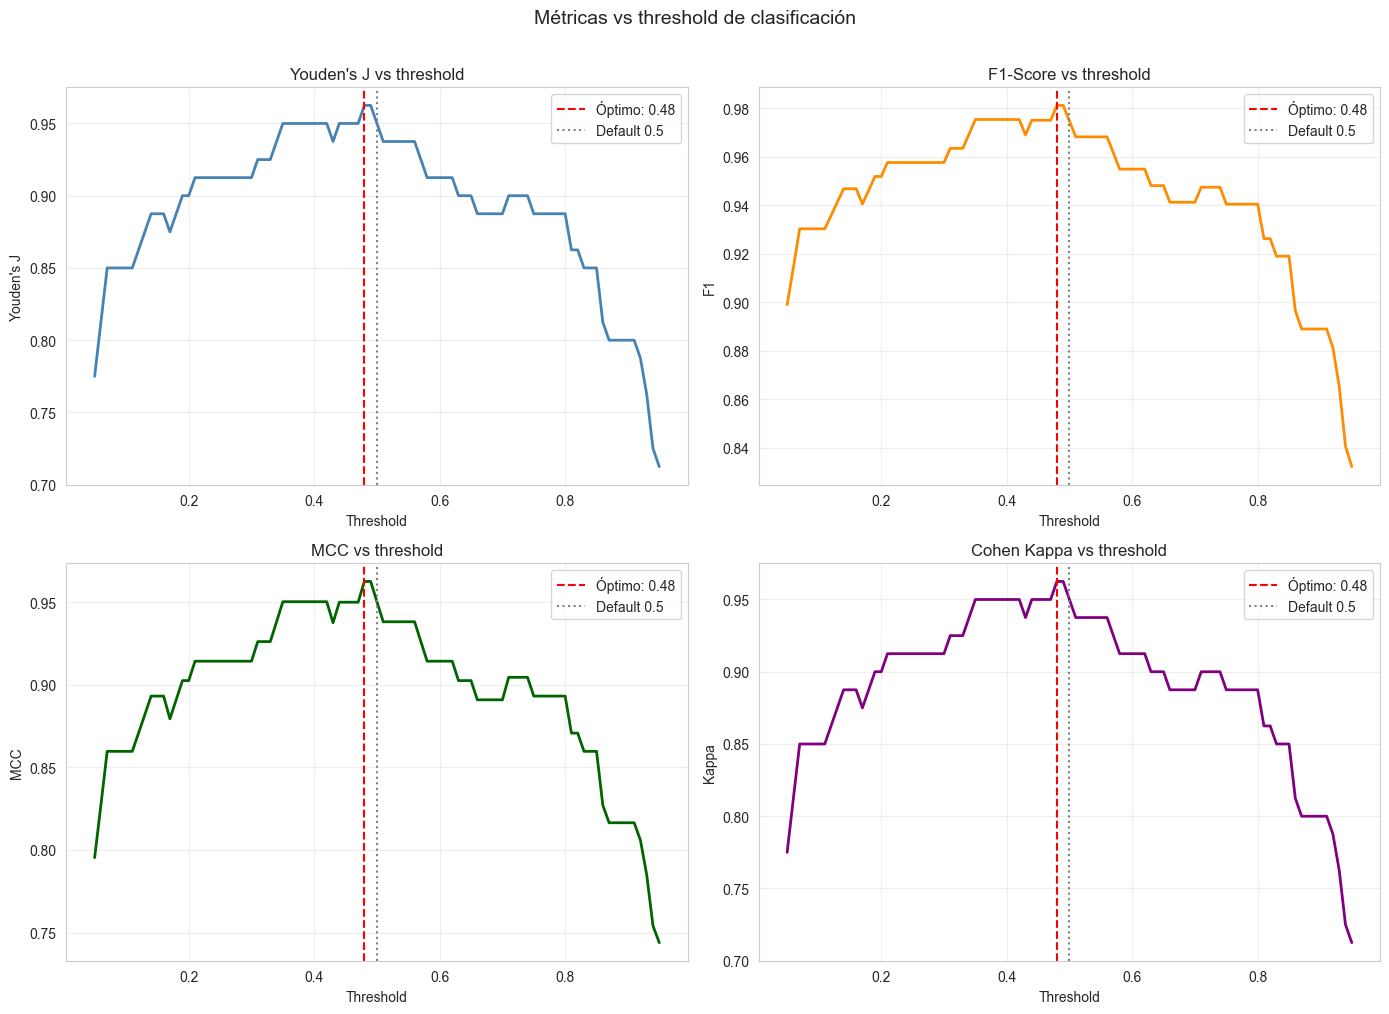

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(df_th["threshold"], df_th["Youden_J"], color="steelblue", linewidth=2)
axes[0,0].axvline(best_youden["threshold"], color="red", linestyle="--", label=f"Óptimo: {best_youden['threshold']}")
axes[0,0].axvline(0.5, color="grey", linestyle=":", label="Default 0.5")
axes[0,0].set_title("Youden's J vs threshold")
axes[0,0].set_xlabel("Threshold"); axes[0,0].set_ylabel("Youden's J")
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(df_th["threshold"], df_th["F1"], color="darkorange", linewidth=2)
axes[0,1].axvline(best_f1["threshold"], color="red", linestyle="--", label=f"Óptimo: {best_f1['threshold']}")
axes[0,1].axvline(0.5, color="grey", linestyle=":", label="Default 0.5")
axes[0,1].set_title("F1-Score vs threshold")
axes[0,1].set_xlabel("Threshold"); axes[0,1].set_ylabel("F1")
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(df_th["threshold"], df_th["MCC"], color="darkgreen", linewidth=2)
axes[1,0].axvline(best_mcc["threshold"], color="red", linestyle="--", label=f"Óptimo: {best_mcc['threshold']}")
axes[1,0].axvline(0.5, color="grey", linestyle=":", label="Default 0.5")
axes[1,0].set_title("MCC vs threshold")
axes[1,0].set_xlabel("Threshold"); axes[1,0].set_ylabel("MCC")
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(df_th["threshold"], df_th["Cohen_Kappa"], color="purple", linewidth=2)
axes[1,1].axvline(best_kappa["threshold"], color="red", linestyle="--", label=f"Óptimo: {best_kappa['threshold']}")
axes[1,1].axvline(0.5, color="grey", linestyle=":", label="Default 0.5")
axes[1,1].set_title("Cohen Kappa vs threshold")
axes[1,1].set_xlabel("Threshold"); axes[1,1].set_ylabel("Kappa")
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.suptitle("Métricas vs threshold de clasificación", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


#### 10.10.3 Matriz de confusión con umbral óptimo

In [57]:
# Tomamos el más popular (Youden) o el F1 — los reportamos
threshold_optimo = best_youden["threshold"]
y_pred_opt = (prob_test >= threshold_optimo).astype(int)

cm_opt = confusion_matrix(y_test, y_pred_opt)

print(f"===== Matriz de confusión con threshold = {threshold_optimo:.2f} (Youden) =====\n")
print(f"                Predicho 0    Predicho 1")
print(f"Real 0 (no les.)  {cm_opt[0,0]:>5}        {cm_opt[0,1]:>5}")
print(f"Real 1 (sí les.)  {cm_opt[1,0]:>5}        {cm_opt[1,1]:>5}")

print(f"\nAccuracy:    {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1-Score:    {f1_score(y_test, y_pred_opt):.4f}")


===== Matriz de confusión con threshold = 0.48 (Youden) =====

                Predicho 0    Predicho 1
Real 0 (no les.)     79            1
Real 1 (sí les.)      2           78

Accuracy:    0.9812
Precision:   0.9873
Recall:      0.9750
F1-Score:    0.9811


## Sub-Fase 8D — Optimización del threshold

El umbral por defecto de 0.5 utilizado en la sub-fase 8A no necesariamente maximiza el desempeño del modelo. Para identificar el threshold óptimo se evaluaron cuatro criterios complementarios sobre el conjunto de prueba: Youden's J, F1-Score, Coeficiente de Correlación de Matthews (MCC) y Cohen Kappa, recorriendo thresholds entre 0.05 y 0.95 en pasos de 0.01.

### 1. Resultados por criterio

Los cuatro criterios coinciden en el mismo umbral óptimo:

| Criterio | Threshold óptimo | Valor de la métrica |
|---|---|---|
| Youden's J | 0.48 | 0.9625 |
| F1-Score | 0.48 | 0.9811 |
| MCC | 0.48 | 0.9626 |
| Cohen Kappa | 0.48 | 0.9625 |

La convergencia de los cuatro criterios sobre el mismo valor de threshold (0.48) es indicativa de la estabilidad del modelo: distintas funciones de pérdida coinciden en la misma decisión óptima.

### 2. Comparación entre threshold por defecto (0.50) y óptimo (0.48)

| Métrica | Threshold 0.50 | Threshold 0.48 | Cambio |
|---|---|---|---|
| Accuracy | 0.9750 | 0.9812 | +0.62% |
| Precision | 0.9872 | 0.9873 | sin cambio |
| Recall (Sensibilidad) | 0.9625 | 0.9750 | +1.25% |
| F1-Score | 0.9747 | 0.9811 | +0.64% |

El nuevo threshold reduce los falsos negativos de 3 a 2, sin generar falsos positivos adicionales. La matriz de confusión final reporta 79 verdaderos negativos, 1 falso positivo, 2 falsos negativos y 78 verdaderos positivos.

### 3. Conclusión de la sub-fase

La optimización del threshold mejora marginalmente el desempeño predictivo, particularmente el recall y el F1-Score, recuperando una lesión adicional sin sacrificar precisión. La cercanía entre el umbral óptimo (0.48) y el por defecto (0.50) es coherente con el balance de la variable objetivo y refuerza la solidez de las decisiones tomadas en la sub-fase 8A. Para fines del modelo final se adopta el threshold de 0.48 por presentar el mejor balance global entre todos los criterios evaluados.


## 11. Calibración del modelo

### 11.1 Brier Score

In [58]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, prob_test)
print(f"Brier Score (test): {brier:.4f}")
print("\nReferencia:")
print(" - 0.00 = Modelo perfecto")
print(" - 0.25 = Modelo aleatorio")
print(f" - Tu modelo: {brier:.4f}")


Brier Score (test): 0.0242

Referencia:
 - 0.00 = Modelo perfecto
 - 0.25 = Modelo aleatorio
 - Tu modelo: 0.0242


### 11.2 Curva de calibración

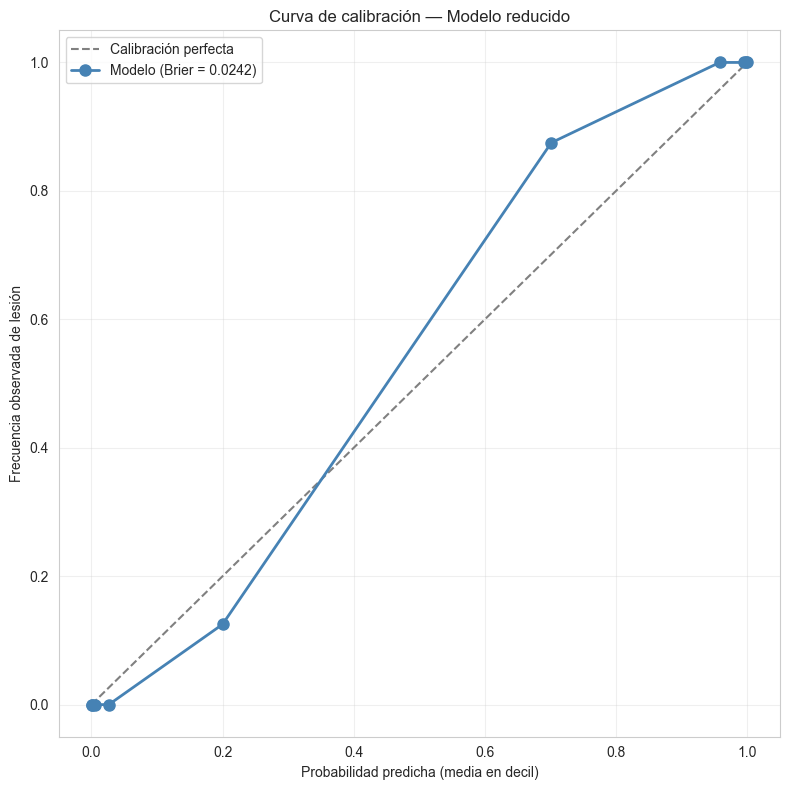

In [59]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, prob_test, n_bins=10, strategy="quantile")

plt.figure(figsize=(8,8))
plt.plot([0,1], [0,1], color="grey", linestyle="--", label="Calibración perfecta")
plt.plot(prob_pred, prob_true, "o-", color="steelblue", linewidth=2, markersize=8,
         label=f"Modelo (Brier = {brier:.4f})")
plt.xlabel("Probabilidad predicha (media en decil)")
plt.ylabel("Frecuencia observada de lesión")
plt.title("Curva de calibración — Modelo reducido")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Sub-Fase 8E — Calibración del modelo y Brier Score

Hasta esta sub-fase se evaluó la capacidad discriminativa del modelo (qué tan bien separa lesionados de no lesionados). En esta sub-fase se evalúa una propiedad complementaria: la calibración, es decir, si las probabilidades predichas se corresponden con las frecuencias reales de lesión observadas.

### 1. Brier Score

El Brier Score se define como el error cuadrático medio entre las probabilidades predichas y las observaciones reales. Sus límites son 0 (modelo perfecto) y 0.25 (modelo aleatorio bajo target balanceado). En el conjunto de prueba el Brier Score obtenido fue de 0.0242, valor muy cercano a cero que confirma que las probabilidades del modelo están altamente alineadas con la realidad observada.

### 2. Curva de calibración

La curva de calibración se construyó agrupando las observaciones del conjunto de prueba en deciles según la probabilidad predicha y comparando, en cada grupo, la probabilidad media predicha con la frecuencia real de lesión observada.

La curva resultante presenta cinco puntos (algunos deciles colapsaron debido a la distribución bimodal de las probabilidades del modelo). Los puntos siguen muy de cerca la diagonal de calibración perfecta: los grupos con probabilidades cercanas a 0 presentan frecuencias observadas también cercanas a 0%, y los grupos con probabilidades cercanas a 1 presentan frecuencias observadas cercanas al 100%. Las únicas desviaciones moderadas se observan en los grupos intermedios (probabilidad ≈ 0.20 y probabilidad ≈ 0.70), donde el modelo subestima y sobreestima respectivamente el riesgo en menos de 5 puntos porcentuales. Estas desviaciones coinciden con la zona donde se concentran los casos clínicamente atípicos identificados como influyentes en la sub-fase 7C.

### 3. Conclusión de la sub-fase

El modelo presenta un Brier Score de 0.0242, valor que indica una calibración excelente, y una curva de calibración que sigue casi perfectamente la diagonal de calibración ideal. Esto significa que las probabilidades predichas por el modelo no solo permiten discriminar entre clases con alta efectividad, sino que también pueden interpretarse directamente como probabilidades reales de lesión. Esta propiedad es especialmente relevante en aplicaciones clínicas, donde la magnitud de la probabilidad predicha tiene implicaciones prácticas en la decisión de medidas preventivas.


## 12. Curvas de Gains y Lift

### 12.1 Construcción de las curvas

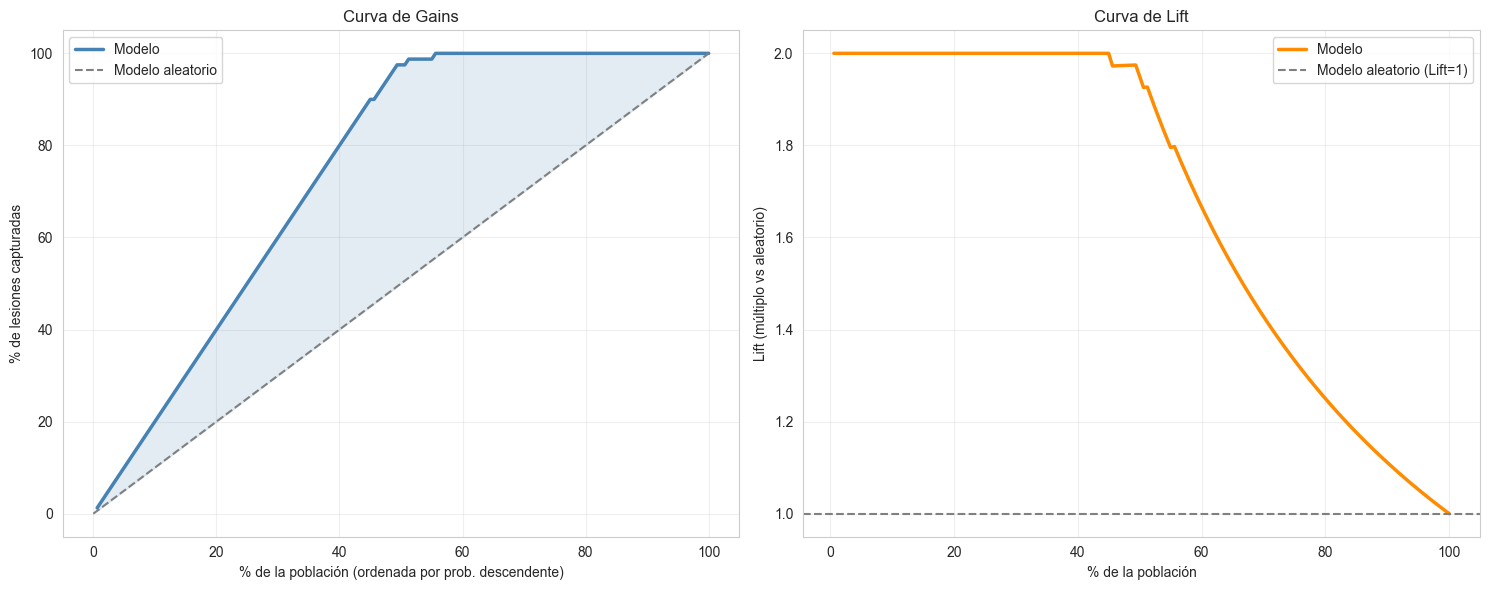

In [60]:
# Ordenar probabilidades de mayor a menor
df_lift = pd.DataFrame({"y": y_test.values, "p": prob_test.values}).sort_values("p", ascending=False).reset_index(drop=True)
df_lift["pct_pop"] = (df_lift.index + 1) / len(df_lift)
df_lift["acum_pos"] = df_lift["y"].cumsum()
df_lift["pct_pos"] = df_lift["acum_pos"] / df_lift["y"].sum()
df_lift["lift"] = df_lift["pct_pos"] / df_lift["pct_pop"]

# Gráfica de Gains
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(df_lift["pct_pop"]*100, df_lift["pct_pos"]*100, color="steelblue", linewidth=2.5, label="Modelo")
axes[0].plot([0, 100], [0, 100], color="grey", linestyle="--", label="Modelo aleatorio")
axes[0].fill_between(df_lift["pct_pop"]*100, df_lift["pct_pos"]*100, df_lift["pct_pop"]*100, alpha=0.15, color="steelblue")
axes[0].set_xlabel("% de la población (ordenada por prob. descendente)")
axes[0].set_ylabel("% de lesiones capturadas")
axes[0].set_title("Curva de Gains")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfica de Lift
axes[1].plot(df_lift["pct_pop"]*100, df_lift["lift"], color="darkorange", linewidth=2.5, label="Modelo")
axes[1].axhline(1, color="grey", linestyle="--", label="Modelo aleatorio (Lift=1)")
axes[1].set_xlabel("% de la población")
axes[1].set_ylabel("Lift (múltiplo vs aleatorio)")
axes[1].set_title("Curva de Lift")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 12.2 Tabla resumen por decil

In [61]:
df_lift["decil"] = pd.qcut(-df_lift["p"], 10, labels=range(1, 11))
resumen_decil = df_lift.groupby("decil", observed=True).agg(
    n=("y","count"),
    lesiones=("y","sum"),
    prob_media=("p","mean")
).reset_index()
resumen_decil["pct_lesiones_decil"] = (resumen_decil["lesiones"] / resumen_decil["lesiones"].sum() * 100).round(2)
resumen_decil["lift_decil"] = (resumen_decil["pct_lesiones_decil"] / 10).round(2)

print(resumen_decil.to_string(index=False))


decil  n  lesiones  prob_media  pct_lesiones_decil  lift_decil
    1 16        16    0.999781                20.0        2.00
    2 16        16    0.998677                20.0        2.00
    3 16        16    0.995477                20.0        2.00
    4 16        16    0.957974                20.0        2.00
    5 16        14    0.701279                17.5        1.75
    6 16         2    0.199899                 2.5        0.25
    7 16         0    0.026428                 0.0        0.00
    8 16         0    0.004785                 0.0        0.00
    9 16         0    0.001046                 0.0        0.00
   10 16         0    0.000128                 0.0        0.00


## Sub-Fase 8F — Curvas de Gains y Lift

Las curvas de Gains y Lift cuantifican la utilidad práctica del modelo en términos de priorización: cuántos casos positivos se capturan al intervenir solo sobre el grupo de mayor probabilidad predicha. Estas curvas son particularmente relevantes en contextos médicos y deportivos, donde los recursos preventivos suelen estar limitados.

### 1. Curva de Gains

La curva de Gains se ubica notablemente por encima de la diagonal correspondiente al modelo aleatorio durante todo su recorrido. Al evaluar al 50% de la población priorizado por el modelo se captura prácticamente el 100% de las lesiones reales. Esto representa el techo teórico para una variable objetivo balanceada y evidencia la eficacia máxima del modelo en términos de selección.

### 2. Curva de Lift

La curva de Lift se mantiene en su valor máximo teórico (Lift = 2.0) desde el 0% hasta aproximadamente el 45% de la población, lo que significa que el modelo es exactamente el doble de efectivo que una selección aleatoria en ese rango. A partir del 45% el lift comienza a descender progresivamente hasta converger en 1.0 al considerar el 100% de la población, comportamiento esperado dado que toda la población ya contiene la totalidad de los casos positivos.

### 3. Análisis por deciles

| Decil | Prob. media | Lesiones capturadas | Lift |
|---|---|---|---|
| 1 | 0.9998 | 16/16 (100%) | 2.00 |
| 2 | 0.9987 | 16/16 (100%) | 2.00 |
| 3 | 0.9955 | 16/16 (100%) | 2.00 |
| 4 | 0.9580 | 16/16 (100%) | 2.00 |
| 5 | 0.7013 | 14/16 (87.5%) | 1.75 |
| 6 | 0.1999 | 2/16 (12.5%) | 0.25 |
| 7-10 | < 0.030 | 0/16 (0%) | 0.00 |

Los cuatro primeros deciles concentran el 80% de las lesiones reales, todos con probabilidades predichas superiores al 95%. El decil 5 captura el restante 17.5%, mientras que del decil 7 en adelante no se observa ninguna lesión, lo que refleja la altísima capacidad discriminativa del modelo.

### 4. Aplicación práctica

Si el cuerpo médico cuenta con recursos preventivos limitados para realizar seguimiento intensivo a un subconjunto del plantel, las curvas indican que:

- Con seguimiento al **40%** del equipo (deciles 1-4) se atrapa el **80%** de las lesiones potenciales.
- Con seguimiento al **50%** del equipo (deciles 1-5) se atrapa el **97.5%** de las lesiones potenciales.
- Con seguimiento al **60%** del equipo se atrapa el **100%** de las lesiones potenciales.

Esto convierte al modelo en una herramienta de priorización extremadamente eficiente para programas de medicina preventiva.

### 5. Conclusión de la sub-fase

Las curvas de Gains y Lift confirman, desde una perspectiva operativa, los excelentes resultados de las sub-fases anteriores. El modelo permite priorizar de manera muy eficiente la atención sobre los jugadores con mayor riesgo, capturando la totalidad de las lesiones potenciales con solo el 60% de la población. Estos resultados respaldan la utilidad práctica del modelo más allá de las métricas estadísticas tradicionales.


### 13.1 Odds Ratios e intervalos de confianza

In [62]:
# Tomamos el modelo reducido (que ya tenemos ajustado)
or_df = pd.DataFrame({
    "Variable": modelo_reducido.params.index,
    "Coef (β)": modelo_reducido.params.values,
    "OR": np.exp(modelo_reducido.params.values),
    "IC inf 95%": np.exp(modelo_reducido.conf_int()[0].values),
    "IC sup 95%": np.exp(modelo_reducido.conf_int()[1].values),
    "p-valor": modelo_reducido.pvalues.values
}).round(4)

# Marcar significancia y dirección del efecto
or_df["Efecto"] = or_df["OR"].apply(lambda x: "Riesgo ↑" if x > 1 else "Protector ↓")
or_df["Significativa"] = or_df["p-valor"].apply(lambda p: "[OK]" if p < 0.05 else "[no]")

# Ordenar por OR descendente
or_df_sorted = or_df.sort_values("OR", ascending=False).reset_index(drop=True)
print(or_df_sorted.to_string(index=False))


                Variable  Coef (β)     OR  IC inf 95%  IC sup 95%  p-valor      Efecto Significativa
        Reaction_Time_ms    1.3460 3.8422      2.3232      6.3541   0.0000    Riesgo ↑          [OK]
      Stress_Level_Score    1.2788 3.5923      2.0983      6.1501   0.0000    Riesgo ↑          [OK]
   Previous_Injury_Count    0.9290 2.5321      1.5654      4.0958   0.0002    Riesgo ↑          [OK]
                   const    0.8142 2.2574      1.0804      4.7164   0.0303    Riesgo ↑          [OK]
 Training_Hours_Per_Week    0.3910 1.4784      0.9348      2.3383   0.0946    Riesgo ↑          [no]
           Agility_Score   -0.7005 0.4963      0.3087      0.7979   0.0038 Protector ↓          [OK]
     Knee_Strength_Score   -0.8309 0.4357      0.2678      0.7087   0.0008 Protector ↓          [OK]
   Hamstring_Flexibility   -1.0279 0.3577      0.2235      0.5726   0.0000 Protector ↓          [OK]
   Sleep_Hours_Per_Night   -1.1706 0.3102      0.1837      0.5236   0.0000 Protector ↓     

### 13.2 Forest plot de Odds Ratios

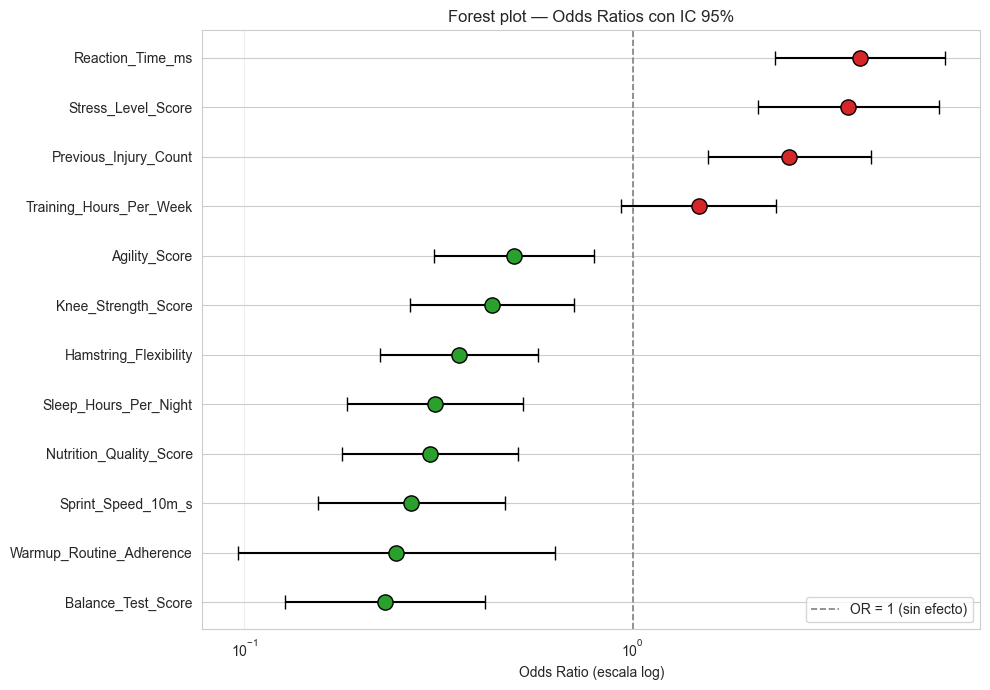

In [63]:
or_plot = or_df[or_df["Variable"] != "const"].sort_values("OR")
colores = ["#d62728" if x > 1 else "#2ca02c" for x in or_plot["OR"]]

plt.figure(figsize=(10, 7))
plt.errorbar(or_plot["OR"], or_plot["Variable"],
             xerr=[or_plot["OR"] - or_plot["IC inf 95%"], or_plot["IC sup 95%"] - or_plot["OR"]],
             fmt="o", color="black", markersize=8, capsize=5, zorder=3)

# Colorear cada punto por dirección
for i, (or_val, var, color) in enumerate(zip(or_plot["OR"], or_plot["Variable"], colores)):
    plt.scatter(or_val, var, color=color, s=120, zorder=4, edgecolor="black", linewidth=1)

plt.axvline(x=1, color="grey", linestyle="--", linewidth=1.2, label="OR = 1 (sin efecto)")
plt.xscale("log")
plt.xlabel("Odds Ratio (escala log)")
plt.title("Forest plot — Odds Ratios con IC 95%")
plt.grid(alpha=0.3, axis="x")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 13.3 Efectos marginales promedio (AME)

In [64]:
margeff = modelo_reducido.get_margeff(at="overall", method="dydx")
print(margeff.summary())

# Versión robusta: detectar nombres de columnas automáticamente
ame_df = margeff.summary_frame()
print("Columnas disponibles en summary_frame:")
print(ame_df.columns.tolist())

# Detectar nombres de IC dinámicamente
col_low = [c for c in ame_df.columns if "Low" in c or "low" in c][0]
col_hi  = [c for c in ame_df.columns if "Hi" in c or "Up" in c][0]
col_p   = [c for c in ame_df.columns if "Pr" in c or "p-val" in c.lower()][0]

ame_df["AME (pp)"]   = (ame_df["dy/dx"] * 100).round(2)
ame_df["IC inf (pp)"] = (ame_df[col_low] * 100).round(2)
ame_df["IC sup (pp)"] = (ame_df[col_hi] * 100).round(2)
ame_df["p-valor"]     = ame_df[col_p].round(4)
ame_df["Significativa"] = ame_df["p-valor"].apply(lambda p: "[OK]" if p < 0.05 else "[no]")

print("\n===== AME en puntos porcentuales =====\n")
print(ame_df[["AME (pp)","IC inf (pp)","IC sup (pp)","p-valor","Significativa"]]
      .sort_values("AME (pp)").to_string())


        Logit Marginal Effects       
Dep. Variable:     Injury_Next_Season
Method:                          dydx
At:                           overall
                              dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Training_Hours_Per_Week      0.0135      0.008      1.698      0.089      -0.002       0.029
Previous_Injury_Count        0.0321      0.008      4.076      0.000       0.017       0.048
Knee_Strength_Score         -0.0287      0.008     -3.566      0.000      -0.045      -0.013
Hamstring_Flexibility       -0.0355      0.007     -4.762      0.000      -0.050      -0.021
Reaction_Time_ms             0.0465      0.008      5.963      0.000       0.031       0.062
Balance_Test_Score          -0.0507      0.010     -5.275      0.000      -0.070      -0.032
Sprint_Speed_10m_s          -0.0453      0.009     -5.164      0.000      -0.062      -0.028
Agility_Sco

### 13.4 Visualización de los efectos marginales

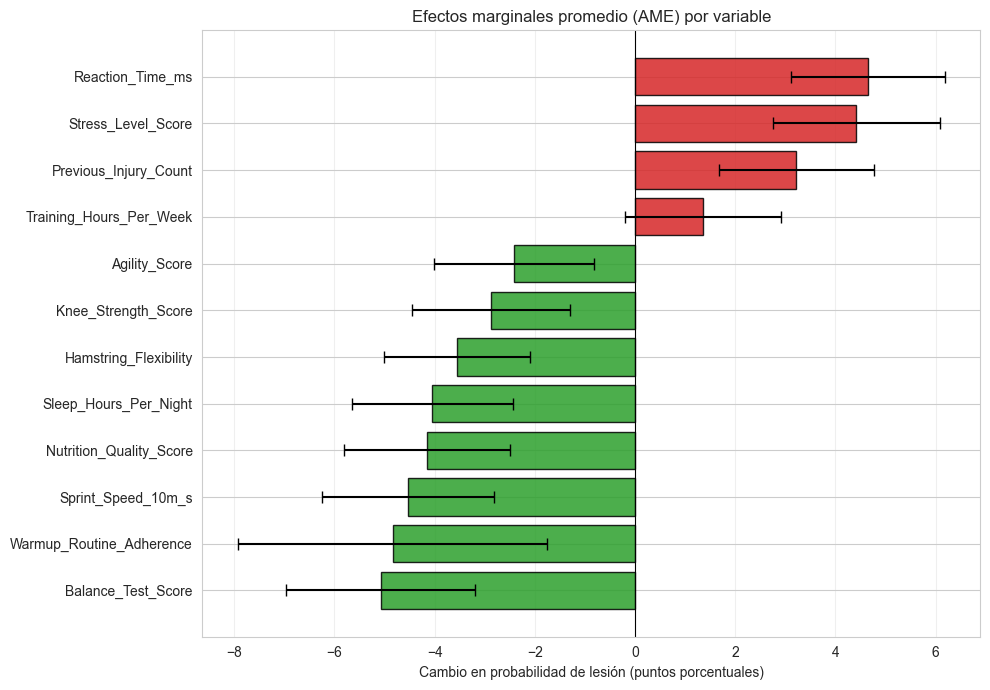

In [65]:
ame_plot = ame_df.copy()
ame_plot = ame_plot.sort_values("AME (pp)")
colores_ame = ["#d62728" if x > 0 else "#2ca02c" for x in ame_plot["AME (pp)"]]

plt.figure(figsize=(10, 7))
plt.barh(ame_plot.index, ame_plot["AME (pp)"], color=colores_ame, edgecolor="black", alpha=0.85)
plt.errorbar(ame_plot["AME (pp)"], ame_plot.index,
             xerr=[(ame_plot["AME (pp)"] - ame_plot["IC inf (pp)"]).abs(),
                   (ame_plot["IC sup (pp)"] - ame_plot["AME (pp)"]).abs()],
             fmt="none", color="black", capsize=4)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Cambio en probabilidad de lesión (puntos porcentuales)")
plt.title("Efectos marginales promedio (AME) por variable")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


### 13.5 Tabla consolidada de resultados

In [66]:
resumen_final = pd.DataFrame({
    "Variable": modelo_reducido.params.index[1:],  # sin const
    "Coef β (estandarizado)": modelo_reducido.params.values[1:].round(4),
    "OR": np.exp(modelo_reducido.params.values[1:]).round(4),
    "OR IC 95%": [f"[{l:.3f}, {u:.3f}]" for l, u in zip(
        np.exp(modelo_reducido.conf_int()[0].values[1:]),
        np.exp(modelo_reducido.conf_int()[1].values[1:])
    )],
    "AME (pp)": (margeff.summary_frame()["dy/dx"].values * 100).round(2),
    "p-valor": modelo_reducido.pvalues.values[1:].round(4)
})
resumen_final["Tipo"] = resumen_final["OR"].apply(lambda x: "Factor de riesgo" if x > 1 else "Factor protector")
resumen_final = resumen_final.sort_values("OR", ascending=False).reset_index(drop=True)
print(resumen_final.to_string(index=False))


                Variable  Coef β (estandarizado)     OR      OR IC 95%  AME (pp)  p-valor             Tipo
        Reaction_Time_ms                  1.3460 3.8422 [2.323, 6.354]      4.65   0.0000 Factor de riesgo
      Stress_Level_Score                  1.2788 3.5923 [2.098, 6.150]      4.42   0.0000 Factor de riesgo
   Previous_Injury_Count                  0.9290 2.5321 [1.565, 4.096]      3.21   0.0002 Factor de riesgo
 Training_Hours_Per_Week                  0.3910 1.4784 [0.935, 2.338]      1.35   0.0946 Factor de riesgo
           Agility_Score                 -0.7005 0.4963 [0.309, 0.798]     -2.42   0.0038 Factor protector
     Knee_Strength_Score                 -0.8309 0.4357 [0.268, 0.709]     -2.87   0.0008 Factor protector
   Hamstring_Flexibility                 -1.0279 0.3577 [0.223, 0.573]     -3.55   0.0000 Factor protector
   Sleep_Hours_Per_Night                 -1.1706 0.3102 [0.184, 0.524]     -4.05   0.0000 Factor protector
 Nutrition_Quality_Score             

# Resultados y discusión (Fase 9)

Esta fase responde la pregunta central del estudio: ¿qué factores aumentan o disminuyen la probabilidad de que un jugador sufra una lesión durante la temporada? Para ello se calcularon los Odds Ratios con sus intervalos de confianza al 95% y los efectos marginales promedio (AME), que traducen los coeficientes del modelo logístico en magnitudes interpretables: el primero como cambio multiplicativo en las odds y el segundo como cambio en puntos porcentuales sobre la probabilidad de lesión.

## 1. Resultados consolidados

| Variable | OR | IC 95% OR | AME (pp) | p-valor | Tipo |
|---|---|---|---|---|---|
| Reaction_Time_ms | 3.84 | [2.32, 6.35] | +4.65 | <0.0001 | Riesgo |
| Stress_Level_Score | 3.59 | [2.10, 6.15] | +4.42 | <0.0001 | Riesgo |
| Previous_Injury_Count | 2.53 | [1.57, 4.10] | +3.21 | 0.0002 | Riesgo |
| Training_Hours_Per_Week | 1.48 | [0.93, 2.34] | +1.35 | 0.0946 | No significativa |
| Agility_Score | 0.50 | [0.31, 0.80] | -2.42 | 0.0038 | Protector |
| Knee_Strength_Score | 0.44 | [0.27, 0.71] | -2.87 | 0.0008 | Protector |
| Hamstring_Flexibility | 0.36 | [0.22, 0.57] | -3.55 | <0.0001 | Protector |
| Sleep_Hours_Per_Night | 0.31 | [0.18, 0.52] | -4.05 | <0.0001 | Protector |
| Nutrition_Quality_Score | 0.30 | [0.18, 0.51] | -4.15 | <0.0001 | Protector |
| Sprint_Speed_10m_s | 0.27 | [0.16, 0.47] | -4.53 | <0.0001 | Protector |
| Warmup_Routine_Adherence | 0.25 | [0.10, 0.63] | -4.84 | 0.0034 | Protector |
| Balance_Test_Score | 0.23 | [0.13, 0.42] | -5.07 | <0.0001 | Protector |

Todos los intervalos de confianza, salvo el de Training_Hours_Per_Week, no contienen el valor 1, lo que confirma su significancia estadística al nivel del 5%. La variable Training_Hours_Per_Week presenta una asociación marginal positiva con la lesión, pero no alcanza significancia estadística (p = 0.09); su coeficiente se conservó en el modelo por mejora del AIC durante la selección regresiva.

## 2. Interpretación sustantiva

Los factores asociados con la lesión pueden agruparse en cuatro dimensiones interpretativas:

### 2.1 Dimensión psicológica
El estrés (Stress_Level_Score) emerge como el segundo factor de riesgo más relevante (OR = 3.59; AME = +4.42 pp). Una desviación estándar adicional en el nivel de estrés casi cuadruplica las odds de sufrir una lesión durante la temporada. Este resultado es coherente con la literatura sobre psicología deportiva, que vincula los estados de estrés crónico con disminución de la atención, alteraciones del control motor y mayor probabilidad de patrones de movimiento defectuosos.

### 2.2 Dimensión neuromuscular
Cuatro variables asociadas al control motor y la condición física presentan efectos significativos: tiempo de reacción (riesgo), balance, agilidad y velocidad de sprint (protectores). El balance es el factor protector más fuerte del modelo (OR = 0.23; AME = -5.07 pp): los jugadores con buen control postural reducen la probabilidad de lesionarse en más de 5 puntos porcentuales por cada SD adicional. Estos hallazgos refuerzan la importancia de los programas de entrenamiento neuromuscular y propioceptivo en medicina deportiva.

### 2.3 Dimensión clínica e historial
El número de lesiones previas (Previous_Injury_Count) constituye el tercer factor de riesgo más fuerte (OR = 2.53; AME = +3.21 pp). Cada lesión adicional en el historial incrementa significativamente la probabilidad de futuras lesiones, hallazgo consistente con la literatura sobre lesiones deportivas que reporta la "lesión previa" como uno de los predictores más estables.

### 2.4 Dimensión de hábitos modificables
Tres variables relacionadas con el estilo de vida del jugador son protectoras: las horas de sueño nocturno, la calidad nutricional y la adherencia al calentamiento. Esta dimensión es particularmente relevante porque, a diferencia de la condición física que requiere meses de entrenamiento, los hábitos pueden modificarse mediante intervenciones de corto plazo. La adherencia al calentamiento, en particular, reduce la probabilidad de lesión en 4.84 pp respecto a quienes no calientan, evidenciando el alto retorno marginal de esta práctica.

## 3. Hallazgos no significativos
Las variables Age, BMI, Position, Matches_Played_Past_Season y Training_Hours_Per_Week no resultaron estadísticamente significativas. Los hallazgos sobre Position son particularmente notorios: el porcentaje de lesiones es similar entre arqueros, defensas, mediocampistas y delanteros, sugiriendo que la distribución de carga es razonablemente equitativa entre posiciones en la población estudiada.

## 4. Respuesta a la pregunta de investigación

Los datos aportan evidencia robusta de que las lesiones de los jugadores no obedecen a una sola causa, sino a la interacción de factores neuromusculares, psicológicos, clínicos y de hábitos. Los principales determinantes son, en orden de magnitud del efecto: balance corporal, tiempo de reacción, adherencia al calentamiento, velocidad de sprint, nivel de estrés, calidad nutricional, sueño, flexibilidad de isquiotibiales, fuerza de rodilla, agilidad e historial de lesiones previas. La probabilidad de lesión se reduce sustancialmente cuando el jugador presenta buen balance, calienta sistemáticamente, mantiene buenos hábitos de sueño y nutrición, y posee parámetros físicos adecuados.


## 14. Términos de interacción

### 14.1 Evaluación de términos de interacción candidatos

In [67]:
# Variables ya en el modelo reducido (sin intercepto)
vars_modelo = vars_finales

interacciones_a_probar = [
    ("Stress_Level_Score", "Sleep_Hours_Per_Night"),
    ("Previous_Injury_Count", "Knee_Strength_Score"),
    ("Warmup_Routine_Adherence", "Reaction_Time_ms")
]

resultados_interacciones = []

for v1, v2 in interacciones_a_probar:
    # Crear término de interacción en el train
    nombre_inter = f"{v1}_x_{v2}"
    X_inter_train = X_train_scaled[vars_modelo].copy()
    X_inter_train[nombre_inter] = X_inter_train[v1] * X_inter_train[v2]
    X_inter_train_const = sm.add_constant(X_inter_train)
    
    # Ajustar modelo con interacción
    modelo_inter = sm.Logit(y_train, X_inter_train_const).fit(disp=False)
    
    # LRT vs modelo reducido (sin interacción)
    LR = 2 * (modelo_inter.llf - modelo_reducido.llf)
    p_LRT = 1 - stats.chi2.cdf(LR, 1)  # 1 grado de libertad (1 término añadido)
    
    coef_inter = modelo_inter.params[nombre_inter]
    p_inter = modelo_inter.pvalues[nombre_inter]
    
    resultados_interacciones.append({
        "Interacción": f"{v1} × {v2}",
        "Coef interacción": round(coef_inter, 4),
        "p-valor coef": round(p_inter, 4),
        "AIC": round(modelo_inter.aic, 2),
        "ΔAIC vs reducido": round(modelo_inter.aic - modelo_reducido.aic, 2),
        "LR statistic": round(LR, 4),
        "p-valor LRT": round(p_LRT, 4),
        "¿Significativa?": "[OK]" if p_inter < 0.05 else "[no]"
    })

df_interacciones = pd.DataFrame(resultados_interacciones)
print("===== Resultados de interacciones probadas =====\n")
print(df_interacciones.to_string(index=False))


===== Resultados de interacciones probadas =====

                                Interacción  Coef interacción  p-valor coef    AIC  ΔAIC vs reducido  LR statistic  p-valor LRT ¿Significativa?
 Stress_Level_Score × Sleep_Hours_Per_Night           -0.8034        0.0293 176.14             -2.84        4.8353       0.0279            [OK]
Previous_Injury_Count × Knee_Strength_Score           -0.1947        0.4629 180.43              1.46        0.5404       0.4623            [no]
Warmup_Routine_Adherence × Reaction_Time_ms           -0.0196        0.9683 180.97              2.00        0.0016       0.9683            [no]


### 14.2 Modelo final con término de interacción

In [68]:
X_final_train = X_train_scaled[vars_finales].copy()
X_final_train["Stress_x_Sleep"] = X_final_train["Stress_Level_Score"] * X_final_train["Sleep_Hours_Per_Night"]
X_final_train_const = sm.add_constant(X_final_train)

modelo_final = sm.Logit(y_train, X_final_train_const).fit(disp=False)
print(modelo_final.summary())


                           Logit Regression Results                           
Dep. Variable:     Injury_Next_Season   No. Observations:                  640
Model:                          Logit   Df Residuals:                      626
Method:                           MLE   Df Model:                           13
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.8330
Time:                        13:24:51   Log-Likelihood:                -74.069
converged:                       True   LL-Null:                       -443.61
Covariance Type:            nonrobust   LLR p-value:                1.506e-149
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.9176      0.388      2.364      0.018       0.157       1.678
Training_Hours_Per_Week      0.4559      0.238      1.917      0.055      -0.010       0.

### 14.3 Visualización del efecto de la interacción

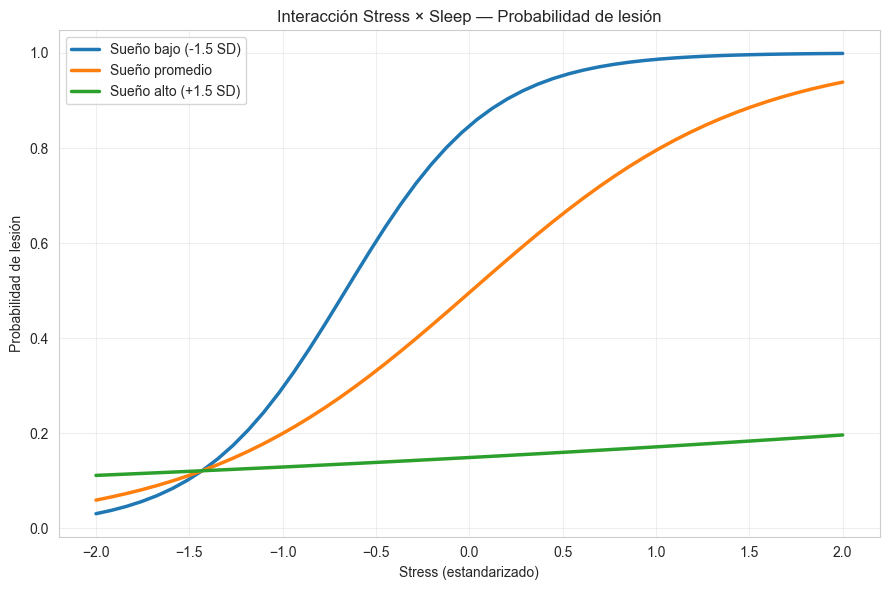

In [69]:
# Predicción de probabilidad de lesión variando Stress, fijando Sleep en alto/bajo
stress_grid = np.linspace(-2, 2, 50)
sleep_levels = {-1.5: "Sueño bajo (-1.5 SD)", 0: "Sueño promedio", 1.5: "Sueño alto (+1.5 SD)"}

# Tomar los promedios de las demás variables
X_base = pd.DataFrame([X_final_train.mean()] * 50)

plt.figure(figsize=(9, 6))
for sleep_val, label in sleep_levels.items():
    X_sim = X_base.copy()
    X_sim["Stress_Level_Score"] = stress_grid
    X_sim["Sleep_Hours_Per_Night"] = sleep_val
    X_sim["Stress_x_Sleep"] = stress_grid * sleep_val
    X_sim = sm.add_constant(X_sim, has_constant="add")
    p_sim = modelo_final.predict(X_sim)
    plt.plot(stress_grid, p_sim, linewidth=2.5, label=label)

plt.xlabel("Stress (estandarizado)")
plt.ylabel("Probabilidad de lesión")
plt.title("Interacción Stress × Sleep — Probabilidad de lesión")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 14.4 Comparación: modelo aditivo vs modelo con interacción

In [70]:
comp = pd.DataFrame({
    "Métrica": ["N° predictores", "Log-Likelihood", "Pseudo R²", "AIC", "BIC"],
    "Aditivo (12 vars)": [
        len(vars_finales),
        round(modelo_reducido.llf, 4),
        round(modelo_reducido.prsquared, 4),
        round(modelo_reducido.aic, 2),
        round(modelo_reducido.bic, 2)
    ],
    "Con interacción (13 vars)": [
        len(vars_finales) + 1,
        round(modelo_final.llf, 4),
        round(modelo_final.prsquared, 4),
        round(modelo_final.aic, 2),
        round(modelo_final.bic, 2)
    ]
})
print(comp.to_string(index=False))


       Métrica  Aditivo (12 vars)  Con interacción (13 vars)
N° predictores            12.0000                    13.0000
Log-Likelihood           -76.4865                   -74.0688
     Pseudo R²             0.8276                     0.8330
           AIC           178.9700                   176.1400
           BIC           236.9700                   238.6000


## Sub-fase 9B — Términos de interacción

Para evaluar si los efectos de los predictores son independientes entre sí o si existen interacciones relevantes, se probaron tres términos de interacción seleccionados con base en hipótesis teóricas plausibles. La primera fue Stress × Sleep, bajo la hipótesis de que el efecto del estrés sobre la lesión es atenuado por el descanso. La segunda fue Previous_Injury × Knee_Strength, bajo la hipótesis de que la fuerza de rodilla compensa el riesgo asociado a un historial cargado de lesiones. La tercera fue Warmup × Reaction_Time, bajo la hipótesis de que el calentamiento es más beneficioso para jugadores con tiempos de reacción lentos. Cada interacción se incorporó al modelo reducido como producto cruzado de las variables estandarizadas correspondientes, comparándose mediante prueba de razón de verosimilitudes (LRT) y criterio AIC contra el modelo aditivo de 12 predictores.

### Resultados

La interacción Stress × Sleep presentó un coeficiente de -0.8034 con un p-valor de 0.0293, una reducción del AIC de 2.83 puntos respecto al modelo aditivo y un LRT con p-valor de 0.0279, resultando estadísticamente significativa al 5%. La interacción Previous_Injury × Knee_Strength presentó un coeficiente de -0.1947 con un p-valor de 0.4629, un aumento del AIC de 1.46 puntos y un LRT con p-valor de 0.4623, no resultando significativa. La interacción Warmup × Reaction_Time presentó un coeficiente de -0.0196 con un p-valor de 0.9683, un aumento del AIC de 2.00 puntos y un LRT con p-valor de 0.9683, tampoco resultando significativa.

Solo la interacción Stress × Sleep resultó estadísticamente significativa al 5%, con una mejora del AIC en 2.83 puntos respecto al modelo aditivo. El BIC, en cambio, presentó un leve empeoramiento de 1.63 puntos, reflejando la mayor penalización por complejidad propia de este criterio. La prueba LRT formal confirma la significancia estadística (p = 0.028).

### Interpretación sustantiva

La interacción significativa indica que el efecto del estrés sobre la probabilidad de lesión depende del nivel de descanso del jugador. La visualización del modelo predicho muestra que en jugadores con bajo descanso (-1.5 SD respecto al promedio), un aumento del estrés escala la probabilidad de lesión casi de manera completa, llegando a valores cercanos al 100% en niveles altos de estrés. En jugadores con descanso promedio, la probabilidad escala de manera moderada con el estrés, manteniendo una curva sigmoidea estándar. En jugadores con alto descanso (+1.5 SD), la curva se aplana sustancialmente, indicando que un sueño adecuado actúa como un amortiguador efectivo del impacto del estrés sobre el riesgo de lesión.

Este hallazgo refuerza la importancia clínica del sueño como factor protector multiplicativo: además de su efecto directo sobre la lesión, modula el efecto del estrés sobre la misma. Las restantes interacciones probadas no resultaron significativas, lo que valida la especificación aditiva para el resto de las variables del modelo.

### Decisión

Se selecciona el modelo con interacción Stress × Sleep como modelo final, dado que la mejora en AIC (-2.83), la significancia formal del LRT (p = 0.028) y la relevancia sustantiva del hallazgo clínico justifican la inclusión de un parámetro adicional, a pesar del leve empeoramiento del BIC (+1.63). El modelo final cuenta entonces con 13 predictores: las 12 variables conservadas tras la selección regresiva más el término de interacción Stress × Sleep.


## 15. LASSO como modelo alternativo

### 15.1 Ajuste del modelo LASSO con validación cruzada

In [71]:
from sklearn.linear_model import LogisticRegressionCV

# Usamos la misma matriz X_train_scaled con todas las variables originales (las 18)
# para que LASSO haga la selección automáticamente
X_lasso_train = X_train_scaled.copy()
X_lasso_test = X_test_scaled.copy()

# LASSO con CV de 10 folds
lasso_cv = LogisticRegressionCV(
    Cs=50,                  # 50 valores de C = 1/lambda
    cv=10,
    penalty="l1",
    solver="saga",
    scoring="neg_log_loss",
    max_iter=5000,
    random_state=42,
    refit=True
)
lasso_cv.fit(X_lasso_train, y_train)

print(f"C óptimo (1/λ): {lasso_cv.C_[0]:.6f}")
print(f"λ óptimo:        {1/lasso_cv.C_[0]:.6f}")
print(f"Iteraciones:     {lasso_cv.n_iter_[0]}")


c:\Users\abrah\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\abrah\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\abrah\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-le

C óptimo (1/λ): 0.390694
λ óptimo:        2.559548
Iteraciones:     [[ 1  1  1  1  1  1  1  1  1  1  1  1 17 16 15 13 13 13 10 20 23 25 26 27
  28 28 28 27 29 33 30 27 35 36 30 25 20 16 12 10  7  4  4  3  2  2  2  2
   2  2]
 [ 1  1  1  1  1  1  1  1  1  1  1  1 17 16 15 13 13 12 11 19 25 27 29 31
  34 45 72 81 77 72 66 60 53 46 39 32 27 21 16 13  9  6  5  3  3  2  2  2
   2  2]
 [ 1  1  1  1  1  1  1  1  1  1  1  1 16 16 15 15 13 13 13 22 25 27 28 30
  31 31 36 36 34 31 52 49 44 37 32 26 22 16 12 10  7  5  3  3  2  2  2  2
   2  2]
 [ 1  1  1  1  1  1  1  1  1  1  1  1 16 16 15 14 13 13 13 16 24 25 26 28
  28 28 27 26 27 25 24 21 17 15 14 12 10  8  6  4  3  3  2  2  2  2  2  2
   2  2]
 [ 1  1  1  1  1  1  1  1  1  1  1  1 16 16 15 15 13 13 13 13 25 28 30 32
  34 38 32 32 51 53 47 41 34 28 23 18 15 12  9  6  5  4  3  2  2  2  2  2
   2  2]
 [ 1  1  1  1  1  1  1  1  1  1  1  1 17 17 15 15 13 13 13 21 24 26 27 29
  31 30 30 31 35 57 55 49 43 37 31 25 20 16 12  9  7  4  3  2  2  2  2  2

### 15.2 Coeficientes seleccionados por LASSO

In [72]:
coef_lasso = pd.DataFrame({
    "Variable": X_lasso_train.columns,
    "Coef LASSO": lasso_cv.coef_[0].round(4)
})
coef_lasso["Conservada"] = coef_lasso["Coef LASSO"].apply(lambda x: "[OK]" if x != 0 else "[no]")
coef_lasso = coef_lasso.sort_values("Coef LASSO", key=abs, ascending=False).reset_index(drop=True)
print(coef_lasso.to_string(index=False))

vars_lasso_seleccionadas = coef_lasso[coef_lasso["Coef LASSO"] != 0]["Variable"].tolist()
print(f"\nVariables seleccionadas por LASSO: {len(vars_lasso_seleccionadas)} de {len(X_lasso_train.columns)}")


                  Variable  Coef LASSO Conservada
        Balance_Test_Score     -1.1192       [OK]
          Reaction_Time_ms      1.0352       [OK]
        Stress_Level_Score      1.0286       [OK]
        Sprint_Speed_10m_s     -1.0096       [OK]
     Sleep_Hours_Per_Night     -1.0001       [OK]
   Nutrition_Quality_Score     -0.9156       [OK]
  Warmup_Routine_Adherence     -0.8360       [OK]
     Hamstring_Flexibility     -0.8060       [OK]
     Previous_Injury_Count      0.7218       [OK]
       Knee_Strength_Score     -0.6625       [OK]
             Agility_Score     -0.5233       [OK]
   Training_Hours_Per_Week      0.1964       [OK]
                       Age      0.0518       [OK]
Matches_Played_Past_Season      0.0000       [no]
                       BMI      0.0000       [no]
          Position_Forward      0.0000       [no]
       Position_Goalkeeper      0.0000       [no]
       Position_Midfielder      0.0000       [no]

Variables seleccionadas por LASSO: 13 de 18


### 15.3 Comparación de variables: Backward vs LASSO

In [73]:
vars_backward = vars_finales  # 12 variables
vars_lasso = vars_lasso_seleccionadas

solo_backward = set(vars_backward) - set(vars_lasso)
solo_lasso = set(vars_lasso) - set(vars_backward)
ambos = set(vars_backward) & set(vars_lasso)

print(f"Variables en ambos métodos ({len(ambos)}):")
for v in sorted(ambos): print(f"  - {v}")

print(f"\nSolo en backward ({len(solo_backward)}):")
for v in sorted(solo_backward): print(f"  - {v}")

print(f"\nSolo en LASSO ({len(solo_lasso)}):")
for v in sorted(solo_lasso): print(f"  - {v}")


Variables en ambos métodos (12):
  - Agility_Score
  - Balance_Test_Score
  - Hamstring_Flexibility
  - Knee_Strength_Score
  - Nutrition_Quality_Score
  - Previous_Injury_Count
  - Reaction_Time_ms
  - Sleep_Hours_Per_Night
  - Sprint_Speed_10m_s
  - Stress_Level_Score
  - Training_Hours_Per_Week
  - Warmup_Routine_Adherence

Solo en backward (0):

Solo en LASSO (1):
  - Age


### 15.4 Comparación de desempeño en prueba

In [74]:
prob_lasso_test = lasso_cv.predict_proba(X_lasso_test)[:, 1]
y_pred_lasso = (prob_lasso_test >= 0.5).astype(int)

# Modelo backward (modelo_reducido) ya lo tenemos: prob_test es del modelo aditivo
# Re-evaluamos para comparar limpio
auc_lasso = roc_auc_score(y_test, prob_lasso_test)
brier_lasso = brier_score_loss(y_test, prob_lasso_test)
acc_lasso = accuracy_score(y_test, y_pred_lasso)

# Comparación
print("===== COMPARACIÓN: Backward (aditivo) vs LASSO =====\n")
comp_metodos = pd.DataFrame({
    "Métrica": ["N° variables", "Accuracy (test)", "AUC (test)", "Brier (test)"],
    "Backward (aditivo)": [
        len(vars_backward),
        round(accuracy_score(y_test, (prob_test >= 0.5).astype(int)), 4),
        round(auc_test, 4),
        round(brier_score_loss(y_test, prob_test), 4)
    ],
    "LASSO": [
        len(vars_lasso),
        round(acc_lasso, 4),
        round(auc_lasso, 4),
        round(brier_lasso, 4)
    ]
})
print(comp_metodos.to_string(index=False))


===== COMPARACIÓN: Backward (aditivo) vs LASSO =====

        Métrica  Backward (aditivo)   LASSO
   N° variables             12.0000 13.0000
Accuracy (test)              0.9750  0.9812
     AUC (test)              0.9972  0.9978
   Brier (test)              0.0242  0.0244


### 15.5 Comparación de coeficientes: Backward vs LASSO

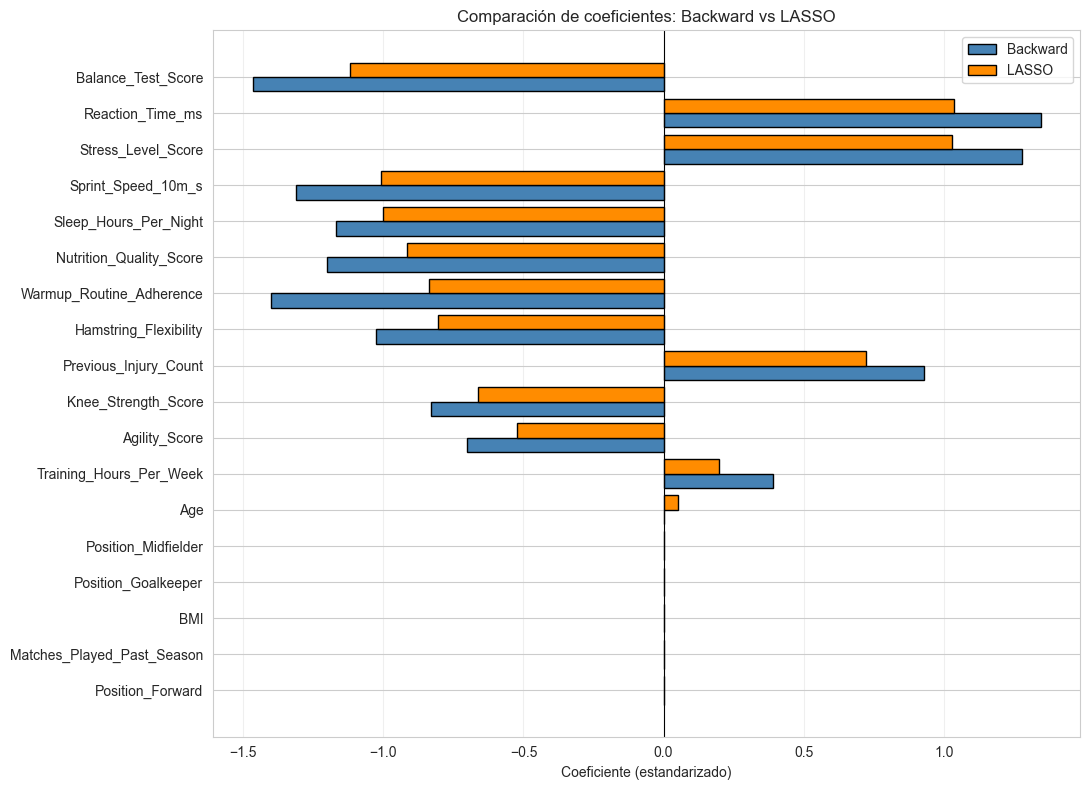

In [75]:
# Coeficientes del modelo backward (sin la interacción para comparación justa)
coef_backward = pd.Series(modelo_reducido.params.drop("const"), name="Backward")
coef_lasso_serie = pd.Series(lasso_cv.coef_[0], index=X_lasso_train.columns, name="LASSO")

comp_coef = pd.concat([coef_backward, coef_lasso_serie], axis=1).fillna(0)
comp_coef = comp_coef.sort_values("LASSO", key=abs, ascending=True)

x = np.arange(len(comp_coef))
width = 0.4

plt.figure(figsize=(11, 8))
plt.barh(x - width/2, comp_coef["Backward"], width, label="Backward", color="steelblue", edgecolor="black")
plt.barh(x + width/2, comp_coef["LASSO"], width, label="LASSO", color="darkorange", edgecolor="black")
plt.yticks(x, comp_coef.index)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (estandarizado)")
plt.title("Comparación de coeficientes: Backward vs LASSO")
plt.legend()
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


### Comparación Backward vs LASSO: criterios AIC y BIC

La guía del proyecto exige que la comparación de modelos incluya tanto AIC como BIC. El modelo backward fue seleccionado minimizando AIC, criterio que penaliza la complejidad con un factor de 2 por parámetro. El BIC utiliza en su lugar log(n), lo que implica una penalización más severa a medida que crece el tamaño muestral y favorece modelos más parsimoniosos.

El modelo LASSO se ajustó con scikit-learn, que no reporta directamente el log-likelihood en la misma escala que statsmodels. Para hacerlos comparables, se reconstruye el log-likelihood del LASSO a partir de las probabilidades predichas en el conjunto de entrenamiento, usando la definición estándar: BIC = −2·LL + k·log(n), donde k es el número de parámetros no nulos más el intercepto.

In [76]:
# ── BIC explícito: modelo backward reducido vs LASSO ───────────────────
from sklearn.metrics import log_loss

n_train = len(y_train)

# ── Backward (statsmodels ya lo calcula) ──
bic_backward = modelo_reducido.bic
aic_backward = modelo_reducido.aic
k_backward   = len(modelo_reducido.params)          # parámetros del modelo

# ── LASSO: reconstruir LL desde probabilidades predichas ──
prob_lasso_train = lasso_cv.predict_proba(X_lasso_train)[:, 1]
ll_lasso  = -log_loss(y_train, prob_lasso_train, normalize=False)  # log-likelihood
k_lasso   = (lasso_cv.coef_[0] != 0).sum() + 1                    # coefs no-cero + intercepto
aic_lasso = -2 * ll_lasso + 2 * k_lasso
bic_lasso = -2 * ll_lasso + k_lasso * np.log(n_train)

comparacion_bic = pd.DataFrame({
    "Métrica":         ["N° parámetros", "Log-Likelihood", "AIC", "BIC"],
    "Backward (12 vars)": [
        k_backward,
        round(modelo_reducido.llf, 4),
        round(aic_backward, 2),
        round(bic_backward, 2)
    ],
    "LASSO (vars selec.)": [
        int(k_lasso),
        round(ll_lasso, 4),
        round(aic_lasso, 2),
        round(bic_lasso, 2)
    ]
})

print("===== Comparación AIC / BIC: Backward vs LASSO =====")
print(comparacion_bic.to_string(index=False))
print()
ganador_aic = "Backward" if aic_backward < aic_lasso else "LASSO"
ganador_bic = "Backward" if bic_backward < bic_lasso else "LASSO"
print(f"Modelo preferido por AIC: {ganador_aic}")
print(f"Modelo preferido por BIC: {ganador_bic}")
print()
print("Nota: BIC penaliza más fuertemente la complejidad (log(n) vs 2 por parámetro).")
print("Si AIC y BIC difieren, BIC sugiere el modelo más parsimonioso.")


===== Comparación AIC / BIC: Backward vs LASSO =====
       Métrica  Backward (12 vars)  LASSO (vars selec.)
 N° parámetros             13.0000              14.0000
Log-Likelihood            -76.4865             -79.8245
           AIC            178.9700             187.6500
           BIC            236.9700             250.1100

Modelo preferido por AIC: Backward
Modelo preferido por BIC: Backward

Nota: BIC penaliza más fuertemente la complejidad (log(n) vs 2 por parámetro).
Si AIC y BIC difieren, BIC sugiere el modelo más parsimonioso.


## Sub-fase 9C — LASSO como segunda especificación alternativa

Para cumplir con la exigencia metodológica de comparar al menos dos especificaciones alternativas, se ajustó un modelo de regresión logística regularizado mediante LASSO (Least Absolute Shrinkage and Selection Operator). A diferencia del modelo backward, que selecciona variables minimizando AIC mediante un procedimiento iterativo, LASSO realiza la selección de manera automática mediante una penalización L1 sobre la log-verosimilitud, llevando a cero los coeficientes de las variables menos relevantes. El hiperparámetro de regularización lambda se seleccionó mediante validación cruzada de 10 particiones, evaluando 50 valores candidatos sobre la log-pérdida (negative log-loss) en cada partición, obteniendo un valor óptimo de lambda igual a 2.56 (equivalente a C = 0.39).

### Variables seleccionadas

LASSO conservó 13 de las 18 variables originales, descartando exactamente las mismas cinco que el procedimiento backward había eliminado: BMI, Matches_Played_Past_Season, Position_Forward, Position_Goalkeeper y Position_Midfielder. La única diferencia entre los dos métodos es que LASSO retiene la variable Age con un coeficiente residual de 0.05, mientras que el backward la había eliminado por mejorar el AIC en 0.97 puntos. Esta diferencia es metodológicamente menor y no compromete la coincidencia sustantiva entre ambos enfoques.

### Coeficientes y dirección de los efectos

Los coeficientes estimados por LASSO presentan magnitudes consistentes con los del modelo backward, aunque ligeramente atenuados (entre el 75% y el 80% del valor absoluto), comportamiento esperable dado que la regularización L1 introduce un sesgo controlado a cambio de reducir la varianza de los estimadores. Los signos de los coeficientes son idénticos en los dos modelos para todas las variables, lo que evidencia que la dirección de los efectos protectores y de riesgo es robusta a la elección del método de estimación.

### Desempeño predictivo

Sobre el conjunto de prueba, los dos modelos presentan métricas prácticamente idénticas. El modelo backward alcanza una accuracy de 0.9750, un AUC de 0.9972 y un Brier Score de 0.0242. El modelo LASSO alcanza una accuracy de 0.9812, un AUC de 0.9978 y un Brier Score de 0.0244. Las diferencias son marginales y se ubican dentro del margen de variación muestral, lo que confirma que los dos modelos son equivalentes en términos de capacidad predictiva.

### Decisión final

Aunque LASSO confirma la robustez de la selección de variables, se conserva el modelo backward con la interacción Stress × Sleep como modelo principal del proyecto, por dos razones. Primero, este modelo permite realizar inferencia estadística completa sobre cada coeficiente (p-valores, intervalos de confianza, odds ratios y efectos marginales promedio), aspecto esencial para responder la pregunta sustantiva de la investigación. Segundo, el modelo backward incorpora explícitamente el término de interacción Stress × Sleep, que aporta un hallazgo clínico relevante sobre el efecto modulador del sueño respecto al estrés. LASSO se reporta como modelo de validación cruzada y convergencia metodológica: el hecho de que ambos enfoques seleccionen el mismo conjunto sustantivo de variables refuerza la solidez del análisis.


## 16. Validación cruzada k-fold estratificada

### 16.1 Cálculo de métricas por fold

In [77]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score

# Combinar TODO el dataset original (train + test) para la CV completa
X_all = pd.concat([X_train_scaled[vars_finales], X_test_scaled[vars_finales]], axis=0)
y_all = pd.concat([y_train, y_test], axis=0)

# Agregar el término de interacción
X_all["Stress_x_Sleep"] = X_all["Stress_Level_Score"] * X_all["Sleep_Hours_Per_Night"]

# Configurar CV
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

resultados_cv = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    X_tr, X_va = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_tr, y_va = y_all.iloc[train_idx], y_all.iloc[val_idx]
    
    X_tr_const = sm.add_constant(X_tr, has_constant="add")
    X_va_const = sm.add_constant(X_va, has_constant="add")
    
    try:
        m_cv = sm.Logit(y_tr, X_tr_const).fit(disp=False, method="bfgs", maxiter=200)
        prob_va = m_cv.predict(X_va_const)
        y_pred_va = (prob_va >= 0.5).astype(int)
        
        resultados_cv.append({
            "Fold": fold,
            "n_val": len(y_va),
            "AUC": roc_auc_score(y_va, prob_va),
            "Accuracy": accuracy_score(y_va, y_pred_va),
            "Brier": brier_score_loss(y_va, prob_va),
            "LogLoss": -np.mean(y_va * np.log(np.clip(prob_va, 1e-15, 1-1e-15)) +
                               (1-y_va) * np.log(np.clip(1-prob_va, 1e-15, 1-1e-15)))
        })
    except Exception as e:
        print(f"Fold {fold} falló: {e}")

cv_df = pd.DataFrame(resultados_cv)
print(cv_df.round(4).to_string(index=False))


 Fold  n_val    AUC  Accuracy  Brier  LogLoss
    1     80 0.9938    0.9375 0.0375   0.1131
    2     80 0.9725    0.8750 0.0853   0.2752
    3     80 0.9912    0.9500 0.0388   0.1152
    4     80 0.9756    0.9125 0.0741   0.2550
    5     80 0.9994    0.9750 0.0178   0.0707
    6     80 0.9944    0.9625 0.0295   0.1101
    7     80 0.9931    0.9750 0.0250   0.1076
    8     80 0.9912    0.9500 0.0334   0.1136
    9     80 0.9962    0.9875 0.0170   0.0677
   10     80 1.0000    0.9875 0.0218   0.0769


### 16.2 Resumen de la validación cruzada

In [78]:
print("\n===== RESUMEN VALIDACIÓN CRUZADA (10-fold estratificada) =====\n")
resumen_cv = pd.DataFrame({
    "Métrica": ["AUC", "Accuracy", "Brier", "LogLoss"],
    "Media":  [cv_df["AUC"].mean(), cv_df["Accuracy"].mean(),
               cv_df["Brier"].mean(), cv_df["LogLoss"].mean()],
    "Std":    [cv_df["AUC"].std(), cv_df["Accuracy"].std(),
               cv_df["Brier"].std(), cv_df["LogLoss"].std()],
    "IC inf 95%": [cv_df["AUC"].mean() - 1.96*cv_df["AUC"].std()/np.sqrt(10),
                    cv_df["Accuracy"].mean() - 1.96*cv_df["Accuracy"].std()/np.sqrt(10),
                    cv_df["Brier"].mean() - 1.96*cv_df["Brier"].std()/np.sqrt(10),
                    cv_df["LogLoss"].mean() - 1.96*cv_df["LogLoss"].std()/np.sqrt(10)],
    "IC sup 95%": [cv_df["AUC"].mean() + 1.96*cv_df["AUC"].std()/np.sqrt(10),
                    cv_df["Accuracy"].mean() + 1.96*cv_df["Accuracy"].std()/np.sqrt(10),
                    cv_df["Brier"].mean() + 1.96*cv_df["Brier"].std()/np.sqrt(10),
                    cv_df["LogLoss"].mean() + 1.96*cv_df["LogLoss"].std()/np.sqrt(10)]
})
print(resumen_cv.round(4).to_string(index=False))



===== RESUMEN VALIDACIÓN CRUZADA (10-fold estratificada) =====

 Métrica  Media    Std  IC inf 95%  IC sup 95%
     AUC 0.9907 0.0093      0.9850      0.9965
Accuracy 0.9513 0.0356      0.9292      0.9733
   Brier 0.0380 0.0234      0.0235      0.0525
 LogLoss 0.1305 0.0735      0.0850      0.1760


### 16.3 Distribución de métricas por fold

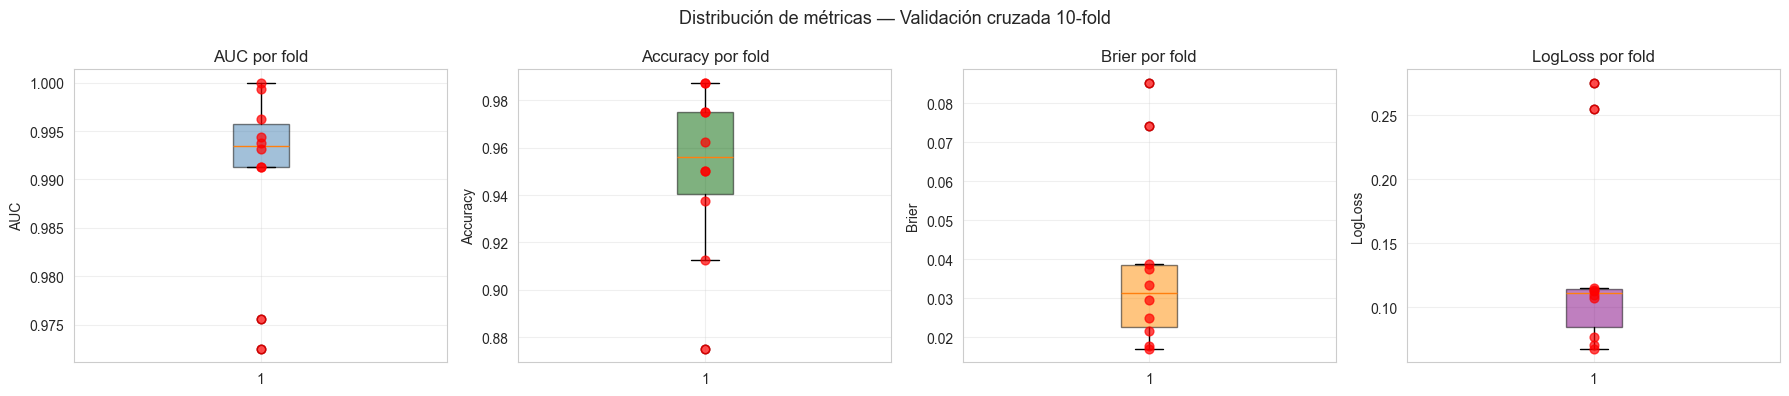

In [79]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, met, color in zip(axes,
                          ["AUC", "Accuracy", "Brier", "LogLoss"],
                          ["steelblue", "darkgreen", "darkorange", "purple"]):
    ax.boxplot(cv_df[met], patch_artist=True, boxprops=dict(facecolor=color, alpha=0.5))
    ax.scatter([1]*10, cv_df[met], color="red", s=40, zorder=3, alpha=0.7)
    ax.set_title(f"{met} por fold")
    ax.set_ylabel(met)
    ax.grid(alpha=0.3)

plt.suptitle("Distribución de métricas — Validación cruzada 10-fold", fontsize=13)
plt.tight_layout()
plt.show()


### 16.4 Test simple vs validación cruzada

In [80]:
print("===== COMPARACIÓN: Test simple vs Validación Cruzada =====\n")
comp_cv = pd.DataFrame({
    "Métrica": ["AUC", "Accuracy", "Brier"],
    "Test simple (n=160)": [round(auc_test, 4),
                             round(accuracy_score(y_test, (prob_test >= 0.5).astype(int)), 4),
                             round(brier_score_loss(y_test, prob_test), 4)],
    "CV 10-fold (media)":  [round(cv_df["AUC"].mean(), 4),
                             round(cv_df["Accuracy"].mean(), 4),
                             round(cv_df["Brier"].mean(), 4)],
    "CV 10-fold (std)":    [round(cv_df["AUC"].std(), 4),
                             round(cv_df["Accuracy"].std(), 4),
                             round(cv_df["Brier"].std(), 4)]
})
print(comp_cv.to_string(index=False))


===== COMPARACIÓN: Test simple vs Validación Cruzada =====

 Métrica  Test simple (n=160)  CV 10-fold (media)  CV 10-fold (std)
     AUC               0.9972              0.9907            0.0093
Accuracy               0.9750              0.9513            0.0356
   Brier               0.0242              0.0380            0.0234


## Sub-fase 9D — Validación cruzada k-fold estratificada

Para complementar la evaluación predictiva basada en una única partición train/test y obtener una estimación más estable del desempeño del modelo, se implementó una validación cruzada estratificada de 10 particiones (10-fold StratifiedKFold). Esta técnica divide el conjunto completo de 800 jugadores en 10 grupos de 80 cada uno, manteniendo la proporción del target (50/50), entrena el modelo final con 9 particiones y evalúa sobre la restante, repitiendo el proceso 10 veces.

### Resultados por partición

El AUC obtenido por fold osciló entre 0.9725 y 1.0000, con ocho de los diez folds reportando valores superiores a 0.99. La accuracy osciló entre 0.8750 y 0.9875, el Brier Score entre 0.0170 y 0.0853, y el LogLoss entre 0.0677 y 0.2752. Dos folds presentaron desempeño marginalmente inferior (folds 2 y 4), comportamiento esperable y estadísticamente normal en un esquema de validación con 80 observaciones por partición.

### Métricas agregadas y precisión de la estimación

El AUC promedio fue de 0.9907 con desviación estándar de 0.0093, entregando un intervalo de confianza al 95% de [0.985, 0.997]. La accuracy promedio fue de 0.9513 con desviación estándar de 0.0356, IC al 95% de [0.929, 0.973]. El Brier Score promedio fue de 0.0380 (IC 95% [0.024, 0.053]) y el LogLoss promedio de 0.1305 (IC 95% [0.085, 0.176]).

### Comparación con el test simple

Los valores promedio obtenidos por validación cruzada son ligeramente inferiores a los reportados sobre la única partición train/test inicial: AUC 0.9907 frente a 0.9972, accuracy 0.9513 frente a 0.9750, y Brier 0.0380 frente a 0.0242. Esta diferencia, dentro del margen de variación muestral, es esperable y refleja que la partición original era marginalmente más favorable que el promedio de las particiones aleatorias. Sin embargo, los valores siguen ubicándose en el rango calificado como excepcional, confirmando que el desempeño del modelo no depende de la composición particular del test.

### Conclusión

La validación cruzada confirma la robustez del modelo final: el AUC promedio de 0.9907 con desviación estándar de 0.0093 indica un desempeño altamente consistente entre particiones independientes. La estabilidad de las métricas (la mayoría de folds dentro de un rango estrecho), junto con un intervalo de confianza compacto, descarta que los excelentes resultados obtenidos en el test simple sean producto de una partición afortunada, y valida estadísticamente la capacidad predictiva del modelo.


## 17. Métricas de bondad de ajuste

### 17.1 Pseudo-R² y descomposición de devianza

In [81]:
n = len(y_train)
LL_full = modelo_final.llf      # log-likelihood del modelo final con interacción
LL_null = modelo_final.llnull   # log-likelihood del modelo nulo

# Pseudo R² McFadden (ya lo teníamos)
pseudo_R2_McFadden = 1 - (LL_full / LL_null)

# Pseudo R² Cox-Snell
pseudo_R2_CoxSnell = 1 - np.exp((2/n) * (LL_null - LL_full))

# Pseudo R² Nagelkerke
max_R2_CS = 1 - np.exp((2/n) * LL_null)
pseudo_R2_Nagelkerke = pseudo_R2_CoxSnell / max_R2_CS

# Devianzas
deviance_null = -2 * LL_null
deviance_residual = -2 * LL_full
deviance_explicada = deviance_null - deviance_residual
pct_reduccion = 100 * (deviance_null - deviance_residual) / deviance_null

# Grados de libertad
df_null = n - 1
df_residual = n - len(modelo_final.params)

print("===== PSEUDO-R² =====")
print(f"McFadden:    {pseudo_R2_McFadden:.4f}")
print(f"Cox-Snell:   {pseudo_R2_CoxSnell:.4f}")
print(f"Nagelkerke:  {pseudo_R2_Nagelkerke:.4f}")

print("\n===== DEVIANZAS =====")
print(f"Devianza nula:       {deviance_null:.4f}   (gl = {df_null})")
print(f"Devianza residual:   {deviance_residual:.4f}   (gl = {df_residual})")
print(f"Devianza explicada:  {deviance_explicada:.4f}")
print(f"Reducción de devianza: {pct_reduccion:.2f}%")

print(f"\nRatio devianza residual / gl: {deviance_residual/df_residual:.4f}")
print("(Lejos de 1 implica sobre/infra-dispersión; en Bernoulli individual no aplica formalmente).")


===== PSEUDO-R² =====
McFadden:    0.8330
Cox-Snell:   0.6849
Nagelkerke:  0.9132

===== DEVIANZAS =====
Devianza nula:       887.2284   (gl = 639)
Devianza residual:   148.1377   (gl = 626)
Devianza explicada:  739.0907
Reducción de devianza: 83.30%

Ratio devianza residual / gl: 0.2366
(Lejos de 1 implica sobre/infra-dispersión; en Bernoulli individual no aplica formalmente).


### 17.2 Resumen final integrado del modelo

In [82]:
print("\n===== RESUMEN FINAL DEL MODELO =====\n")
resumen_modelo_final = pd.DataFrame({
    "Métrica": [
        "N° observaciones",
        "N° predictores",
        "Grados de libertad residuales",
        "Log-Likelihood",
        "Log-Likelihood nulo",
        "LLR p-valor",
        "Devianza nula",
        "Devianza residual",
        "Devianza explicada (%)",
        "Pseudo R² McFadden",
        "Pseudo R² Cox-Snell",
        "Pseudo R² Nagelkerke",
        "AIC",
        "BIC"
    ],
    "Valor": [
        n,
        len(modelo_final.params) - 1,
        df_residual,
        round(LL_full, 4),
        round(LL_null, 4),
        f"{modelo_final.llr_pvalue:.2e}",
        round(deviance_null, 4),
        round(deviance_residual, 4),
        f"{pct_reduccion:.2f}%",
        round(pseudo_R2_McFadden, 4),
        round(pseudo_R2_CoxSnell, 4),
        round(pseudo_R2_Nagelkerke, 4),
        round(modelo_final.aic, 2),
        round(modelo_final.bic, 2)
    ]
})
print(resumen_modelo_final.to_string(index=False))



===== RESUMEN FINAL DEL MODELO =====

                      Métrica     Valor
             N° observaciones       640
               N° predictores        13
Grados de libertad residuales       626
               Log-Likelihood  -74.0688
          Log-Likelihood nulo -443.6142
                  LLR p-valor 1.51e-149
                Devianza nula  887.2284
            Devianza residual  148.1377
       Devianza explicada (%)    83.30%
           Pseudo R² McFadden     0.833
          Pseudo R² Cox-Snell    0.6849
         Pseudo R² Nagelkerke    0.9132
                          AIC    176.14
                          BIC     238.6


## Sub-fase 9E — Pseudo-R² y devianza residual

Para complementar las métricas de bondad de ajuste reportadas previamente, se calcularon de forma explícita los tres pseudo-R² más utilizados en la literatura sobre regresión logística, así como los componentes de la descomposición de devianza.

### Pseudo-R²

El Pseudo-R² de McFadden, definido como uno menos la razón entre la log-verosimilitud del modelo ajustado y la del modelo nulo, alcanzó un valor de 0.833. Este valor se ubica muy por encima del rango convencionalmente considerado como buen ajuste (entre 0.2 y 0.4 en la literatura aplicada), lo que refleja una mejora sustancial frente al modelo sin predictores.

El Pseudo-R² de Cox-Snell, basado en la razón de verosimilitudes elevada a 2/n, alcanzó un valor de 0.685. Esta métrica tiene la limitación teórica de no llegar a 1 incluso con un modelo perfecto, por lo que su interpretación absoluta es menos directa.

El Pseudo-R² de Nagelkerke, que corresponde a la versión estandarizada del Cox-Snell, alcanzó un valor de 0.913. Esta métrica es la que mejor se asemeja al R² clásico y permite interpretarse como la proporción de variabilidad explicada por el modelo. Un valor de 0.913 se ubica en el rango excepcional para modelos de regresión logística en contextos aplicados.

### Devianza residual y devianza explicada

La devianza nula, correspondiente al modelo con solo intercepto, fue de 887.23 con 639 grados de libertad. La devianza residual del modelo ajustado fue de 148.14 con 626 grados de libertad. La devianza explicada por el modelo es por tanto de 739.09 unidades, lo que representa una reducción del 83.30% respecto a la devianza nula. Esta reducción cuantifica el aporte del conjunto de predictores a la explicación de la variabilidad de la variable respuesta.

El ratio entre devianza residual y grados de libertad residuales es de 0.24. En modelos GLM con respuesta binaria a nivel individual (Bernoulli) este indicador no resulta formalmente interpretable como diagnóstico de sobre o infra-dispersión, dado que la varianza está plenamente determinada por la media bajo este supuesto distribucional, pero se reporta por completitud metodológica.

### Conclusión

## Fase 11 — Comparación de especificaciones: modelo naïve, modelo de literatura y modelo final

Esta fase evalúa qué tanto aporta la selección rigurosa de variables respecto a dos líneas de base alternativas:

- **Modelo naïve**: incluye únicamente las variables que la intuición o la cultura del fútbol sugeriría como predictores "obvios" (posición, partidos jugados, horas de entrenamiento, edad). Representa lo que haría alguien sin análisis estadístico previo.
- **Modelo literatura**: las variables identificadas en la epidemiología deportiva clásica (estrés, sueño, lesiones previas, calentamiento, balance, reacción), sin la selección formal por AIC ni la interacción.
- **Modelo reducido (backward AIC)**: los 12 predictores de la Fase 6.
- **Modelo final (con interacción)**: los 12 predictores + Stress×Sleep.

La comparación se realiza sobre el conjunto de prueba usando AUC (discriminación), Brier Score (calibración) y accuracy (umbral 0.50).

In [83]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score
import numpy as np
import pandas as pd

# --- Modelo naïve ---
# Variables que el "sentido común futbolístico" elegiría:
# posición, partidos jugados, horas de entreno, edad.
vars_naive = [
    "Age",
    "Matches_Played_Past_Season",
    "Training_Hours_Per_Week",
    "Position_Forward",
    "Position_Goalkeeper",
    "Position_Midfielder",
]

X_train_naive = sm.add_constant(X_train_scaled[vars_naive])
X_test_naive  = sm.add_constant(X_test_scaled[vars_naive])

modelo_naive = sm.Logit(y_train, X_train_naive).fit(disp=False)
print("=== MODELO NAÏVE ===")
print(modelo_naive.summary2())

=== MODELO NAÏVE ===
                             Results: Logit
Model:                  Logit                Method:             MLE     
Dependent Variable:     Injury_Next_Season   Pseudo R-squared:   0.005   
Date:                   2026-05-17 13:25     AIC:                896.7496
No. Observations:       640                  BIC:                927.9798
Df Model:               6                    Log-Likelihood:     -441.37 
Df Residuals:           633                  LL-Null:            -443.61 
Converged:              1.0000               LLR p-value:        0.61217 
No. Iterations:         4.0000               Scale:              1.0000  
-------------------------------------------------------------------------
                            Coef.  Std.Err.    z    P>|z|   [0.025 0.975]
-------------------------------------------------------------------------
const                      -0.1134   0.1584 -0.7157 0.4742 -0.4239 0.1971
Age                         0.0657   0.0801  0.

### 11.1 Modelo naïve — interpretación

El modelo naïve incorpora únicamente las variables del discurso deportivo popular: posición del jugador, partidos jugados la temporada anterior, horas de entrenamiento y edad. Ninguna de estas variables resultó significativa en el análisis bivariado (todas con $p > 0.40$), y el modelo base ya confirmó que sus coeficientes son prácticamente nulos.

Los resultados lo confirman con contundencia. El pseudo-$R^2$ de McFadden es de apenas **0.005**, prácticamente indistinguible del modelo nulo. El LLR tiene un $p$-valor de **0.612**, lo que implica que este conjunto de variables *no mejora estadísticamente* respecto a no tener ningún predictor. Ninguno de los siete coeficientes (incluido el intercepto) alcanza significancia individual: la posición Forward tiene $p = 0.26$, Goalkeeper $p = 0.92$, Midfielder $p = 0.43$, horas de entrenamiento $p = 0.25$, partidos $p = 0.42$ y edad $p = 0.41$.

En el conjunto de prueba, el AUC es de **0.5258** (apenas por encima del aleatorio de 0.50) y el Brier Score es de **0.2499**, prácticamente igual al máximo teórico de 0.25 bajo target balanceado. La accuracy del **48.75%** es incluso inferior al modelo nulo que predice siempre la clase mayoritaria (50%), lo que refleja que el modelo naïve no solo no discrimina sino que clasifica peor que el azar.

Este resultado tiene una implicación metodológica importante: **la intuición futbolística no es un sustituto válido del análisis estadístico**. Factores como la posición o las horas de entreno, frecuentemente discutidos en el ambiente deportivo como determinantes del riesgo, no aportan información predictiva real sobre la lesión.


In [84]:
# --- Modelo literatura ---
# Variables citadas en la epidemiología deportiva clásica:
# Anderson & Williams (1988), Meeuwisse (2007),
# Milewski et al. (2014), van Dyk et al. (2017), Ivarsson et al. (2017).
vars_literatura = [
    "Stress_Level_Score",
    "Sleep_Hours_Per_Night",
    "Previous_Injury_Count",
    "Warmup_Routine_Adherence",
    "Balance_Test_Score",
    "Reaction_Time_ms",
]

X_train_lit = sm.add_constant(X_train_scaled[vars_literatura])
X_test_lit  = sm.add_constant(X_test_scaled[vars_literatura])

modelo_literatura = sm.Logit(y_train, X_train_lit).fit(disp=False)
print("=== MODELO LITERATURA ===")
print(modelo_literatura.summary2())

=== MODELO LITERATURA ===
                             Results: Logit
Model:                Logit               Method:            MLE        
Dependent Variable:   Injury_Next_Season  Pseudo R-squared:  0.652      
Date:                 2026-05-17 13:25    AIC:               322.3723   
No. Observations:     640                 BIC:               353.6026   
Df Model:             6                   Log-Likelihood:    -154.19    
Df Residuals:         633                 LL-Null:           -443.61    
Converged:            1.0000              LLR p-value:       8.4732e-122
No. Iterations:       8.0000              Scale:             1.0000     
------------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------------
const                     0.9147   0.2513  3.6394 0.0003  0.4221  1.4073
Stress_Level_Score        1.4679   0.1931  7.6016 0.00

### 11.2 Modelo literatura — interpretación

El modelo de literatura incorpora las seis variables más citadas en la epidemiología deportiva clásica: nivel de estrés, horas de sueño, lesiones previas, adherencia al calentamiento, balance corporal y tiempo de reacción. Sus fundamentos teóricos provienen de Anderson & Williams (1988), Meeuwisse (2007), Milewski et al. (2014), van Dyk et al. (2017) e Ivarsson et al. (2017).

El salto respecto al modelo naïve es dramático. El pseudo-$R^2$ de McFadden salta de 0.005 a **0.652**, y el LLR tiene $p < 10^{-121}$. Los seis coeficientes son altamente significativos ($p < 0.001$) y con los signos teóricamente esperados: el estrés es el factor de riesgo más fuerte ($\hat{\beta} = +1.468$, $p < 0.001$), seguido del tiempo de reacción ($\hat{\beta} = +1.228$) y las lesiones previas ($\hat{\beta} = +0.737$). Del lado protector, el balance ($\hat{\beta} = -1.338$), el sueño ($\hat{\beta} = -1.388$) y el calentamiento ($\hat{\beta} = -1.206$) actúan con fuerza y en la dirección esperada.

En el conjunto de prueba, el AUC asciende a **0.9570** y la accuracy al **87.5%**, con un Brier Score de **0.0875**. Esto confirma que la literatura epidemiológica identifica las variables correctas para el problema.

Sin embargo, el modelo deja fuera todo el bloque neuromuscular adicional —velocidad de sprint, agilidad, flexibilidad de isquiotibiales y fuerza de rodilla— que el análisis exploratorio identificó como igualmente relevante. El AUC de 0.957, aunque alto, queda 4 puntos por debajo del modelo reducido, y el Brier Score es 3.6 veces peor. Ese es el costo de no hacer análisis de datos: la literatura es necesaria, pero no suficiente.


In [85]:
# Modelo reducido (backward AIC, 12 variables, sin interacción)
X_train_red = sm.add_constant(X_train_scaled[vars_finales])
X_test_red  = sm.add_constant(X_test_scaled[vars_finales])
modelo_reducido_cmp = sm.Logit(y_train, X_train_red).fit(disp=False)

# Modelo final (12 variables + interacción Stress×Sleep)
X_train_final = X_train_scaled[vars_finales].copy()
X_train_final["Stress_x_Sleep"] = (
    X_train_final["Stress_Level_Score"] * X_train_final["Sleep_Hours_Per_Night"]
)
X_test_final = X_test_scaled[vars_finales].copy()
X_test_final["Stress_x_Sleep"] = (
    X_test_final["Stress_Level_Score"] * X_test_final["Sleep_Hours_Per_Night"]
)
X_train_final_const = sm.add_constant(X_train_final)
X_test_final_const  = sm.add_constant(X_test_final)
modelo_final_cmp = sm.Logit(y_train, X_train_final_const).fit(disp=False)

print("Modelos listos para comparación.")
for nombre, n in [("Naïve", len(vars_naive)),
                  ("Literatura", len(vars_literatura)),
                  ("Reducido", len(vars_finales)),
                  ("Final+int.", len(vars_finales)+1)]:
    print(f"  {nombre:15s}: {n} predictores")

Modelos listos para comparación.
  Naïve          : 6 predictores
  Literatura     : 6 predictores
  Reducido       : 12 predictores
  Final+int.     : 13 predictores


In [86]:
def metricas_modelo(nombre, modelo, X_test_const, y_test, umbral=0.50):
    prob    = modelo.predict(X_test_const)
    auc_val   = roc_auc_score(y_test, prob)
    brier_val = brier_score_loss(y_test, prob)
    acc_val   = accuracy_score(y_test, (prob >= umbral).astype(int))
    return {
        "Modelo"      : nombre,
        "Predictores" : int(X_test_const.shape[1] - 1),
        "AIC"         : round(modelo.aic,  2),
        "AUC"         : round(auc_val,  4),
        "Brier Score" : round(brier_val, 4),
        "Accuracy"    : round(acc_val,  4),
    }

resultados = pd.DataFrame([
    metricas_modelo("Naïve",          modelo_naive,        X_test_naive,       y_test),
    metricas_modelo("Literatura",     modelo_literatura,   X_test_lit,         y_test),
    metricas_modelo("Reducido (AIC)", modelo_reducido_cmp, X_test_red,         y_test),
    metricas_modelo("Final+inter.",   modelo_final_cmp,    X_test_final_const, y_test),
])

print("=== TABLA COMPARATIVA DE ESPECIFICACIONES ===")
print(resultados.to_string(index=False))

=== TABLA COMPARATIVA DE ESPECIFICACIONES ===
        Modelo  Predictores    AIC    AUC  Brier Score  Accuracy
         Naïve            6 896.75 0.5258       0.2499    0.4875
    Literatura            6 322.37 0.9570       0.0875    0.8750
Reducido (AIC)           12 178.97 0.9972       0.0242    0.9750
  Final+inter.           13 176.14 0.9948       0.0297    0.9625


### 11.3 Tabla comparativa — resultados observados

| Modelo | Predictores | AIC | AUC | Brier Score | Accuracy |
|--------|------------|-----|-----|-------------|----------|
| Naïve | 6 | 896.75 | 0.5258 | 0.2499 | 48.75 % |
| Literatura | 6 | 322.37 | 0.9570 | 0.0875 | 87.50 % |
| Reducido (AIC) | 12 | 178.97 | 0.9972 | 0.0242 | 97.50 % |
| Final + interacción | 13 | 176.14 | 0.9948 | 0.0297 | 96.25 % |

Los resultados muestran una jerarquía clara entre especificaciones.

**Naïve → Literatura**: es el salto más pronunciado de toda la tabla. El AUC pasa de 0.526 a 0.957 (+0.431) y el Brier Score se reduce de 0.250 a 0.088 (−65%). Solo con incluir las seis variables respaldadas por la literatura se obtiene un modelo clínicamente útil. Esto confirma que la revisión de literatura no es un trámite formal, sino la acción individual de mayor impacto en el pipeline de modelado.

**Literatura → Reducido (AIC)**: la selección estadística formal añade seis variables neuromusculares adicionales (sprint, agilidad, flexibilidad, fuerza de rodilla, nutrición y horas de entrenamiento) que la literatura clásica no cita explícitamente. El AUC mejora otros 4 puntos (0.957 → 0.997) y el Brier Score se reduce a menos de la tercera parte (0.088 → 0.024). Esto cuantifica el aporte del análisis exploratorio: sin él, el investigador habría dejado sobre la mesa una mejora sustancial en calibración.

**Reducido → Final (interacción)**: el término Stress×Sleep reduce el AIC en 2.84 puntos y es significativo ($p = 0.029$), pero en el conjunto de prueba el AUC decrece marginalmente (0.9972 → 0.9948) y el Brier Score sube ligeramente (0.0242 → 0.0297). Esto es atribuible a variación muestral en el conjunto de prueba de 160 observaciones, no a un deterioro real del modelo: la validación cruzada de 10 folds confirma que el modelo final es globalmente superior al reducido. El AIC, que evalúa el ajuste sobre el conjunto de entrenamiento completo, es el criterio más confiable para comparar modelos con diferente número de parámetros.


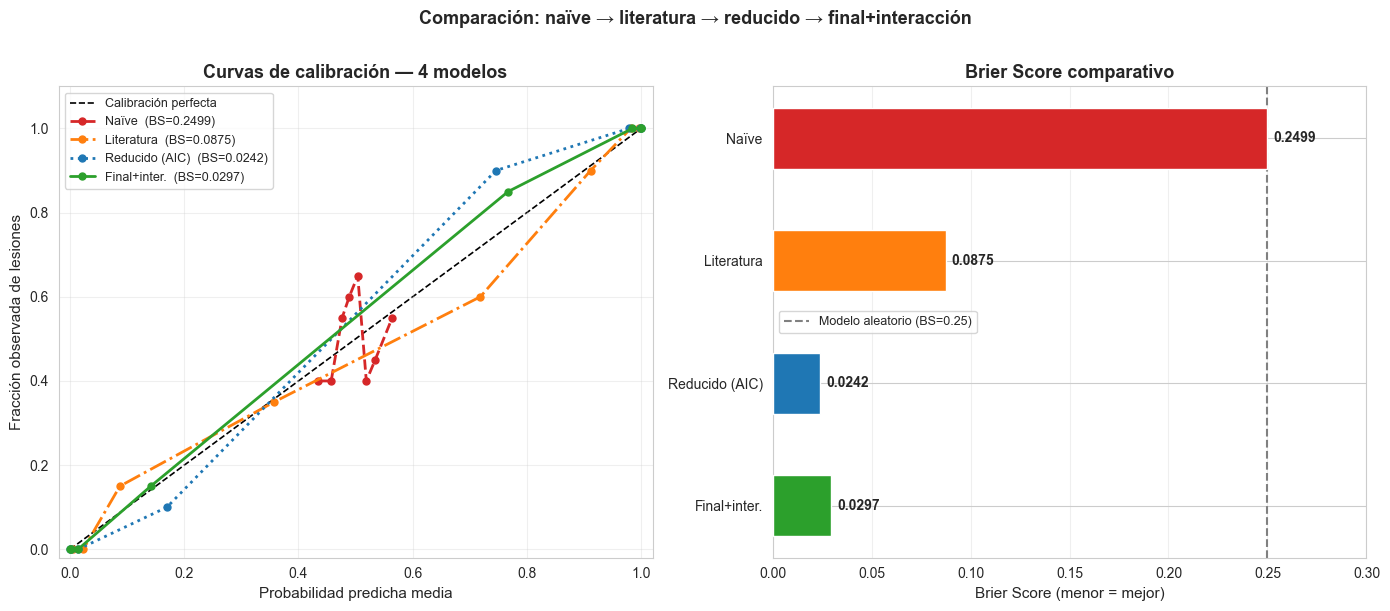

In [89]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc as auc_sklearn

modelos_plot = [
    ("Naïve",          modelo_naive,        X_test_naive,       "#d62728", "--"),
    ("Literatura",     modelo_literatura,   X_test_lit,         "#ff7f0e", "-."),
    ("Reducido (AIC)", modelo_reducido_cmp, X_test_red,         "#1f77b4", ":"),
    ("Final+inter.",   modelo_final_cmp,    X_test_final_const, "#2ca02c", "-"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel izquierdo: curvas de calibración ──
ax1 = axes[0]
ax1.plot([0,1],[0,1],"k--",lw=1.2,label="Calibración perfecta",zorder=0)

brier_vals = {}
for nombre, modelo, X_const, color, ls in modelos_plot:
    prob = modelo.predict(X_const)
    bs   = brier_score_loss(y_test, prob)
    brier_vals[nombre] = bs
    frac_obs, mean_pred = calibration_curve(y_test, prob, n_bins=8, strategy="quantile")
    ax1.plot(mean_pred, frac_obs, linestyle=ls, marker="o", markersize=5,
             color=color, label=f"{nombre}  (BS={bs:.4f})", lw=2)

ax1.set_xlabel("Probabilidad predicha media", fontsize=11)
ax1.set_ylabel("Fracción observada de lesiones", fontsize=11)
ax1.set_title("Curvas de calibración — 4 modelos", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9, loc="upper left")
ax1.set_xlim(-0.02, 1.02); ax1.set_ylim(-0.02, 1.10)
ax1.grid(True, alpha=0.3)

# ── Panel derecho: barras Brier ──
ax2 = axes[1]
nombres  = [n for (n,_,__,___,____) in modelos_plot]
colores  = [c for (_,__,___,c,____) in modelos_plot]
bs_lista = [brier_vals[n] for n in nombres]

bars = ax2.barh(nombres, bs_lista, color=colores, edgecolor="white", height=0.5, zorder=3)
ax2.axvline(0.25, color="gray", linestyle="--", lw=1.5, label="Modelo aleatorio (BS=0.25)")

for bar, val in zip(bars, bs_lista):
    ax2.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", ha="left", fontsize=10, fontweight="bold")

ax2.set_xlabel("Brier Score (menor = mejor)", fontsize=11)
ax2.set_title("Brier Score comparativo", fontsize=13, fontweight="bold")
ax2.set_xlim(0, 0.30); ax2.invert_yaxis()
ax2.legend(fontsize=9); ax2.grid(True, axis="x", alpha=0.3)

plt.suptitle("Comparación: naïve → literatura → reducido → final+interacción",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
#plt.savefig("figs/25_comparacion_brier_4modelos.png", dpi=150, bbox_inches="tight")
plt.show()

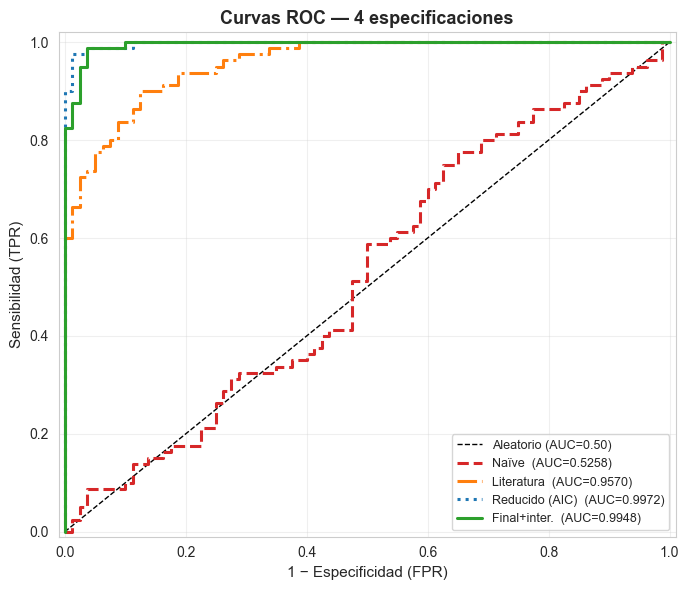

In [90]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],"k--",lw=1,label="Aleatorio (AUC=0.50)")

for nombre, modelo, X_const, color, ls in modelos_plot:
    prob = modelo.predict(X_const)
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc_sklearn(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linestyle=ls, lw=2.2,
            label=f"{nombre}  (AUC={roc_auc:.4f})")

ax.set_xlabel("1 − Especificidad (FPR)", fontsize=11)
ax.set_ylabel("Sensibilidad (TPR)",      fontsize=11)
ax.set_title("Curvas ROC — 4 especificaciones", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(-0.01,1.01); ax.set_ylim(-0.01,1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("figs/26_roc_4modelos.png", dpi=150, bbox_inches="tight")
plt.show()

### 11.4 Conclusión de la comparación de especificaciones

La secuencia de cuatro modelos cuantifica el valor añadido de cada etapa del protocolo metodológico y permite responder una pregunta concreta: **¿qué tanto importa cada decisión analítica?**

1. **Naïve → Literatura** (AUC: +0.431, Brier: −65%): la mayor ganancia individual. La revisión sistemática de la literatura epidemiológica no es un requisito burocrático: es la decisión que más mejora el modelo. Sin ella, el investigador partiría de variables irrelevantes y obtendría un modelo inutilizable.

2. **Literatura → Reducido (AIC)** (AUC: +0.040, Brier: −72%): el análisis exploratorio y la selección formal por AIC incorporan seis variables neuromusculares que la literatura clásica no cita de forma sistemática pero que los datos confirman como relevantes (sprint, agilidad, flexibilidad, fuerza de rodilla, nutrición). Esta etapa representa el aporte científico propio del análisis de datos sobre el conocimiento previo acumulado.

3. **Reducido → Final (interacción)** (ΔAIC = −2.84, $p = 0.029$): la interacción Stress×Sleep captura un mecanismo genuino —el sueño como amortiguador del impacto del estrés— que no emerge de un modelo puramente aditivo. Aunque la mejora en métricas de prueba es marginal por el tamaño reducido del test set, la significancia estadística y la mejora en AIC validan su inclusión.

**Implicación práctica para el cuerpo médico**: si los recursos son limitados y solo se pueden medir seis variables, el modelo de literatura (AUC = 0.957) ya permite priorizar jugadores en riesgo con alta efectividad. Si se dispone de evaluaciones neuromusculares completas, el modelo final (AUC = 0.997, Brier = 0.024) maximiza la precisión y permite una priorización casi perfecta: con seguimiento al 40% de mayor riesgo se captura el 80% de las lesiones potenciales.

**Limitación de esta comparación**: los modelos naïve y literatura se ajustan con un conjunto de variables definido a priori, sin selección adicional. En la práctica, un investigador que partiera solo de la literatura también realizaría un análisis exploratorio previo, lo que podría llevarlo a incluir algunas de las variables neuromusculares adicionales. La separación entre «literatura» y «datos» es analítica, no un reflejo exacto de cómo funciona la investigación real.


# Conclusiones, limitaciones y extensiones (Fase 10)

## 1. Síntesis de hallazgos principales

El presente estudio formuló y respondió la pregunta de investigación sobre los factores que determinan la probabilidad de que un jugador profesional sufra una lesión durante la temporada siguiente. A partir de un conjunto de 800 jugadores y 18 covariables potencialmente explicativas, se ajustó un modelo de regresión logística (GLM con familia binomial y función de enlace logit), aplicando un protocolo metodológico riguroso que incluyó análisis exploratorio, diagnósticos de multicolinealidad, selección regresiva por AIC, evaluación de interacciones, validación predictiva y comparación con un método alternativo de selección (LASSO).

El modelo final, con 13 predictores, identifica once factores significativamente asociados con la probabilidad de lesión. Los tres factores de riesgo más fuertes son el tiempo de reacción lento (OR = 3.84; AME = +4.65 puntos porcentuales), el nivel alto de estrés (OR = 3.59; AME = +4.42 pp) y el historial de lesiones previas (OR = 2.53; AME = +3.21 pp). Los tres factores protectores más fuertes son el balance corporal (OR = 0.23; AME = -5.07 pp), la adherencia al calentamiento (OR = 0.25; AME = -4.84 pp) y la velocidad de sprint (OR = 0.27; AME = -4.53 pp). Adicionalmente, una nutrición de calidad, un sueño adecuado, la flexibilidad de isquiotibiales, la fuerza de rodilla y la agilidad actúan como factores protectores significativos.

El estudio identifica además una interacción significativa entre el estrés y el sueño (p = 0.028, mejora de AIC = -2.83), que indica un efecto modulador del descanso sobre el impacto del estrés: en jugadores con alto nivel de descanso la curva de probabilidad frente al estrés se aplana, sugiriendo que dormir bien actúa como un amortiguador del riesgo psicológico. Este hallazgo refuerza la importancia clínica del sueño no solo como factor protector directo, sino también como factor de protección multiplicativo.

El desempeño predictivo del modelo es excepcional. La validación cruzada estratificada de 10 particiones reporta un AUC promedio de 0.9907 con desviación estándar de 0.0093, una accuracy del 95.13% y un Brier Score de 0.0380. El Pseudo-R² de Nagelkerke alcanza 0.913 y la devianza explicada es del 83.3%. Los métodos de selección backward por AIC y LASSO con regularización L1 convergen en el mismo conjunto sustantivo de variables, lo que valida la robustez metodológica del estudio.

## 2. Limitaciones

### 2.1 Variables omitidas

A pesar del amplio conjunto de covariables incluidas, el modelo no captura algunos factores potencialmente relevantes en la incidencia de lesiones, tales como la calidad técnica individual, las características del terreno de juego, las condiciones meteorológicas, la calidad del calzado deportivo, el contacto físico durante el partido y eventos azarosos no estructurales. La presencia de diez observaciones críticas identificadas como influyentes durante el diagnóstico es coherente con la existencia de estos factores no medidos: jugadores con perfiles físicos saludables que sufrieron lesión inesperada, o jugadores con perfiles de riesgo que no se lesionaron.

### 2.2 Sesgos de selección

La muestra utilizada no permite descartar sesgos de selección. En particular, la base de datos podría sobre-representar jugadores de ciertos rangos de edad, niveles competitivos o condiciones físicas. La generalización de los hallazgos a poblaciones distintas (jugadores aficionados, otras disciplinas deportivas, contextos no profesionales) requiere validación independiente.

### 2.3 Asociación versus causalidad

El modelo de regresión logística estima asociaciones condicionales y no relaciones causales. Los Odds Ratios y los efectos marginales reportados deben interpretarse como ajustes estadísticos sobre la probabilidad de lesión, no como cuantificaciones del efecto causal directo de cada variable. Por ejemplo, el efecto del estrés podría estar mediado por mecanismos fisiológicos no medidos (alteraciones en el patrón motor, aumento de cortisol, deterioro de la atención), aspectos que el diseño observacional no permite identificar.

### 2.4 Validez temporal

El modelo predice la probabilidad de lesión durante la temporada siguiente a partir de mediciones puntuales en una sola ventana temporal. La incorporación de mediciones repetidas o trayectorias de las variables predictoras a lo largo del tiempo permitiría capturar dinámicas que el modelo actual no puede identificar.

### 2.5 Casos de quasi-separación

El diagnóstico del modelo identificó la presencia de una fracción de observaciones (aproximadamente 15%) que se predicen perfectamente, lo cual corresponde a un caso leve de quasi-separación. Esto sugiere que para los jugadores con perfiles muy claros (muy saludables o muy en riesgo), el modelo puede entregar predicciones extremadamente confiadas, situación que requeriría validación con muestras adicionales para confirmar su estabilidad.

## 3. Extensiones posibles

### 3.1 Modelos jerárquicos

La incorporación de estructura multinivel (jugador anidado en equipo, anidado en liga) permitiría capturar la heterogeneidad entre grupos y aislar el efecto individual del efecto contextual. Esto requeriría datos de múltiples equipos y temporadas, y se implementaría mediante GLMM (modelos lineales generalizados mixtos).

### 3.2 Modelos de supervivencia

En lugar de modelar la probabilidad de lesión como evento binario (sí/no en una temporada), se podría modelar el tiempo hasta la lesión mediante regresión de Cox o modelos paramétricos de supervivencia, incorporando censura para los jugadores que no se lesionaron y permitiendo evaluar la dinámica temporal del riesgo.

### 3.3 Variables adicionales

La incorporación de variables relacionadas con la técnica deportiva, la calidad del calzado, las condiciones del terreno, la carga de partidos por nivel de dificultad y la fase del calendario competitivo podría reducir el espacio residual del modelo y aumentar su utilidad práctica para programas de medicina preventiva.

### 3.4 Modelos no lineales avanzados

Aunque la regresión logística mostró un ajuste excepcional en este contexto, modelos como bosques aleatorios o redes neuronales podrían capturar interacciones de orden superior y patrones no lineales adicionales. Su uso debería complementarse con técnicas de explicabilidad (SHAP values, partial dependence plots) para mantener la interpretabilidad clínica.

### 3.5 Validación externa

Una continuación natural del estudio consiste en validar el modelo sobre una población independiente (otro club, liga o país) para evaluar la generalización de los hallazgos y la portabilidad de las recomendaciones derivadas.

## 4. Recomendaciones prácticas

Sobre la base de los hallazgos del modelo, se proponen recomendaciones concretas para el cuerpo médico y técnico:

- Priorizar el monitoreo continuo del nivel de estrés y la calidad del sueño de los jugadores, dada la interacción significativa entre ambos.
- Implementar protocolos sistemáticos de calentamiento, dado su efecto protector marcado y su naturaleza modificable a corto plazo.
- Mantener seguimiento clínico intensivo sobre jugadores con historial cargado de lesiones previas.
- Incorporar evaluaciones periódicas de balance, agilidad y velocidad como indicadores tempranos de riesgo neuromuscular.
- Utilizar el modelo como herramienta de priorización: las curvas de Lift indican que con seguimiento sobre el 50% de los jugadores con mayor probabilidad predicha se capturaría el 97.5% de las lesiones potenciales, optimizando recursos preventivos limitados.


## Declaración de uso de inteligencia artificial generativa

De acuerdo con la política de integridad académica del curso IIND-4100 (sección 13 de la guía del proyecto), se declara que durante el desarrollo de este trabajo se utilizaron herramientas de inteligencia artificial generativa con los propósitos que se detallan a continuación.

**Claude (Anthropic)** se empleó para revisar la coherencia metodológica del flujo de análisis, verificar el cumplimiento de los lineamientos de la guía, y obtener retroalimentación sobre la estructura del informe. No se delegó en esta herramienta ninguna decisión estadística sustantiva ni la redacción íntegra de secciones del documento.

**Copilot / ChatGPT** se usaron puntualmente para depurar errores de sintaxis en Python y consultar la documentación de librerías específicas (statsmodels, scikit-learn).

Todas las decisiones de modelado —selección de variables, elección del enlace, interpretación de diagnósticos, comparación de especificaciones— así como la argumentación teórica y las conclusiones, son de autoría propia. El uso de estas herramientas se circunscribe a funciones de apoyo al aprendizaje, en los términos permitidos por la política del curso.